# IEEE SSCS Code-a-Chip Travel Grant — ISSCC 2027

---

# A Pulse-Programmable STT-MRAM Stochastic Primitive for Uncertainty-Aware Neural Inference

*Open-source 1T1MTJ stochastic primitive using a SKY130 CMOS access circuit with an abstract MTJ interface, DRC/LVS-verified layout, device-variation analysis, and Monte-Carlo dropout demonstration.*

| | |
|---|---|
| **Authors** | Tanay Das |
| **Affiliations** | AMD India |
| **License** | Apache 2.0 |
| **Tools** | Python 3.12, ngspice, Magic ≥ 8.3.411, Netgen, KLayout (Python), NumPy, SciPy, Matplotlib, scikit-learn |
| **PDK** | SkyWater SKY130 (open_pdks build `0fe599b2`, official `sky130_fd_pr` models) |

## One-sentence description
An open-source SKY130 CMOS stochastic primitive, with DRC/LVS-verified layout, that converts analytically modeled MTJ switching randomness into a pulse-programmable Bernoulli source — with parasitic-aware electrical characterization, device-variation analysis, and a neural-network demonstration.

## Research question
> *Can a stochastic MTJ be engineered into a calibrated hardware primitive whose probability, electrical interface, physical implementation, variation sensitivity, and system-level behavior are all characterized in one open, reproducible workflow?*

| Question | Evidence in this notebook | Section |
|---|---|---|
| Is MTJ switching stochastic? | Néel-Brown thermal-activation model | 1 |
| Can the probability be controlled? | Pulse-width P_SW(PW, I, T) surface | 2 |
| Can it be calibrated to a target p? | Calibration engine p* → PW*(T) | 4 |
| Can CMOS sense the resulting state? | Official SKY130 `nfet_01v8` + ngspice .op/.tran | 3 |
| Can it be physically laid out? | Magic SKY130 layout: 1T1MTJ cell + 4×4 array, abstract MTJ | 8 |
| Does the layout pass physical verification? | Flat DRC = 0 errors; Netgen LVS match (cell and array) | 8 |
| What parasitics result? | Capacitance-only PEX | 9 |
| Does layout materially change behavior? | Pre- vs post-layout I_BL, E_pulse (< 0.05 % change) | 9 |
| What happens under variation? | Assumed device-parameter variation, static-device experiment | 5, 11 |
| Is the output statistically well behaved? | Bias, autocorrelation, cross-cell sample correlation | 6 |
| Does it matter to an application? | MNIST MC dropout: accuracy, ECE, AUROC | 11 |
| Is it currently energy-efficient? | **No, under current assumptions** — E_pulse ≈ 4.7× an LFSR estimate | 7, 9 |
| What would have to improve? | Pulse ≈ 0.53 ns (≈ 66 fJ) **and** restore < ≈ 200 fJ/event | 7 |

## Key findings
1. **Calibration at the nominal device does not guarantee uniform statistical calibration across devices.** With (Δ, I_c0) fixed per virtual device under the assumed variation model, ECE ranges from 0.012 to 0.172 across 20 devices (ideal source: 0.062 ± 0.003) and tracks each device's own switching probability almost monotonically. The error is a systematic per-device offset, which points to per-device pulse-width trimming as future work.
2. **The CMOS access circuitry is physically realizable in SKY130**: DRC-clean, LVS-matched cell (3.24 µm²) and 4×4 array; extracted parasitics change the electrical behavior negligibly at this scale.
3. **Negative energy result, reported as-is:** under current assumptions the primitive is not an energy-efficient LFSR replacement; the notebook states the design-space requirements for parity instead.

## Claims we do NOT make
- ❌ An energy-efficient stochastic MRAM primitive — our results show the opposite under current assumptions.
- ❌ A fabricated MRAM cell — nothing here is silicon-measured.
- ❌ An embedded-MRAM SKY130 implementation — SKY130 has no MTJ process; the MTJ is an abstract interface in layout and a fixed behavioral resistor in SPICE.
- ❌ Magnetization switching simulated in SPICE — Python makes the switching decision; ngspice evaluates the resulting electrical state.

**What we do claim:** an open, DRC/LVS-verified SKY130 CMOS implementation of the access circuitry, coupled to an abstract MTJ interface and an analytical stochastic switching model, with calibration, variation, statistical, energy, and application-level characterization in one notebook. The novelty is the reproducible workflow and integration, not priority over the MTJ stochastic-switching mechanism or the dropout application.

## Key Citations
- **[1]** S.T. Ahmed et al., "SpinDrop," IEEE JETCAS 13(1), 2023. DOI:10.1109/JETCAS.2023.3242146
- **[2]** S.T. Ahmed et al., "Spatial-SpinDrop," arXiv:2306.10185, 2023
- **[3]** Y. Gal & Z. Ghahramani, "Dropout as Bayesian Approx.," ICML 2016
- **[4]** M. Luo et al., "Role of T, MTJ size, PW on STT-MRAM BER," Solid-State Electron. 185, 2021. DOI:10.1016/j.sse.2021.108068
- **[5]** J. Kim et al., "Technology-Agnostic MTJ SPICE Model," IEEE CICC 2015. DOI:10.1109/CICC.2015.7338407 — model: https://cse.umn.edu/smart/mtj-spice-model
- **[6]** N. Srivastava et al., "Dropout," JMLR 15, 2014
- **[7]** SkyWater SKY130 PDK, github.com/google/skywater-pdk; open_pdks / volare builds



## Abstract
Physical stochastic devices offer intrinsic randomness, but turning that randomness into a *programmable, calibrated* hardware probability source is difficult: the switching probability depends on pulse conditions and on device variation. This notebook presents an open, end-to-end workflow for a pulse-programmable 1T1MTJ stochastic primitive. An analytical Néel-Brown model maps pulse width to STT switching probability, and a calibration engine inverts it to program a target Bernoulli probability (p* = 0.30 at PW* ≈ 0.53 ns). The access circuit uses the official SKY130 `nfet_01v8` model in ngspice, with the MTJ represented as an abstract interface (a fixed behavioral resistor in SPICE, an abstract M2/M3 device in layout). The CMOS cell (3.24 µm²) and a 4×4 array are laid out in Magic, pass flat DRC with 0 errors, match in Netgen LVS, and are parasitic-extracted. Post-layout simulation changes bit-line current and pulse energy by < 0.05 %. The resulting Bernoulli source drives Monte-Carlo dropout on MNIST, with Fashion-MNIST as out-of-distribution data. The key finding is that **nominal calibration does not guarantee uniform calibration across devices**: under assumed parameter variation, expected calibration error spans 0.012–0.172 across 20 static virtual devices (ideal source: 0.062 ± 0.003) and tracks each device's own switching probability, motivating per-device pulse-width trimming. We also report a negative result: the electrical pulse energy (721 fJ; 755 fJ with extracted 4×4 capacitances) is 4.7–4.9× a parametric LFSR estimate, and we state the design-space requirements for energy parity instead of claiming efficiency.



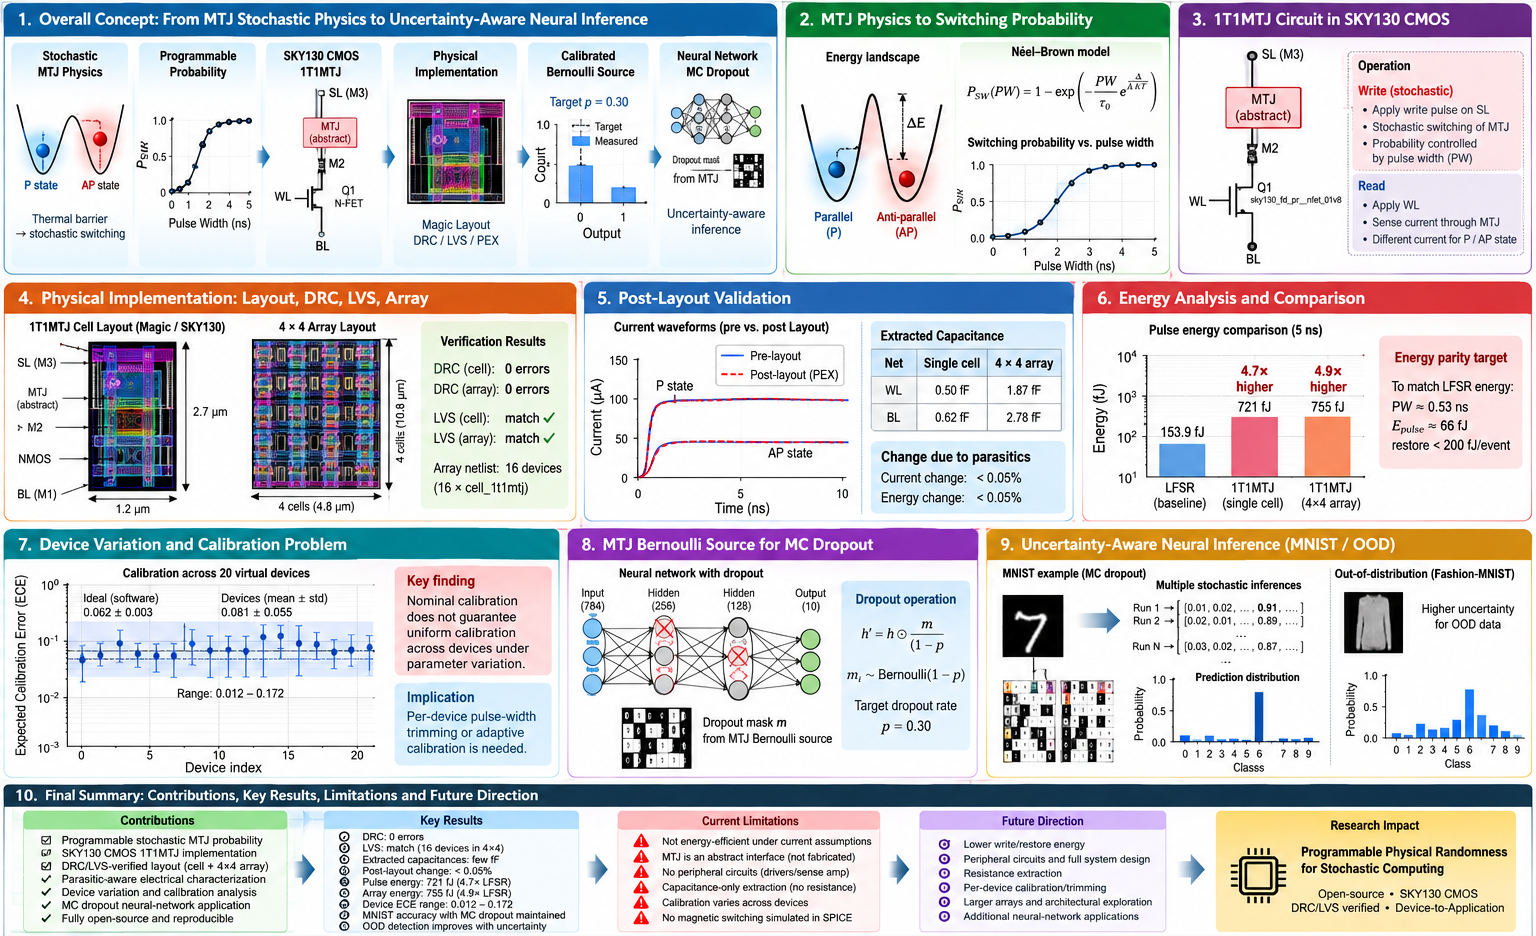

## Setup — Install, Imports & Device Constants

In [1]:
# ── Auto-install dependencies (Colab / fresh Linux runtime) ──────
# ngspice is installed via apt; Magic/Netgen for Section 8 are installed by Setup (2).
import sys, subprocess, shutil, importlib
IN_COLAB = 'google.colab' in sys.modules
def _sh(cmd): return subprocess.run(cmd, shell=True, capture_output=True, text=True)

if shutil.which("ngspice") is None:
    print("  installing ngspice (apt)...")
    _sh("apt-get -qq update && apt-get -qq install -y ngspice")
if shutil.which("ngspice") is None:
    raise RuntimeError("ngspice not found. Install it (Ubuntu: 'sudo apt-get install ngspice', "
                       "conda: 'conda install -c conda-forge ngspice') and re-run this cell.")
import re as _re
_v = _re.search(r"ngspice-(\d+)", _sh("ngspice -v").stdout)
print(f"  ngspice {_v.group(1) if _v else ''}: {shutil.which('ngspice')}")

for _pkg in ["numpy", "scipy", "matplotlib", "pandas", "scikit-learn", "zstandard", "klayout"]:
    _mod = {"scikit-learn": "sklearn"}.get(_pkg, _pkg)
    try:
        importlib.import_module(_mod)
    except ImportError:
        print(f"  installing {_pkg} (pip)...")
        _r = _sh(f"{sys.executable} -m pip install -q {_pkg}")
        importlib.invalidate_caches()
        try:
            importlib.import_module(_mod)
        except ImportError:
            msg = f"  WARNING: could not install {_pkg}: {(_r.stderr or '').strip()[-200:]}"
            if _pkg in ("zstandard", "klayout"): print(msg + " (optional: PDK download / layout images may be skipped)")
            else: raise RuntimeError(msg)

def run_ngspice(fname, cwd, expect=None):
    """Run ngspice in batch mode; raise with the log tail if it failed or produced no output."""
    r = subprocess.run(['ngspice', '-b', fname], cwd=cwd, capture_output=True, text=True)
    ok = r.returncode == 0 and (expect is None or os.path.exists(expect) and os.path.getsize(expect) > 0)
    if not ok:
        tail = "\n".join((r.stdout + r.stderr).strip().splitlines()[-25:])
        raise RuntimeError(f"ngspice failed on {os.path.basename(fname)} (rc={r.returncode}):\n{tail}")
    return r

import numpy as np, matplotlib, subprocess, re, os, sys, shutil, io, tarfile
import urllib.request, gzip, struct, warnings
import matplotlib.pyplot as plt
from scipy import stats
from scipy.integrate import trapezoid
from sklearn.metrics import roc_auc_score, roc_curve
import pandas as pd
warnings.filterwarnings('ignore')
np.random.seed(42)

FIG = os.path.abspath("figures")
RES = os.path.abspath("results")
SPC = os.path.abspath("spice")
LAY = os.path.abspath("layout")
for d in [FIG, RES, SPC, LAY]: os.makedirs(d, exist_ok=True)

plt.rcParams.update({'figure.dpi':150,'font.size':11,
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.25})

# ── Device constants ─────────────────────────────────────────────
VDD    = 1.8
R_P    = 6_000.0      # Ω parallel state
R_AP   = 12_750.0     # Ω anti-parallel state
DELTA0 = 40.0         # Thermal stability at T_NOM
IC0    = 100e-6       # Critical current at 0K (A)
TAU0   = 1e-9         # Attempt period (s)
T_NOM  = 300.0        # K (27°C)
AEC    = [233, 300, 398]
AEC_L  = ["-40°C", "27°C", "+125°C"]
TC     = ['#1565C0', '#2E7D32', '#B71C1C']
I_W    = IC0 * 0.9   # Nominal stochastic-pulse current (0.9·I_c0)

# Variation parameters for device-parameter MC
SG_D  = 0.04*DELTA0;  SL_D  = 0.03*DELTA0
SG_IC = 0.06*IC0;     SL_IC = 0.04*IC0
SG_T  = 3.0;          SL_T  = 1.5

# Fallback only (used if the official PDK cannot be downloaded):
NMOS_MODEL = """
.model sky130_nfet NMOS LEVEL=14
+ TOXE=4.23e-9 VTH0=0.49 U0=270 VSAT=8e4 K1=0.7 K2=-0.05
+ CGSO=2.75e-10 CGDO=2.75e-10
"""

print("="*65)
print(" Pulse-Programmable STT-MRAM Stochastic Primitive — ISSCC 2027 Code-a-Chip")
print("="*65)
print(f"  v5: official SKY130 models, DRC/LVS layout, PEX post-layout")
print(f"  R_P={R_P:.0f}Ω  R_AP={R_AP:.0f}Ω  Δ₀={DELTA0}  IC0={IC0*1e6:.0f}µA")

  installing ngspice (apt)...
  ngspice 42: /usr/bin/ngspice
  installing klayout (pip)...
 Pulse-Programmable STT-MRAM Stochastic Primitive — ISSCC 2027 Code-a-Chip
  v5: official SKY130 models, DRC/LVS layout, PEX post-layout
  R_P=6000Ω  R_AP=12750Ω  Δ₀=40.0  IC0=100µA


## Setup (2) — Official SKY130 PDK + Layout Tools
Downloads a pinned open_pdks build of SKY130 (~20 MB compressed: `common` + `sky130_fd_pr`). On Colab it also builds Magic (≥ 8.3.411 is required by the SKY130 tech file; takes a few minutes) and installs Netgen. If any step fails, Sections 1–7 and 10–13 still run: the NMOS falls back to a simplified card and Sections 8–9 are skipped, with a clear message.

In [2]:
IN_COLAB  = 'google.colab' in sys.modules
PDK_HASH  = "0fe599b2afb6708d281543108caf8310912f54af"
PDK_ROOT  = os.path.abspath(os.environ.get("PDK_ROOT", "pdk"))
PDK       = os.path.join(PDK_ROOT, "sky130A")
SKY130_LIB = f"{PDK}/libs.tech/combined/sky130.lib.spice"

def fetch_pdk():
    """Pinned SKY130 build from the volare release assets (no volare API needed)."""
    importlib.invalidate_caches(); import zstandard
    base = f"https://github.com/chipfoundry/volare/releases/download/sky130-{PDK_HASH}/"
    need = {"common": f"{PDK}/libs.tech/combined/sky130.lib.spice",
            "sky130_fd_pr": f"{PDK}/libs.ref/sky130_fd_pr/spice"}
    for part, marker in need.items():
        if os.path.exists(marker): continue
        print(f"  downloading {part}.tar.zst ...")
        data = urllib.request.urlopen(base + part + ".tar.zst", timeout=300).read()
        with zstandard.ZstdDecompressor().stream_reader(io.BytesIO(data)) as r:
            with tarfile.open(fileobj=r, mode="r|") as t:
                try:
                    t.extractall(PDK_ROOT, filter="fully_trusted")
                except TypeError:            # Python < 3.12
                    t.extractall(PDK_ROOT)

try:
    fetch_pdk()
except Exception as e:
    print(f"  PDK download failed ({e})")
USE_SKY130 = os.path.exists(SKY130_LIB) and os.path.isdir(f"{PDK}/libs.ref/sky130_fd_pr")

if USE_SKY130:
    shutil.copy(f"{PDK}/libs.tech/ngspice/spinit", f"{SPC}/.spiceinit")   # ngbehavior=hsa
    MODEL_HDR = f".lib {SKY130_LIB} tt\n"
    NMOS_FMT  = "XM1 {d} {g} {s} {b} sky130_fd_pr__nfet_01v8 W=1 L=0.15 nf=1\n"
    NMOS_SRC  = "official sky130_fd_pr__nfet_01v8 (tt), W/L = 1/0.15 µm"
else:
    MODEL_HDR = NMOS_MODEL
    NMOS_FMT  = "M_nmos {d} {g} {s} {b} sky130_nfet W=1e-6 L=0.15e-6\n"
    NMOS_SRC  = "FALLBACK simplified SKY130-inspired card (PDK unavailable)"

# ── Layout tools (Magic ≥ 8.3.411, Netgen) ──
def magic_version():
    try:
        v = subprocess.run(["magic", "--version"], capture_output=True, text=True).stdout.strip()
        return tuple(int(x) for x in v.split("."))
    except Exception:
        return None

def install_eda_colab():
    cmds = ["apt-get -qq update",
            "apt-get -qq install -y tcl-dev tk-dev libcairo2-dev m4 tcsh libglu1-mesa-dev netgen-lvs zstd",
            "rm -rf /tmp/magic && git clone -q --depth 1 https://github.com/RTimothyEdwards/magic.git /tmp/magic",
            "cd /tmp/magic && ./configure --prefix=/usr/local > /dev/null && (make -j4 > /dev/null 2>&1 || true) && make install > /dev/null 2>&1"]
    for c in cmds: subprocess.run(c, shell=True)

if IN_COLAB and (magic_version() or (0,)) < (8,3,411):
    print("  building Magic from source (Colab)...")
    install_eda_colab()

MAGIC_V = magic_version()
NETGEN  = shutil.which("netgen-lvs") or shutil.which("netgen")
LAYOUT_OK = USE_SKY130 and MAGIC_V is not None and MAGIC_V >= (8,3,411) and NETGEN is not None

print(f"  SKY130 PDK : {'OK  ' + PDK if USE_SKY130 else 'NOT AVAILABLE'}")
print(f"  NMOS model : {NMOS_SRC}")
print(f"  Magic      : {'.'.join(map(str, MAGIC_V)) if MAGIC_V else 'not found'}")
print(f"  Netgen     : {NETGEN or 'not found'}")
print(f"  Layout flow (Sections 8–9): {'ENABLED (generated this run)' if LAYOUT_OK else 'tools unavailable → embedded reference results (Setup 3)'}")


  downloading common.tar.zst ...
  downloading sky130_fd_pr.tar.zst ...
  building Magic from source (Colab)...
  SKY130 PDK : OK  /content/pdk/sky130A
  NMOS model : official sky130_fd_pr__nfet_01v8 (tt), W/L = 1/0.15 µm
  Magic      : 8.3.684
  Netgen     : /usr/bin/netgen-lvs
  Layout flow (Sections 8–9): ENABLED (generated this run)


## Setup (3) — Embedded Layout Reference Data (fallback only)
A compressed copy of the layout outputs produced by this notebook's own Section 8–9 flow (Magic 8.3.684 + Netgen, SKY130 `0fe599b2`): GDS, Magic views, schematic/LVS/PEX netlists and LVS reports. It is used **only** if Magic/Netgen are unavailable in the runtime, so the notebook stays a single self-contained file. When the tools are available, Section 8 regenerates everything from scratch and ignores this data.

In [3]:
#@title Embedded layout reference data — fallback only (double-click to view) { display-mode: "form" }
import base64 as _b64, zipfile as _zf
EMB_LAYOUT_RES = {
    'cell_1t1mtj': dict(w_um=1.2, h_um=2.7, drc=0, lvs_ok=True, lvs_msg='Circuits match uniquely.'),
    'array_4x4':   dict(w_um=4.8, h_um=10.8, drc=0, lvs_ok=True, lvs_msg='Circuits match uniquely.'),
}
EMB_LAYOUT_ZIP_B64 = (
    "UEsDBBQAAAAIAMmzOF3UFDmsgwQAAC4QAAAPAAAAY2VsbF8xdDFtdGouZ2RzpZZNiBxFFMdfdff2TscxjJuw7mqQEC9CBt2JQVdB"
    "3c942E0Us5uIq3a+Qd34kYxCPOQg4tfF+IHiByELMRISkCxI4s0EkRwEQ0APoh5yEEkuHoTk4Ez7Xr16XV07W+2qA72/5V/9n3/X"
    "61dVAzEEEMIqFcBBSKAPeuEWWOH8XwvinbtnZ9NGs7G3+TTAyrDr/uE375749vM/7hk7c8eRTx6bglVdfv+aON7/zIHGnQPpnl3p"
    "8/vS9Nk9u5vpQOOlwXTdxJaHN94FUQUgvj6AYYiXB7AS6rUwy9rv4VUFUHuFeP1JulDr0Q2Q+5/Q/rrx92ZZ622897IQIHiBdKHW"
    "i/6RYn42g/ftAIDPLMOTrAtR9/u/xO8/jL4JId1PulDrJflZ9tcU5Vq2DrMuRL3Tb+afncCcefRNW4aPsy5E3etvf48evC07YKmO"
    "sy6EzOfHsdf1OKiGpTrOutDvp++nZ6RcIc3B5E7LeFk+z1E1hFwDnTudj5fmt7dyvjBTJlfJeHk+jut8YaZMrsrHS94fvt+jPFdh"
    "axPrQtSL/tTpnwfx/W5C31eW4desC1Ev8eP3D5HPsjXPuhD1on+0Y/3Mm/VjqPtuxnJB/zl+qm/rGtedifdX+P0zSff5ub44ruvO"
    "JB+/f2aZ36yvo2b9Geq6z1guqP/o/1x/ox3rLzV9b6gSs/4SGff5TZ+npu8NVWLWX5KPl+TjddX0v2E2Z/p/TsbL8vU4979hNmf6"
    "fy4fL6nfv+7/Mef9PYf1fR9971iGL7MuRN3rb5+i8wXv+1Bozp1Two7zZ8zpv6fMufWQkHykC8v89Hw4v9fouS1bs6wLUdf+big9"
    "gWtxjCd3un3H/ua+7Tubed6487zmoyJLdcj8fygfLj7vhkX9dUufv5rn9wbQBfGNiv7eRLti9eauB77TnwtQ1d/7Cl4fQNwfj4w7"
    "6fz0NZO+Dq9deF0s8LzRz+fjxfQNS01Xyyl9anyRuRfTfzaphmqIdSHqS3xXzq+taBnAmp5/+gVlnp6ehX4nhSchXhvAfVCpx49u"
    "bJiq4zfVetxOKPqwJ4NrxtdTd+5LB5y5X9Fzj0yfDuL1KWb+LgRYdhvpQq0X/cPOPnEEoPIIZt9rmWxjXYh60f+k03e3AnT/gL7T"
    "lskvrAtR957Tqg+//1XkOcvkdtaFqPvPGeyuynrM7bFMDrIuRN27T/6HfHefGORcqrsweYN14YJ8d5/Cfo2xR1XbsnuWdWE8VJL/"
    "Dc75J94vhNEx1oWoe/PVj+wLey2jY6wL/X6eH60vmrdQ9bEuRL3TL/3Xj54XkV9YRtexLkTd6w/Wsi84a0k+0oUL/OPO81/idQO/"
    "Cc26uSTsWD/Ovk3rNlyt127OaBvrQtS9+zadZXrdrhZSLvuYNr+az3+xnXOo/yP6fEz7CXpw88LffLhzbp1cpHq14tszMzf0vb3y"
    "U6OYzmcArn46NSZ9pwbXOHmXay50a6/1JZwabnrwlqRvnvSfGlRhSqWKC93Kd6QvufKVX6HSH2/ZPD1SXvvKeq650Ldz4KkVRfA3"
    "UEsDBBQAAAAIAMmzOF0Ot45G1gYAALQfAAANAAAAYXJyYXlfNHg0Lmdkc8WYXWwUVRTHz+xupzvt0iylVCoUGoyBSqPdFhUxaim0"
    "RihobAtG1KF8BbH4UaoRH4ghxq8XEQxGNKRNKoZIYiAxaKIEDFEeTCQkEmL8SDAxBl+MMciD7XjOnHv2zux2bmfgwSbDb/O/859z"
    "z51777kD2JCCNMyxUrAbHJgF9TAXZoR+16TsgaGhgV3u4hcXA9SlK+5d9sadq77+6M+7Vnx228j7j/bBnIpo93zb3vnUrkJ7q7t1"
    "s/vskOs+vXXLsNtaeGGJ27Zq7UOr74BMFsCeloJlYNekoA5a8mnPm9iPVw7A2iHE62/Shb6emQ5F/+O+v0X56z1v/C2897IQIPUc"
    "6UJfD/o7g/G99XjfRgD4UDN9lHUh6tH+T/H5h9C3Skj3ky70dUN8z/u3j+Jqjh9iXYh6uV/l732McY6jr18z/RjrQtQj/RPfoQdv"
    "83ZpWkdYF4IX5ce21/x2sAqa1hHWhdF+ej71keIKKQcVt1/aTfE5R6sg5DHw4/YX243xJ9ZxfKFnqbiWtJvjY7sfX+hZKq5VbDe8"
    "P3y/Y5yrcHwN60LUg343NH/ux/e7Bn2fa6ZPsS5E3eDH53eQT3P8OOtC1IP+5WXr57haP4r+vFuvWTL/Qn4a3/GrPO5MvD/L759J"
    "epSfxxfb/XFnko/fP9PkV+trTK0/RX/c12uWjP/y61x/y8vWn6vmvaLlqPXnSHuUX81zV817RctR688pthvi4/WPmv+K3qia/6PS"
    "borvt/P8V/RG1fwfLbYbxi/x/F8Ren/P4Pi+g763NdMvsS5EPdI/cYzqC973rlDVnWPCsvqzIjT/nlR160Eh+UgXmvzUP8zvVeq3"
    "5vgg60LUfX8lGCtw3rZ3DG93BzbuHB4a2DRcjNcV6q/6szKa1l71e2+xOdjf7kn9LZpR/lwxfn0KKsC+waJ/b6RdMTe74r5v/b9z"
    "kPOfuwevA2A32J1doejc+7yK3obXZrzOB3hW6WeL7cHo3XGjWzUUva9rktyD0X9UURWtDtaFqMd8V5u2DA66heECvjO8vwpgfu1U"
    "JyjVe+oLnZPSR8FelIJ7INtiP7K6oEYdn5SvDc+EoA/nZOqq8tW2hO5zW0O5/+HnnlHzdAleH2DM34UAVQtJF/p60L8stE+MAGQf"
    "xthLNZ0NrAtRD/qfCM27mwAqv0ffCU3nJ9aFqEfWaWsWPv8V5Feazq2sC1GPrjM4u7J4LE7Vajq7WReiHrlPXkP88D6xhOPSuAud"
    "11kXlsQP71M4X22co9aEZuUg60K7wxD/DOb8A+8Xwsxh1oWoR8a3LrAvXa+ZOcy6MNrP+dH6oryF1izWhaiX+2X+NaDneeQnmplq"
    "1oWoR/pTi9iXOq1JPtKFJf6uUP8v8bqB34Rq3VwSlq2f0L5N6zbd5K/dIjMbWBeiHrlvUy3z122TkOKyj6nj54r5T7ZzdjS8R38H"
    "aT9BD25eeObDnXNdzySjlw++PZW5YtTbM1eNYHSuAbj6qWr0RFUNHmNnH4+5MDz2vh6jaoSjp96U6L090VWDRpii0ogLwyNfFj32"
    "yGd/hmyDvba3v9M89tnFPObCqJ1jiqpVYwf/h4CmPVaaUB3jvmZnUN3IwJzgiaH2lP59S6uuQAE/FqCoL30cN/y6avoFG9s1bz7N"
    "uhD1SH+2kn3ZXzXJR7rQ5M+dYN+0/ZrkI11o8lP/6nu538LZt7MuRN3Yf/JRv4XkI11o8lP/yEf9FpKPdKHJT/2r/ob7LcwfYV2I"
    "urH/5KN+C8lHutDkp/6Rj/otJB/pQpOf+mfdzf0W2o2sC1E39p981G8h+UgXmvzUP/JRv4XkI11Y4i+rgAsu8voVNrewLlxw0eyf"
    "d4F9wqYvWBfOu2D2N/awTzh3hHVh42Q1IOCfuZJ9wvpW1oUzV5r9tafYJ6yrY12Ie4zRX3WSfcLqMdaFVSenOoHF20ejTzDxauDk"
    "JwiAhee5egmbt7EuRD3yBJHZx76KA5rN21gXmvxOJ/uqujXJR7rQ5J/2F/tqrmiSj3Rhib+79AREPqqfQvKRLjT57TH2VZ7TJB/p"
    "QpO/uo99uZc1yUe60OTPZ9g3vVWTfKQLxX8NJ7AsncBK6uf1nsFix1+4J945JO7+lTR+45V48ePuX0njz9geL37c/ev/PgcmjV9d"
    "4PlXmGL+xd1/k8af+SXHb5siftz6kzR+0wMcv32K+HHrb9JvoOZGit9Zuv7LvoLi1o+kX0Ecv7c0ftl3UNz9O0n+FXU6/0Jk/snq"
    "X5L8K5fq/AuG/JPUnyT5O2d0/m2G/JPU7yT5V1/W+bcZ8k9SP5PkXzOs82835J/k/JEk//xBnX+7If8k9R8/JTIZ+A9QSwMEFAAA"
    "AAgAybM4XQKKUAcmAgAAXAUAAA8AAABjZWxsXzF0MW10ai5tYWeNVNtq3DAUfPdXnB8w6GbZhhDIkgRKG1pYmu6b8XrljZv1BdtJ"
    "27/vOZJ8CetCWfBao5k5RyPJdX6uimA0xQsMr3+4ZHdBnZ+HIr8Y4CCCsarNMOZ1BzxOmUhSxtPg5gaKF1O8dnnVjHB7G/SmGCHk"
    "QmukqQS4EgzfEjbNSMZoPkJUaWZJaxE+E+ZUlkUVuuHteKrKcvaXAlSMLK5ATc6ESQ2RpikHpcxClhavaMJjUq/di3a1ArJBKTnE"
    "todLi0FU87xirgOGvEQv2D86YCuMaMJLXQfv1dr6qnRtxvzCl3B9bYFBqiRZgdvFLW/CQl/dgnJqXGEs1JEAuWyUACEURPgnlx0C"
    "jnsWapryWm2hSCyQpSEeWbbvRVk3HiWLHWIk5djKrOVO5IgTSESqg9hsSAvhbh3RFOIqI9eVWjVKZZyza3UKVqxF1KPtnM1QKJhf"
    "5CyRs4RMieAiYMHbYKAef2b5cRj7HAkfRhnbvkQ42Qxl29d4z1we+KRGg2P7G2iE9olzd1czK09Z12dZUxp05e9JJj4/f3vSAIcn"
    "/j9FYulq4PmhGiGOQxwQThgd+PxoLgOttLSv0zH0wdOq8bAxeOyN2aO1zcD9fnwJurbHdKAZzK8PekGRqpT5lLf1O68X13pp4yED"
    "H/m2w947yGsHPt8Bu7O45k2H5/33nfNQzoO+FH3bmX6sjI0F97RqzvD46fBwn+12Xw/WOPSXi04DSkxzIu5fUEsDBBQAAAAIAMmz"
    "OF120Mx1xQEAAKkGAAANAAAAYXJyYXlfNHg0Lm1hZ51UwU7EIBC99yv4ARNmgEITY6IHT9426tHUirra7m5ajPr3wkLtaOGgaQLt"
    "6+PxBmZmaJ+2XeVs98ym108Q/Lxy28FOrh0ODHTD0TQcmur0lHXPtns9tNudY2dn1Wg7x05qxZknMOBh0JzPeC38INMPzwgCg3Vt"
    "D8tiDL/9cALhRckFNqCOqBFmAbWKVG0IU8nIVDVhShOZCggTdWRiQ5gIkYmSakbIfHvGxbPwTv2WGOY6RQugIwqSwigSjDWFhUqw"
    "MAmetxHf2ygeKYbTbXRCkVMYmwQLpLCEBEuZ4LfJss72/R04GNwLox93vGrHsf1knHlTXijMqHk+GdzY7qbH/TgwYPz4+Lm6338c"
    "jy9epz/AGFrf3tt+CqE9Hl/nNKAn7RUuR2s3XjbEHJ/bK14d9qMPnO0m+55ZTm4vq3Czub6IEliUWLKiYAKigigpkGT7rwmSxAUT"
    "GBVkSYHUxn9NkJormBBRQZUUfhTz323g7+rKSlzMWVGvFcTvwskqbGYFnfOwKuaCi5QWJudiVakFH0mjyflYdY+Cj5QZ/tQzRla9"
    "oWBkFslUGq4bVsFJSg/IXK1Yt6OCk1kklZvvH3b3EJrHF1BLAwQUAAAACADJszhdxP1us70AAABeAQAAEAAAAG10al9hYnN0cmFj"
    "dC5tYWd9jm0KwjAMhv/3FLmA0Ka6ORiCgl5AL1BrdMW1G2tBvL2p8xNEXhpanvRJvDk5KxLZBuL5qrRciuQ8xWR8D6qsJM4rqSpR"
    "12AbsufeuJBgsRAD2QSTQsuxFAWfUuY+T8m0+OqRHCxg+mb6i/HnkdnOe/qQaw5yKTNszZ7amNnxfn1OmYFivQLMqs1AtDUhshDG"
    "rNai74YECkKkC0R3CqaFvTu4PMJ1/PoSahYiZqHGn8LdQ4h/hLwuhUPe9QZQSwMEFAAAAAgAybM4XYJ9Kz+TAgAAXQcAACIAAABz"
    "a3kxMzBfZmRfcHJfX25mZXRfMDF2OF8yS1ZQTTYubWFnlVXbjpswEH3PV8wPUGFDgEirlfolljGGRWsuMl5WUdV/7/gGjpSo7UPs"
    "ycyZMxd7zMSHUVyMFB+wfd5Jkf+8THzYBFcSCNCLGSe5GT6tQOpbTptbTm6XtzcQH1J8rnycDby/X7QUBjJCbwWQoirBS2XZREtB"
    "ibXkEKXysBSFXZ2pcO556pR5vijmaajMRoAgWkrMa56WLcnoir8cqa+Am7N3Y9+fgLqApnE4az90mVVWBG1BR2uvQ+ChszhL7qJE"
    "rQMAmg4+bwVkiBgkzjwo8XJUPvSRpzgTDT5ZQhNy8mmiy7qo++lge1lTsNuRseuvraK2thC6djoPT3DU+xbN2crYSUrT9iIwpH96"
    "Z4EyO7HuHyZkg2cHrfvj0zyVHtsEBswqFCeWh9vmE09rySJdjIGOasG7PD725V964Nrq+k3yMjkE/Bevw3EM/hQOnLVamD+z/6of"
    "E97Hh3yflfm3y/CyGZM0XJGTnN7cJXFbk+heNMjDU5z3PQ6uqn3TSDJOVf16nGiiq+owTjRpmwNAVZ983vpknKqkGcRTVckx2Xyz"
    "UIR9WlLty2MJPg/YwBCupV5Wqc0o3aOzGT3OAwxyFlKp8KCyvmOrZmzupWE52ZsIU2Orub4HWNSuXHM8Jqk3+MYXWEH+A8drQnHu"
    "cXHPwrK7WfQz4eXhi+sOcFcCUYN2q3Fra1fTRqRWUTLLak3t4nDrskut+IokXRQx/jTOPoVvL5UUhOLbBvjQYkUglmnlZmzxe/Hr"
    "RcGvGsHUbiAxthvrkfqDsW2VAseAbcvsojD8BGl4xjNc97wj+X59GgSNbH4MchqLvbDG39B/KcXcaGDBOH6b7R72B8VOz1EcuJGH"
    "3ILfddhV2A24r4ycO3sf/gBQSwMEFAAAAAgAybM4XeCKgVd/AAAAnQAAABUAAABjZWxsXzF0MW10al9zY2guc3BpY2XTKy5NSs4u"
    "UcgtyYpPTCouKUpMLlFwclUIceXSS81LKebSgypITs3JiTcsMQQqVAj3UXDyUQj2UQgLDnXiivA1BHGBgpl5JWAhheLsSkNjg/i0"
    "lPiCovj4vLTUkngDwzILhXBbQwUfWwM9Q1OFvDRbQ6DWEC+wLqBZyC6A2g0AUEsDBBQAAAAIAMmzOF1d1V9EAQEAAAoDAAATAAAA"
    "YXJyYXlfNHg0X3NjaC5zcGljZX3SwWqDQBAG4LtPMU8gOzMJ9OJlIZdiT6ZNboMxCm1SKbopzdt3HLcQiu5hWFz/mfkE8/F2ai4B"
    "PsOH1KcxDHUTwO9gv8vytj+PWR4DTXu9CgbUIBxK8CVUJbxVrz47vuD0qJfvfbArGC93ZCfdWb4Gkb5rgzj8foJDgVAWLsct9F2B"
    "2rp/ti6d9Sj4t7sehvoum5+NLnFaqEVaPG/zellpeX1RlROG9CQ9WU/Ojk6cdf4Frevhg6YExsQ8YilBMTEPX0pwTNjahQTKrF93"
    "oDkw4UBzYMKB5sCEg8xBCQcJxsSag8xBCQeZgxIONgcnHGwOTjhYKCbWHGwOXnfMP9svUEsDBBQAAAAIAMmzOF1dDb5BDAEAAAMC"
    "AAAVAAAAY2VsbF8xdDFtdGpfbHZzLnNwaWNlhZBdT4MwGIXv+yvexLslwxaCThMuxBBjZGYJOrlrSimKdGUp3Qf/XjphQqLx7pyT"
    "06ftmcHzQ7J6vI+gKKUArgUzIodC1xvgQkpKDNmYT0ccDczBCP6halm/t7fQVC3x8B1CTrPLeGX6gBY53WpKVSEMxWS/oO7TerW8"
    "AkbVtUcVwfjCas/qxcJq4vfxOnkNE5TicTat/iBO3b/uBJYH2HFvYJsHruN3vul98+0PAQHZRcRHjlB5g9AMQsl4Nc/qIwhldAv2"
    "W6Xmu9JAUWvoVqAsa4xm3MBZ7EtxOC8wqYQRvEQDfWiMJoW3GMIYkvj0FZSmS2J9l44xFF92INv4Z1+UTo/9Qkmm6OFtX1BLAwQU"
    "AAAACADJszhdgJ7XzZwBAABfBQAAEwAAAGFycmF5XzR4NF9sdnMuc3BpY2WNk11rwjAUhu/zKw7sTrDLh25u4MUcMsZ0CN20MEao"
    "bbo5aytp/AJ//NLGOJWJuQgn53CeN+dN2hq8PvmD58cuJJNUQCRFqEQMicxnEEoZbnhj3fDEWkEdlIi+szzNvzb3UEw3hOEHhLxi"
    "MY6malfgScznkvMsEYpjsmxx+jIc9G8g5Nkt4xnB+Krcs3LfapV70tyVh/57x0cBPqwdt/5JVL3nzoQwbmOP3sE8blOvqfNilxcm"
    "X7UJpLpEmsgTWVwgVINOGkbT+jhfg8iU3EBpayKjxURBkkuYqR8ejgslw0jBfrOciNX+Bo5aOl1461p12xGJNOVEEd0Jox50euD3"
    "KisoCPqkzHX1UIbjay1Udly4XxQcY/+o+MfSp7PtH1vPgM2Rox7Ri+rF9GxYK2AdiY7lrFRHqiPTkaHgwBvHH3iLPyshy1WCBz2n"
    "ADEAcQaoAagzwAzAnAG8JdaD8XzZA7Ee3ABqAOoMMAMwZwBvqfVg3uuyB2o9uAHUANQZYAZgzgDeMuuh+tYcPDDrwQ2gBqDOADMA"
    "Ow/s/q5fUEsDBBQAAAAIAMmzOF1SPSLw8AAAAJ4BAAAVAAAAY2VsbF8xdDFtdGpfcGV4LnNwaWNlbZBNT4QwEIbv/RVzNhE7/UBq"
    "wkHIxpgQY0J0vTUIrV/ssoFG3X/vFIgnju+bp8/M9AIe7urH+3IH/qN30I6uCa4DPw4HaF3fWwx4CJ+J+w1wCcG178ehH97ONzB9"
    "nVHyW8ZeOBBhm9cpjE0bLL8qdrCvoKjguX4qVtD6zp5Ga4/eEYLfGTRdzhNh4NTlItGUpzVPS/7JEXqqULOSR1tdAU+4NibzrMSN"
    "oQsg0zQlQGwARQQQ9WyQccnlCSrU1KgI7OfGkIYavX0aAUqhIiCNcT6TJ1JrFcXX0bp2QguJ1GUbohVBqVRUmf8fiyrFpWd/UEsD"
    "BBQAAAAIAMmzOF2A9hYPFgkAAOg1AAATAAAAYXJyYXlfNHg0X3BleC5zcGljZa1bbWtltxH+7l9xPxdyo9G7CvshXkIIhFIw7QZK"
    "Me6u3Zc42eA1bRby4yvNzDnnWpo51tr3w8JeoaOR5vWZR/IfDn/67urP37/99nD37/vbw/uH25vH2w+Hu4ePPx9uHh5uPl/73/zx"
    "9rfHw1eHx9v3//rl4/3Hf37+4+HTT5/BmW8uLn40h/e39/fX8Ag/P/7n2vzN/G7+/nX7780/Pj0+3Lx/vDZfX357ePeDOVzWf3+9"
    "+sslf3199+H614fr61/ubusk+G8+3Hx4Y462HH798MYeQ/39iX9/ot//ewOH+zoE4eJH6OSCJhdeJBeOEJtcMEdnnwi2nWCrCbYv"
    "O3CTap5IdJ1Ep0l055LoB6OCblQ4o3LDYFVFMLxIsHDUOJhTkWjPJTEN5lQkunNJzIM5rW5Oe0ZzlsGcimB4kWDhqNDnI6uJtGcT"
    "2acip4l0ZxPZJyHzu9Mt6s5oUeiTEWiS4UWSpcP22chqIu3ZRPZ5yGki3ZlEvqXyOFVL6wcQSr67eDt6nrjNKV8xR2MAbF11dC4x"
    "QV3V/ZqLt6NDiLOnsmzbgzeh7qG3uVLzpjAAniy1VcfyolbSerKItp2q9lUEhFyqiD67qyJQeX1mnjKgEnLbMUu1zegamsa9aUav"
    "ibN91OK2jtlUfBvsV1GO39Ja+yoWXIri8B0OApiU2iAlv3XQNGUNoa2mTtu0VcNytIhSzOp2Eu0mCtpQUkiTkYTpWsjU6RmPNbml"
    "NW77wqice/akS+AaDMqr5r5HME2SBUFlShleVWb7AykfXLIx6VDWCZrTfLVOnwaZaHs7xu6EyhS9bqFipSBXks0W5Daxhzv2cBzM"
    "qP3ZfOEBWojVwjA6kL4BDjFneAMGLZ1KCzEHHGK8K4A2SLh1NlGSA7hRIyqkaUfx0BTgPMvnTVkcDKgVinvjan5vgz3qVtenEpME"
    "zWrRUKePWVXtItr0PhhVR8Sq4MeNqM0R6qYp1INwAi0M63Qr5iw1g5MreYehz6qG6NqYFwTr7kW1wC82c2yzFt5+7JRU5NeOMFkI"
    "JxHPigsybw2Va4vDQ44W3NtaoOC5pFJXfIkNGlDw0CDkhGYLX9Dsk61byAUChVc4aGsexkGP4mcreQ2pZtIQcFe8lCulHTdMWmIe"
    "9hE4SmKp0JyOM1EYg0306itWETpYGBtDUQzjCkpK0bB7O3bvposIqPzZ1BCJlHm3mL6tsESNoQQfmrPHyeLE7sIVMEr4RGlAt2O9"
    "yJo7GJACJfbxp9j/S5ftza0c7yk0iNNEANb6NFlFZ7Ma7z1NollO9GkM/tchDt7FZEvBtS95EfM+14VQBif3XFJQGquuns3q9CRC"
    "22eQScr4/RKlDuM9Tdp/Gu+SKvNkKZ5NacuywEfAjGDoCHn0hj1QkUcrT2xNb9KWrXnU7Gy6y4EbAgzGGost4eWIR5vVNYO7PNbz"
    "PVYgZxFXK9llyRN5Ok9ghJZJRMWhVCQQpqXnOn0Sla8gGIt/mWbraU8eqw9ZyJnkmhpKwEUXB4QG7ksUMbAWjS4jaCu91dQGHraK"
    "VDL+5la94vhWaEthUAOEOBEy1DYeRy6fQJ3aeeCBGBVZl4lgkECtli7bfCdCV7UTN33NVi8PiEwwAXc5GwesUTB9Ft25edrcoqpx"
    "npjeoq5qdM6dnhgQTGELOrYgGkvgxl8HydkJBpZICcMVAuLJBA5bSShwqn5wfDRqMr13ODpyxK8kVPhoAcNzMo0tVBpEEZTKemzz"
    "E8eL43iJuErmUWp1HLbzMFBHqpdjigRLEYppeU0wYEeT6U1sm/8iLKTzTFzOwE6i5fU0I2Go3gXg/J41Utfnc05CpPkQAWJEk0Dv"
    "qyzMShPaLJZ71ZFsYVqIuhITcRUmi2ahxsLiOmDPcSfgAZxlkodE4JATAYXKMXBGZLpodluc2tx4NaPeKTaVOJnFfwaIgJOaYbWF"
    "3j7r07Xa2MKTz0Y+WL1v2sgB8AtnT3U2G8wbfvJWaPF5P5mIF436US2vg7YcI17qdNSGdNUdklUjYa/CCh+ZQaKLjlLQGb1EMWp7"
    "bvMzc0iYnKMLpPqCI0xbMLMEwQgUrB4f7OgBRDpdPZfAVe1WYeIMITj2Iao9BOCCxBru3JmEIIJTfX5koVTaksNiEBIzMUAED+Le"
    "2tCKAfxc9gpFZFzVLcXxuM9TUnWPc7F2xfUoThOKFGtxMnNdcWJgo0bP7b85oQ0hSmBGpwUXxBUjt8Nw0tHDwC+pJDufPAvCd/hP"
    "AomxCKzpTnAPzNFUbtq5jWYcmID7HDhVqMAQ6WhkS9sDA6TS1aS6NDY2esnbWockBaV21DY/cr0/bUUhSfehOoXCdkuTbcvi54ns"
    "zFmIKRcY+J2dp1LrVQtkiRLeifxsBWym3tutdSc73rI5DYs8AtRdYJ0DE9JcMUh9Wb6zVt1+IGdURyQYLbIz+qUgk4ow0DOq45KY"
    "gZ9Rt0XKKCAgQn1bS6ofiJqd11AnYTgwNepTJj7NGIb7pxl7Dz1Drt5bouCNKrW9PShI7EeO/IiQecki5aKGQim8CiqqgMNHBYY7"
    "biAyga6tDQigRgV56xsBJIGmGyFOJ9Y4boUJs7mEg54hmD25sbPmC56Qrlq3AqnzSkxLrwuM1EboVwT8/MJIj0rUrzbd9uGpOhw6"
    "tBX4oD3wYoXXQHu5zQ4Mj9p8A813IiGnPiAB6UpV747t8KpPvdRzJ+nFQmRQf3ozbGG8X3seL1rmdGZrkx3YninKbucdHPEu1hpm"
    "c832VMBaYNRoTyhea61YTlUtW5m21WqXnad0yEsESmeixbb80IeA8oLgrJ0snLME4KrfyYd9+HC07tJFi1nVjvZ+5jvEetbR3TgP"
    "Fx8iDU8+ONiWM6gWd/KSFo6e8ZgdngUpwbku5z2eyk0+8+u1MXA9SgIZtBExyhZthJjRKG68wnpmOdZG3t5tN20Eqj/Cu6H95Vgb"
    "nsr0slwsZCuBthH9uleSp/hclvM54+4GlkYJk153npLqshwY7M0tsyyLSqNB3t0Oj4KUutmr1KftbxuaSumtos9YO3i0Nl1Asicf"
    "aPWKDpMwqtdomHwn0KsuELZZ3Q6vvWyYxNm9ioLf/poHji7EBDg8FrH95VAZ/wdQSwMEFAAAAAgAybM4XS8xHCEtAQAA/wUAABMA"
    "AABsdnNfY2VsbF8xdDFtdGoub3V01ZTBTgIxEIbvfYo5LgcJxWgMRzReVGJCxGPT7Q5a7VbYTklIeHgLQrKLu8ocPDi3bb/+mXa/"
    "9tZpIvTWv0D0pSbzigWEmBt0DsL7Wp4P1LxQi0opP0dSA7m6UsO72ePDJVgPxlYmWoItriTJkt4gG/QymSYDaW+wJ8Q0xe25EMtS"
    "V+uRuN4PyFFjbVttDuzwd1acnV4bBis6jgIy2fvWL4MVaSNK54EqbagNqOcyWDGJZY4VfMyhwJU1GEYw7MplsLVcj5TAix/6ZbCc"
    "/8apg2cBdm4nx+0yolv3xQTJ2dAyUdd1kSz+f66O77sP+rhfBiueGbkMVsymT+NTcxmsmDL6ZbB/5+r2zU3KwZeYukLAZbQr7dBT"
    "X9zsLicYp0PA0NBL+6L5fbS08xZ8AlBLAwQUAAAACADJszhd5BfapsYBAAA/DgAAEQAAAGx2c19hcnJheV80eDQub3V01ZbBT8Iw"
    "GMXv/St6hIOEAhLDEY0XkZgQ8diUruh0K9B2RBL+eD8Q4jZW1u9AIr1t+/Wle3t77WMinFM61u8006lw8kNF1GYzqZKE2q8N67b5"
    "POJLw7meK8fbbH3HO0/Tl+c+jTWVsZFZ7OgO58yx1H3SRrvZYPDQOqGlahIyAbkDZ7M0FWYzIPeHG2xQmFs1tke2U8+Sm/CxRbDE"
    "YwVtsObJehEsgRfhYmadEdJVAXldBEvGWTpThi7mNFLrWCo7oB2fLoLN6WrlALw9s14Ei/lumHHMmaX7bEPG41Wmkk2LjJVLYlvx"
    "IB/XJaT4+rI6HPmNLq8XwZI3hC6CJdPJ6zBUF8GSCWK9CPZyWd11LkSO/gZTGEXVKovXIlHatcjD/uekMhHWKluIl9BR8bo0ta6C"
    "hTFiw3vfPZ89uVjXsReLdWGPYf2zVYlgq6qS9T26CPakKlnXv14Ee7H4eRux1KFyYYySrrYrryJUl+qe4cj/Bcu6CBZ0fVtzlW4w"
    "C7oMoRvMgm4boRvMQreH+4tgQTfcXwQLuuH+IljQDfcXwcJeH+4vggXdcH8RLOiG+4tgQTfcXwT7T84Qf7W7O0HkrkrTvKfoH1BL"
    "AQIUAxQAAAAIAMmzOF3UFDmsgwQAAC4QAAAPAAAAAAAAAAAAAACkgQAAAABjZWxsXzF0MW10ai5nZHNQSwECFAMUAAAACADJszhd"
    "DreORtYGAAC0HwAADQAAAAAAAAAAAAAApIGwBAAAYXJyYXlfNHg0Lmdkc1BLAQIUAxQAAAAIAMmzOF0CilAHJgIAAFwFAAAPAAAA"
    "AAAAAAAAAACkgbELAABjZWxsXzF0MW10ai5tYWdQSwECFAMUAAAACADJszhddtDMdcUBAACpBgAADQAAAAAAAAAAAAAApIEEDgAA"
    "YXJyYXlfNHg0Lm1hZ1BLAQIUAxQAAAAIAMmzOF3E/W6zvQAAAF4BAAAQAAAAAAAAAAAAAACkgfQPAABtdGpfYWJzdHJhY3QubWFn"
    "UEsBAhQDFAAAAAgAybM4XYJ9Kz+TAgAAXQcAACIAAAAAAAAAAAAAAKSB3xAAAHNreTEzMF9mZF9wcl9fbmZldF8wMXY4XzJLVlBN"
    "Ni5tYWdQSwECFAMUAAAACADJszhd4IqBV38AAACdAAAAFQAAAAAAAAAAAAAApIGyEwAAY2VsbF8xdDFtdGpfc2NoLnNwaWNlUEsB"
    "AhQDFAAAAAgAybM4XV3VX0QBAQAACgMAABMAAAAAAAAAAAAAAKSBZBQAAGFycmF5XzR4NF9zY2guc3BpY2VQSwECFAMUAAAACADJ"
    "szhdXQ2+QQwBAAADAgAAFQAAAAAAAAAAAAAApIGWFQAAY2VsbF8xdDFtdGpfbHZzLnNwaWNlUEsBAhQDFAAAAAgAybM4XYCe182c"
    "AQAAXwUAABMAAAAAAAAAAAAAAKSB1RYAAGFycmF5XzR4NF9sdnMuc3BpY2VQSwECFAMUAAAACADJszhdUj0i8PAAAACeAQAAFQAA"
    "AAAAAAAAAAAApIGiGAAAY2VsbF8xdDFtdGpfcGV4LnNwaWNlUEsBAhQDFAAAAAgAybM4XYD2Fg8WCQAA6DUAABMAAAAAAAAAAAAA"
    "AKSBxRkAAGFycmF5XzR4NF9wZXguc3BpY2VQSwECFAMUAAAACADJszhdLzEcIS0BAAD/BQAAEwAAAAAAAAAAAAAApIEMIwAAbHZz"
    "X2NlbGxfMXQxbXRqLm91dFBLAQIUAxQAAAAIAMmzOF3kF9qmxgEAAD8OAAARAAAAAAAAAAAAAACkgWokAABsdnNfYXJyYXlfNHg0"
    "Lm91dFBLBQYAAAAADgAOAIoDAABfJgAAAAA="
)

def restore_embedded_layout():
    """Write the embedded layout reference files into LAY; returns True on success."""
    try:
        with _zf.ZipFile(io.BytesIO(_b64.b64decode(EMB_LAYOUT_ZIP_B64))) as z:
            z.extractall(LAY)
        return True
    except Exception as e:
        print(f'  embedded layout data unavailable ({e})'); return False
print(f'  Embedded layout reference data: 14.0 kB (14 files) — fallback only')


  Embedded layout reference data: 14.0 kB (14 files) — fallback only


## Section 1 — MTJ PHYSICS: CORRECTED TEMPERATURE MODEL (CONSTANT-BARRIER APPROXIMATION)

In [4]:
print("\n"+"═"*65)
print("SECTION 1 — STT-MRAM Physics (corrected temperature model under the constant-barrier approximation)")
print("═"*65)
print("""
Temperature model (v4 wording):
  Δ(T) = Δ₀·(T₀/T)  — E_B ≈ constant, so Δ DECREASES as T increases [4].
  v3/v4 use I_c0 as the fixed zero-temperature threshold.
  Temperature enters ONLY through Δ(T) = Δ₀·(T₀/T); no I_c(T) term is modeled.

Physical interpretation:
  Higher T → smaller Δ (k_BT ↑ relative to E_B → easier thermal activation)
  Net effect: higher T → easier switching → P_SW increases at fixed PW.
  (A temperature-dependent I_c(T) via M_s(T) would strengthen this trend;
   it is deliberately NOT modeled here.)
""")

def delta_T(T_K):
    """
    Thermal stability factor Δ(T) = E_B/(k_B·T).
    E_B ≈ constant (shape anisotropy dominant) → Δ ∝ T₀/T [4].
    Δ decreases with temperature — less stable at higher T.
    """
    return DELTA0 * (T_NOM / T_K)

def tau_model(I, T_K, ic0=IC0, d0=DELTA0):
    """
    Mean switching time — Néel-Brown sub-threshold model [4].
    τ = τ₀·exp(Δ(T)·(1 − I/I_c0)²)

    PHYSICS NOTE (v3 correction):
    I_c0 is the ZERO-TEMPERATURE critical current — a fixed device
    parameter. The thermal barrier is reduced by (1-I/I_c0)², where
    I_c0 (not a temperature-dependent I_c(T)) sets the threshold.
    Temperature enters only through Δ(T) = Δ₀·(T₀/T) [4].
    This is the standard SCWT operating model.

    Valid for I < I_c0 (sub-threshold thermal activation regime).
    At I ≥ I_c0: precessional switching, τ → τ₀.
    """
    d = d0 * (T_NOM / T_K)            # Δ(T) decreases with T
    if I >= ic0: return TAU0           # precessional regime
    barrier = d * (1.0 - I/ic0)**2    # I_c0: zero-T threshold (fixed)
    return TAU0 * np.exp(np.clip(barrier, 0, 300))

def P_SW_model(I, PW, T_K, ic0=IC0, d0=DELTA0):
    """
    Switching probability — exact inversion of adopted exponential model.
    P_SW = 1 − exp(−PW/τ(I,T))
    NOTE: 'exact' means exact within this model; real STT-MRAM
    shows non-ideal distributions and backhopping [4].
    """
    return float(np.clip(1.0 - np.exp(-PW / tau_model(I,T_K,ic0,d0)), 0, 1))

def pw_star(p_target, I, T_K, ic0=IC0, d0=DELTA0):
    """
    Calibrated PW*(T) = −τ(I,T)·ln(1−p*).
    Exact analytical inversion of the adopted exponential switching model.
    Physical accuracy depends on model validity — not silicon-verified.
    """
    return -tau_model(I, T_K, ic0, d0) * np.log(
        1 - np.clip(p_target, 1e-6, 1-1e-6))

# Verify corrected physics
print("Corrected physics verification:")
print(f"{'T(°C)':>8} | {'Δ(T)':>8} | {'I_c0(µA)':>10} | "
      f"{'P_SW(PW=2ns)':>14} | {'Physical direction':>20}")
print("-"*70)
for T_K in [233, 300, 373, 398]:
    d  = delta_T(T_K)
    ic = IC0*1e6   # fixed — not temperature dependent in this model
    p  = P_SW_model(I_W, 2e-9, T_K)
    direction = "easier→" if T_K > T_NOM else ("baseline" if T_K==T_NOM else "←harder")
    print(f"  {T_K-273:>6}°C | {d:>8.1f} | {ic:>10.2f} | {p:>14.4f} | {direction:>20}")

print("\n✓ Higher T → larger P_SW (physically correct)")
print("  I_c0 held constant; the trend comes from Δ(T) alone.")


═════════════════════════════════════════════════════════════════
SECTION 1 — STT-MRAM Physics (corrected temperature model under the constant-barrier approximation)
═════════════════════════════════════════════════════════════════

Temperature model (v4 wording):
  Δ(T) = Δ₀·(T₀/T)  — E_B ≈ constant, so Δ DECREASES as T increases [4].
  v3/v4 use I_c0 as the fixed zero-temperature threshold.
  Temperature enters ONLY through Δ(T) = Δ₀·(T₀/T); no I_c(T) term is modeled.

Physical interpretation:
  Higher T → smaller Δ (k_BT ↑ relative to E_B → easier thermal activation)
  Net effect: higher T → easier switching → P_SW increases at fixed PW.
  (A temperature-dependent I_c(T) via M_s(T) would strengthen this trend;
   it is deliberately NOT modeled here.)

Corrected physics verification:
   T(°C) |     Δ(T) |   I_c0(µA) |   P_SW(PW=2ns) |   Physical direction
----------------------------------------------------------------------
     -40°C |     51.5 |     100.00 |         0.6973 |     

## Section 2 — P_SW(PW,I,T) SURFACE


═════════════════════════════════════════════════════════════════
SECTION 2 — P_SW(PW,I,T) Surface (corrected physics)
═════════════════════════════════════════════════════════════════


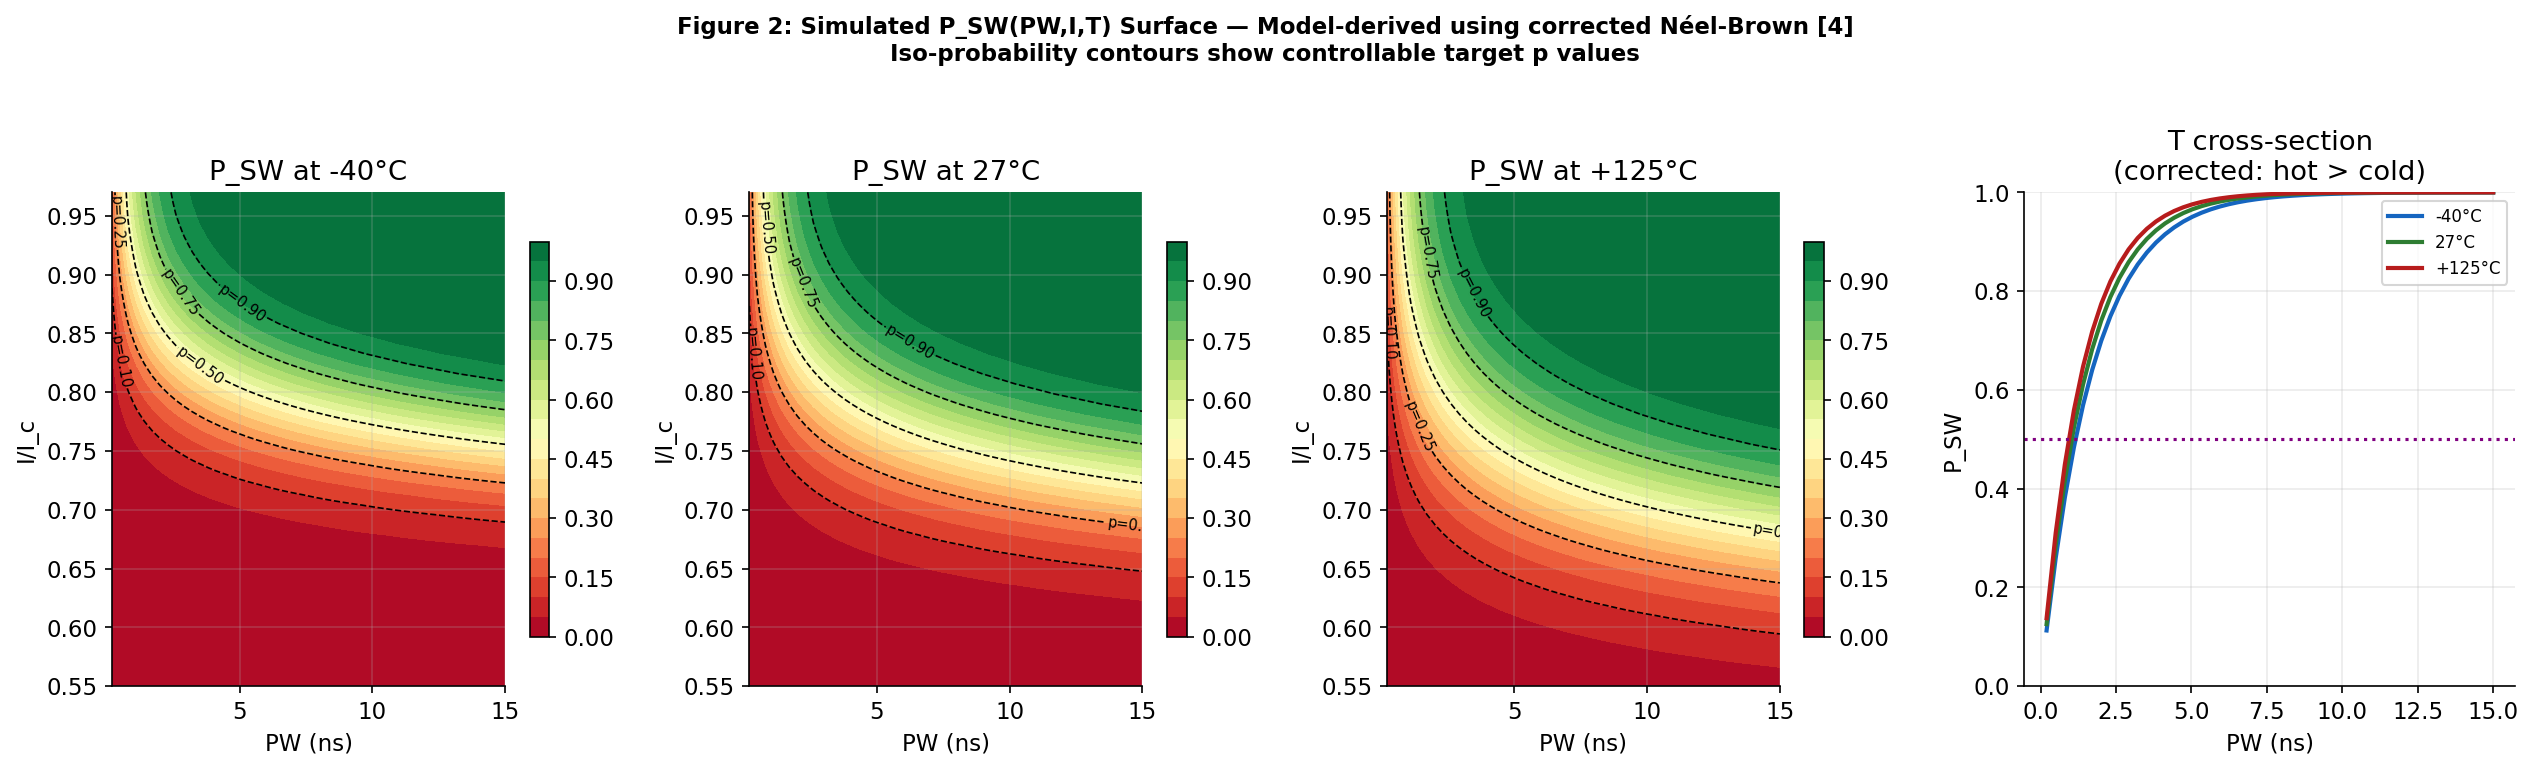

✓ Figure 2 saved (corrected physics)


In [5]:
print("\n"+"═"*65)
print("SECTION 2 — P_SW(PW,I,T) Surface (corrected physics)")
print("═"*65)

PW_grid = np.linspace(0.2e-9, 15e-9, 50)
IF_grid = np.linspace(0.55, 0.97, 50)
PW_m, IF_m = np.meshgrid(PW_grid, IF_grid)

def surface(PW_m, IF_m, T_K):
    p = np.zeros_like(PW_m)
    for i in range(PW_m.shape[0]):
        for j in range(PW_m.shape[1]):
            p[i,j] = P_SW_model(IF_m[i,j]*IC0, PW_m[i,j], T_K)
    return p

P_cold = surface(PW_m, IF_m, 233)
P_nom  = surface(PW_m, IF_m, 300)
P_hot  = surface(PW_m, IF_m, 398)

fig = plt.figure(figsize=(17, 5))
TGTS = [0.10, 0.25, 0.50, 0.75, 0.90]
for idx, (P, title) in enumerate(zip([P_cold, P_nom, P_hot],
                                      ["-40°C", "27°C", "+125°C"])):
    ax = fig.add_subplot(1, 4, idx+1)
    im = ax.contourf(PW_m*1e9, IF_m, P, levels=20, cmap='RdYlGn', vmin=0, vmax=1)
    cs = ax.contour(PW_m*1e9, IF_m, P, levels=TGTS,
                    colors='black', linewidths=0.8, linestyles='--')
    ax.clabel(cs, fmt='p=%.2f', fontsize=7)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set(xlabel="PW (ns)", ylabel="I/I_c", title=f"P_SW at {title}")

ax4 = fig.add_subplot(1, 4, 4)
for T_K, lbl, c in zip(AEC, AEC_L, TC):
    ax4.plot(PW_grid*1e9,
             [P_SW_model(I_W, pw, T_K) for pw in PW_grid],
             color=c, lw=2, label=lbl)
ax4.axhline(0.5, color='purple', ls=':', lw=1.5)
ax4.set(xlabel="PW (ns)", ylabel="P_SW", ylim=(0,1),
        title="T cross-section\n(corrected: hot > cold)")
ax4.legend(fontsize=8)

plt.suptitle(
    "Figure 2: Simulated P_SW(PW,I,T) Surface — Model-derived using corrected Néel-Brown [4]\n"
    "Iso-probability contours show controllable target p values",
    fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG}/fig2_surface.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 2 saved (corrected physics)")

## Section 3 — ngspice 1T1MTJ: .OP + .TRAN ELECTRICAL STATE CHARACTERISATION (E_pulse)


═════════════════════════════════════════════════════════════════
SECTION 3 — SKY130/ngspice 1T1MTJ State-Current Characterisation

Flow: Python Néel-Brown model [4] → switching decision →
      ngspice evaluates the ELECTRICAL state of the resulting cell (I_BL, E_pulse).

The MTJ is a fixed behavioral resistor (R_P or R_AP) in SPICE. No magnetization
switching is simulated in ngspice. Because the MTJ is represented as a fixed
behavioral resistor, the transient energy is the electrical pulse/access energy
of the modeled cell state, not a physically modeled magnetization-switching energy.

The 5 ns pulse is used as a reference electrical-state characterization; it is
NOT the proposed operating pulse for p=0.30 (PW*≈0.53 ns). Energy at the
calibrated operating point is evaluated separately as a design-space estimate
(Section 7, Fig. 7c).

Access device: see NMOS model line printed below (official sky130_fd_pr unless the
PDK download failed).
Optional high-fidelity mode (Verilog-A MTJ, K

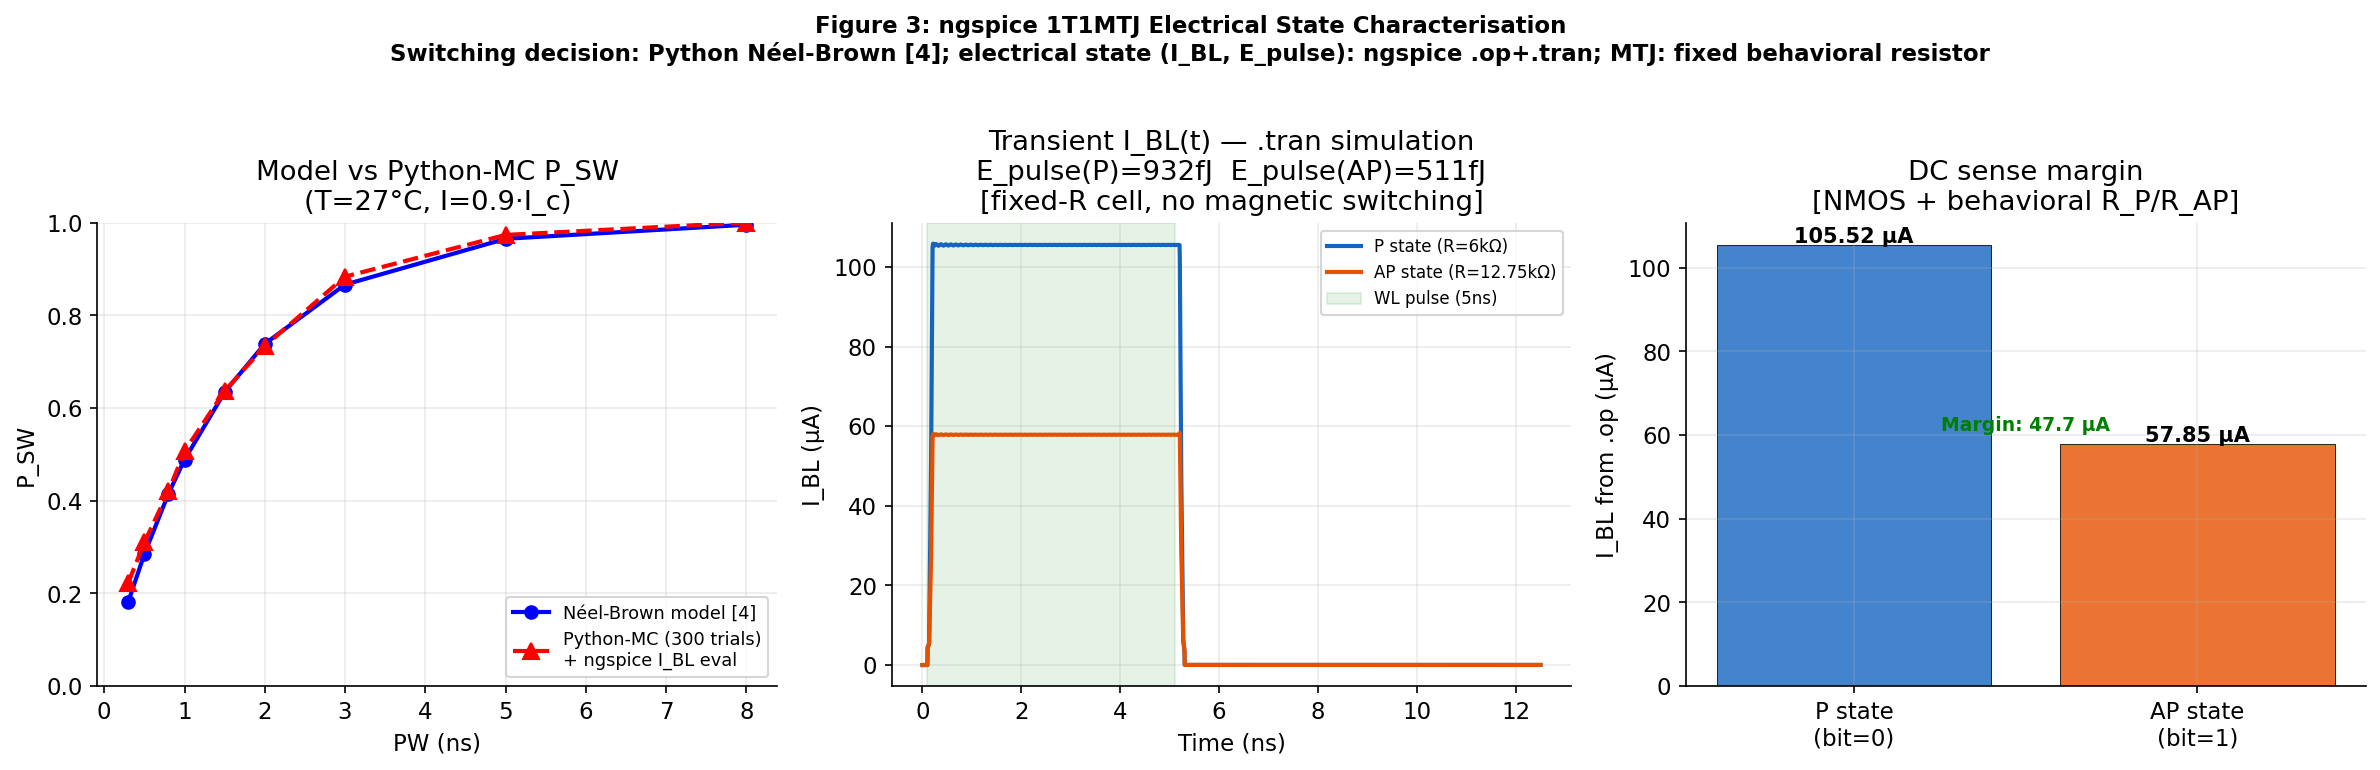


✓ Figure 3 saved (.op + .tran on fixed-R cell states)


In [6]:
print("\n"+"═"*65)
print("SECTION 3 — SKY130/ngspice 1T1MTJ State-Current Characterisation")
print("="*65)
print("""
Flow: Python Néel-Brown model [4] → switching decision →
      ngspice evaluates the ELECTRICAL state of the resulting cell (I_BL, E_pulse).

The MTJ is a fixed behavioral resistor (R_P or R_AP) in SPICE. No magnetization
switching is simulated in ngspice. Because the MTJ is represented as a fixed
behavioral resistor, the transient energy is the electrical pulse/access energy
of the modeled cell state, not a physically modeled magnetization-switching energy.

The 5 ns pulse is used as a reference electrical-state characterization; it is
NOT the proposed operating pulse for p=0.30 (PW*≈0.53 ns). Energy at the
calibrated operating point is evaluated separately as a design-space estimate
(Section 7, Fig. 7c).

Access device: see NMOS model line printed below (official sky130_fd_pr unless the
PDK download failed).
Optional high-fidelity mode (Verilog-A MTJ, Kim et al. [5]) = future work.
""")

# ── .op: state-current characterisation ──────────────────────────
def run_op(R_mtj, V_BL=VDD, V_WL=VDD):
    """ngspice .op — I_BL for given MTJ resistance state."""
    netlist = (
        "* 1T1MTJ .op — NMOS access + fixed behavioral MTJ resistor\n"
        + MODEL_HDR + NMOS_FMT.format(d="BL", g="WL", s="int_node", b="0") +
        f"R_mtj  int_node 0 {R_mtj}\n"
        f"Vbl BL 0 DC {V_BL}\n"
        f"Vwl WL 0 DC {V_WL}\n"
        ".op\n"
        ".save I(Vbl)\n"
        ".control\n"
        "run\n"
        "print I(Vbl)\n"
        "quit\n"
        ".endc\n"
        ".end\n"
    )
    fname = f"{SPC}/op.spice"
    with open(fname, 'w') as f: f.write(netlist)
    r = run_ngspice(fname, SPC)
    m = re.search(r'i\(vbl\)\s*=\s*([-+]?\d*\.?\d+[eE]?[-+]?\d*)',
                  r.stdout, re.I)
    if not m:
        raise RuntimeError("ngspice .op produced no I(Vbl) value:\n" + r.stdout[-1500:])
    return abs(float(m.group(1)))

I_P_op  = run_op(R_P)
I_AP_op = run_op(R_AP)
print(f"DC .op results — NMOS: {NMOS_SRC}, VDD={VDD}V:")
print(f"  I_BL(P  state, R=6kΩ):    {I_P_op*1e6:.3f} µA")
print(f"  I_BL(AP state, R=12.75kΩ): {I_AP_op*1e6:.3f} µA")
print(f"  Sense margin: {(I_P_op-I_AP_op)*1e6:.3f} µA")
print(f"  I_P/I_AP = {I_P_op/I_AP_op:.3f}  (> 1 → states distinguishable ✓)")

# ── .tran: pulse waveform + SPICE-extracted energy ────────────────
def run_tran(R_mtj, PW_ns=5.0, V_BL=VDD):
    """
    ngspice .tran — WL pulse on a FIXED-resistance cell, measure I_BL(t),
    integrate V_BL·I_BL over the pulse → E_pulse (electrical pulse/access energy).
    No magnetization switching occurs in this simulation.
    """
    tran_step = 0.05   # ns
    tran_stop  = PW_ns * 2.5
    netlist = (
        "* 1T1MTJ .tran — WL pulse, fixed MTJ state, extract E_pulse\n"
        + MODEL_HDR + NMOS_FMT.format(d="BL", g="WL", s="int_node", b="0") +
        f"R_mtj  int_node 0 {R_mtj}\n"
        f"Vbl BL 0 DC {V_BL}\n"
        f"Vwl WL 0 PULSE(0 {V_BL} 0.1n 0.1n 0.1n {PW_ns}n {tran_stop*2}n)\n"
        f".tran {tran_step}n {tran_stop}n\n"
        ".control\n"
        "run\n"
        f"wrdata {SPC}/tran_out.txt V(WL) I(Vbl)\n"
        "quit\n"
        ".endc\n"
        ".end\n"
    )
    fname = f"{SPC}/tran.spice"
    with open(fname, 'w') as f: f.write(netlist)
    if os.path.exists(f"{SPC}/tran_out.txt"): os.remove(f"{SPC}/tran_out.txt")
    run_ngspice(fname, SPC, expect=f"{SPC}/tran_out.txt")
    # Parse: columns are t, V(WL), t, I(Vbl)
    try:
        data = np.loadtxt(f"{SPC}/tran_out.txt")
        t     = data[:, 0]
        VWL   = data[:, 1]
        I_BL  = np.abs(data[:, 3])
        mask  = (t >= 0.1e-9) & (t <= (PW_ns + 0.1)*1e-9)
        E_J   = trapezoid(V_BL * I_BL[mask], t[mask])
        return t, VWL, I_BL, E_J
    except Exception:
        return None, None, None, 0.0

print(f"\nTransient .tran simulation (5 ns reference WL pulse, fixed MTJ state):")
t_P,  VWL_P,  I_P_t,  E_pulse_P  = run_tran(R_P,  PW_ns=5)
t_AP, VWL_AP, I_AP_t, E_pulse_AP = run_tran(R_AP, PW_ns=5)
E_pulse_spice = (E_pulse_P + E_pulse_AP) / 2

print(f"  P  state: peak I_BL={I_P_t.max()*1e6:.2f}µA  E_pulse={E_pulse_P*1e15:.1f}fJ")
print(f"  AP state: peak I_BL={I_AP_t.max()*1e6:.2f}µA  E_pulse={E_pulse_AP*1e15:.1f}fJ")
print(f"  Average E_pulse (electrical pulse/access energy, behavioral cell): {E_pulse_spice*1e15:.1f} fJ")

# Python-MC switching + ngspice state-current evaluation (P0-5 wording fix)
print(f"\nPython-MC switching + ngspice state-current evaluation:")
print(f"  (NOT 'SPICE Monte Carlo' — switching decision is in Python [4])")

def mc_switching(I_write, PW, T_K, N=300, seed=42):
    """
    Python Monte Carlo switching decision + ngspice state-current lookup.
    The switching event is decided in Python; ngspice only supplies I_BL
    for the resulting P or AP state.
    """
    rng = np.random.default_rng(seed)
    p_mod = P_SW_model(I_write, PW, T_K)
    switched = rng.random(N) < p_mod
    I_BL_arr = np.where(switched, I_AP_op, I_P_op)
    return p_mod, float(switched.sum()/N), I_BL_arr

PW_test = np.array([0.3,0.5,0.8,1.0,1.5,2.0,3.0,5.0,8.0])*1e-9
p_emp_arr = []
print(f"\n  {'PW(ns)':>8} | {'P_model':>9} | {'P_empirical':>11} | {'Mean I_BL(µA)':>14}")
print("  "+"-"*49)
for pw in PW_test:
    pm, pe, Iarr = mc_switching(I_W, pw, T_NOM, 300)
    p_emp_arr.append(pe)
    print(f"  {pw*1e9:>8.1f} | {pm:>9.4f} | {pe:>11.4f} | {Iarr.mean()*1e6:>12.3f}")

# ── Figure 3 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 3a: Model vs empirical P_SW
pm_arr = [P_SW_model(I_W, pw, T_NOM) for pw in PW_test]
axes[0].plot(PW_test*1e9, pm_arr, 'b-o', lw=2, ms=6, label='Néel-Brown model [4]')
axes[0].plot(PW_test*1e9, p_emp_arr, 'r^--', lw=2, ms=8,
             label='Python-MC (300 trials)\n+ ngspice I_BL eval')
axes[0].set(xlabel="PW (ns)", ylabel="P_SW", ylim=(0,1),
            title="Model vs Python-MC P_SW\n(T=27°C, I=0.9·I_c)")
axes[0].legend(fontsize=8.5)

# 3b: Transient waveforms
ax = axes[1]
if t_P is not None:
    ax.plot(t_P*1e9, I_P_t*1e6, '#1565C0', lw=2, label=f'P state (R={R_P/1e3:.0f}kΩ)')
    ax.plot(t_AP*1e9, I_AP_t*1e6, '#E65100', lw=2, label=f'AP state (R={R_AP/1e3:.2f}kΩ)')
    ax.axvspan(0.1, 5.1, alpha=0.1, color='green', label='WL pulse (5ns)')
ax.set(xlabel="Time (ns)", ylabel="I_BL (µA)",
       title=f"Transient I_BL(t) — .tran simulation\n"
             f"E_pulse(P)={E_pulse_P*1e15:.0f}fJ  E_pulse(AP)={E_pulse_AP*1e15:.0f}fJ\n[fixed-R cell, no magnetic switching]")
ax.legend(fontsize=8)

# 3c: DC sense margin bar
axes[2].bar(['P state\n(bit=0)', 'AP state\n(bit=1)'],
            [I_P_op*1e6, I_AP_op*1e6],
            color=['#1565C0','#E65100'], alpha=0.8, edgecolor='black', lw=0.5)
axes[2].set(ylabel="I_BL from .op (µA)",
            title="DC sense margin\n[NMOS + behavioral R_P/R_AP]")
for i, v in enumerate([I_P_op*1e6, I_AP_op*1e6]):
    axes[2].text(i, v+0.5, f'{v:.2f} µA', ha='center', fontsize=10, fontweight='bold')
axes[2].annotate(f'Margin: {(I_P_op-I_AP_op)*1e6:.1f} µA',
                 xy=(0.5, 0.55), xycoords='axes fraction',
                 ha='center', fontsize=9, color='green', fontweight='bold')

plt.suptitle(
    "Figure 3: ngspice 1T1MTJ Electrical State Characterisation\n"
    "Switching decision: Python Néel-Brown [4]; electrical state (I_BL, E_pulse): ngspice .op+.tran; MTJ: fixed behavioral resistor",
    fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG}/fig3_spice.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure 3 saved (.op + .tran on fixed-R cell states)")

## Section 4 — CALIBRATION ENGINE


═════════════════════════════════════════════════════════════════
SECTION 4 — Calibration Engine: p* → PW*(T)
═════════════════════════════════════════════════════════════════
PW*(T) = −τ(I,T)·ln(1−p*)
Exact analytical inversion of the adopted exponential switching model.
Physical accuracy requires silicon calibration — model-based only.

    p* |    PW*(ns) |    p_check
--------------------------------
  0.05 |     0.0765 |   0.050000
  0.10 |     0.1572 |   0.100000
  0.20 |     0.3329 |   0.200000
  0.30 |     0.5321 |   0.300000
  0.50 |     1.0341 |   0.500000
  0.70 |     1.7961 |   0.700000
  0.90 |     3.4351 |   0.900000
  0.95 |     4.4691 |   0.950000

T-compensated calibration (p*=0.50):
   T(°C)|   P_fixed|   PW_cal*(ns)|   P_cal
     -40°C|    0.4609|        1.1601|  0.5000
       0°C|    0.4864|        1.0758|  0.5000
      27°C|    0.5000|        1.0341|  0.5000
      77°C|    0.5200|        0.9766|  0.5000
     100°C|    0.5274|        0.9562|  0.5000
     125°C|    0

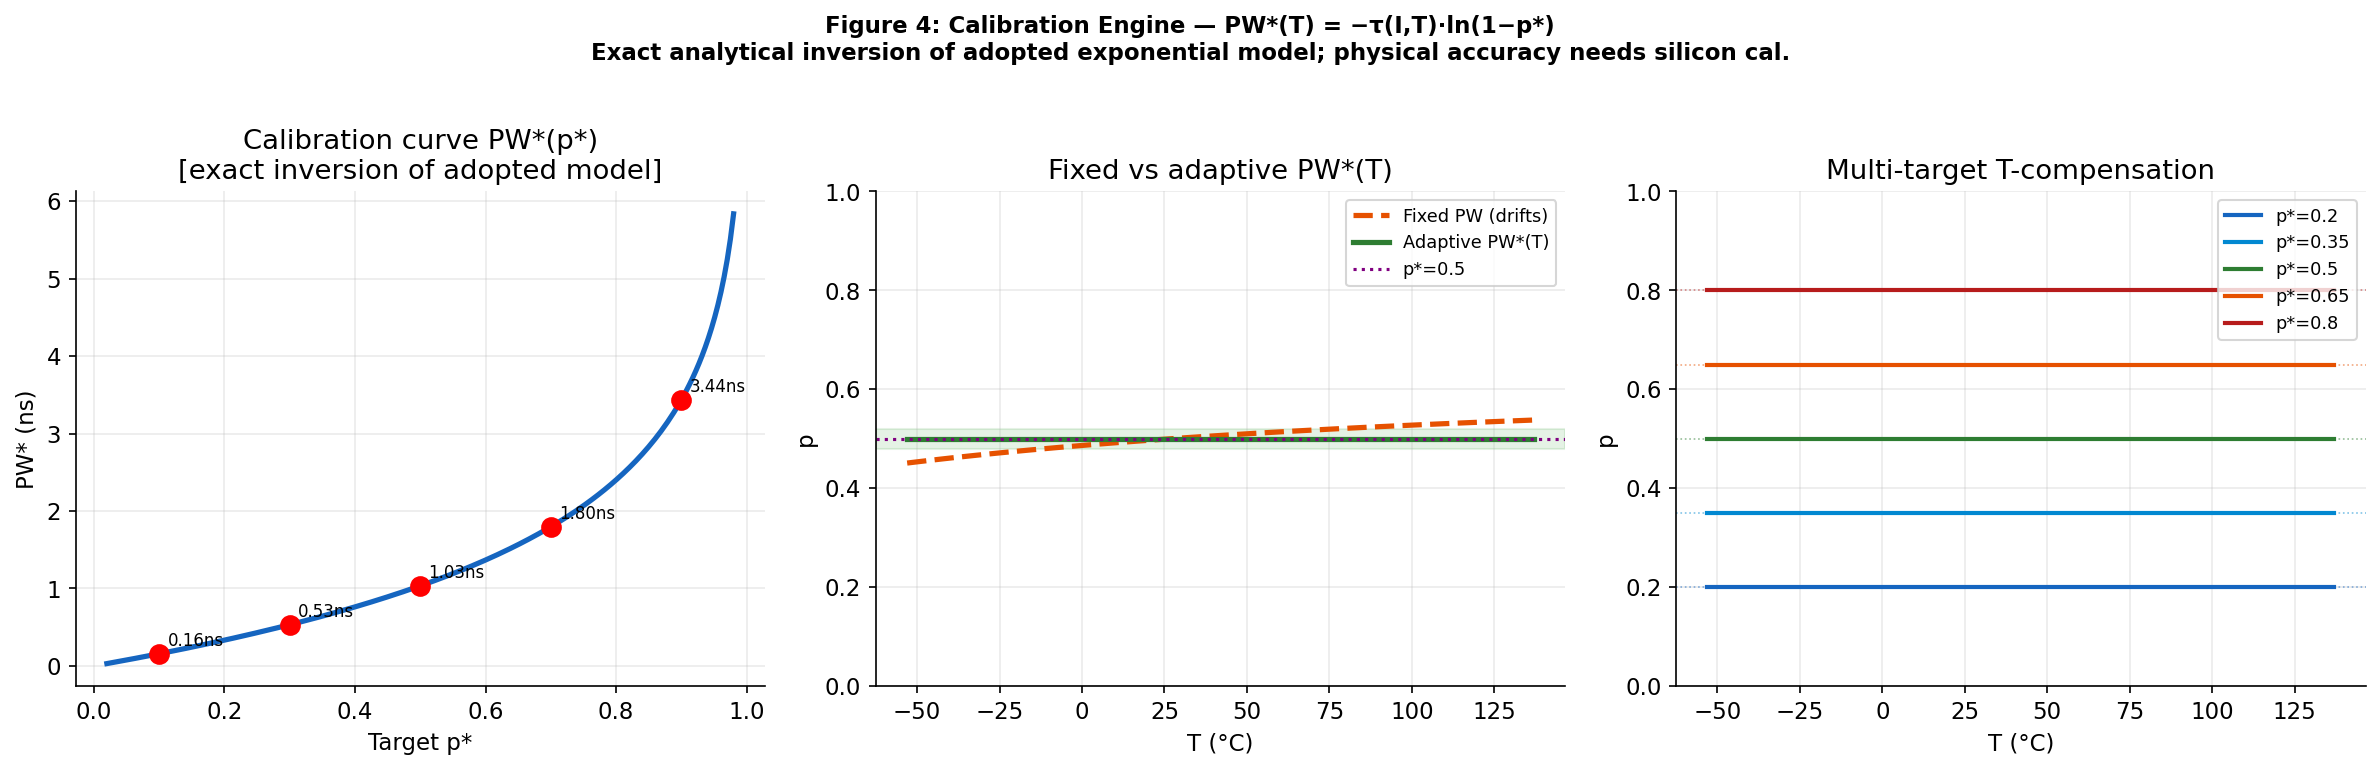


✓ Figure 4 saved


In [7]:
print("\n"+"═"*65)
print("SECTION 4 — Calibration Engine: p* → PW*(T)")
print("═"*65)
print("PW*(T) = −τ(I,T)·ln(1−p*)")
print("Exact analytical inversion of the adopted exponential switching model.")
print("Physical accuracy requires silicon calibration — model-based only.\n")

print(f"{'p*':>6} | {'PW*(ns)':>10} | {'p_check':>10}")
print("-"*32)
cal_rows = []
for p in [0.05,0.10,0.20,0.30,0.50,0.70,0.90,0.95]:
    pw  = pw_star(p, I_W, T_NOM)
    pch = P_SW_model(I_W, pw, T_NOM)
    cal_rows.append({'p*':p, 'PW*(ns)':pw*1e9, 'p_check':pch})
    print(f"  {p:>4.2f} | {pw*1e9:>10.4f} | {pch:>10.6f}")
pd.DataFrame(cal_rows).to_csv(f"{RES}/calibration.csv", index=False)

T_range = np.linspace(220, 410, 100)
pw_fixed_50 = pw_star(0.50, I_W, T_NOM)
print("\nT-compensated calibration (p*=0.50):")
print(f"{'T(°C)':>8}|{'P_fixed':>10}|{'PW_cal*(ns)':>14}|{'P_cal':>8}")
for T_K in [233,273,300,350,373,398]:
    pw_c = pw_star(0.50, I_W, T_K)
    print(f"  {T_K-273:>6}°C|{P_SW_model(I_W,pw_fixed_50,T_K):>10.4f}|"
          f"{pw_c*1e9:>14.4f}|{P_SW_model(I_W,pw_c,T_K):>8.4f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
p_r = np.linspace(0.02, 0.98, 200)
axes[0].plot(p_r, [pw_star(p,I_W,T_NOM)*1e9 for p in p_r], '#1565C0', lw=2.5)
for p_s in [0.10,0.30,0.50,0.70,0.90]:
    pw_s = pw_star(p_s,I_W,T_NOM)*1e9
    axes[0].scatter([p_s],[pw_s], color='red', s=80, zorder=5)
    axes[0].annotate(f'{pw_s:.2f}ns', xy=(p_s,pw_s), xytext=(4,4),
                     textcoords='offset points', fontsize=8)
axes[0].set(xlabel="Target p*", ylabel="PW* (ns)",
            title="Calibration curve PW*(p*)\n[exact inversion of adopted model]")

axes[1].plot(T_range-273,
             [P_SW_model(I_W,pw_fixed_50,T) for T in T_range],
             '#E65100', lw=2.5, ls='--', label='Fixed PW (drifts)')
axes[1].plot(T_range-273,
             [P_SW_model(I_W,pw_star(0.5,I_W,T),T) for T in T_range],
             '#2E7D32', lw=2.5, label='Adaptive PW*(T)')
axes[1].axhline(0.5, color='purple', ls=':', lw=1.5, label='p*=0.5')
axes[1].axhspan(0.48,0.52, alpha=0.1, color='green')
axes[1].set(xlabel="T (°C)", ylabel="p", ylim=(0,1),
            title="Fixed vs adaptive PW*(T)")
axes[1].legend(fontsize=8.5)

for p_s, c in zip([0.20,0.35,0.50,0.65,0.80],
                   ['#1565C0','#0288D1','#2E7D32','#E65100','#B71C1C']):
    axes[2].plot(T_range-273,
                 [P_SW_model(I_W,pw_star(p_s,I_W,T),T) for T in T_range],
                 color=c, lw=2, label=f'p*={p_s}')
    axes[2].axhline(p_s, color=c, ls=':', lw=0.8, alpha=0.5)
axes[2].set(xlabel="T (°C)", ylabel="p", ylim=(0,1),
            title="Multi-target T-compensation")
axes[2].legend(fontsize=8.5)

plt.suptitle(
    "Figure 4: Calibration Engine — PW*(T) = −τ(I,T)·ln(1−p*)\n"
    "Exact analytical inversion of adopted exponential model; physical accuracy needs silicon cal.",
    fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG}/fig4_calibration.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure 4 saved")

## Section 5 — SENSITIVITY TO ASSUMED DEVICE-PARAMETER VARIATION

**Variation assumptions** — θ_i = θ₀ + θ_global + θ_local,i

| Parameter | Variation (1σ) | Basis |
|---|---|---|
| I_c0 global | 6 % of I_c0 | Assumed — sensitivity study |
| I_c0 local | 4 % of I_c0 | Assumed — sensitivity study |
| Δ global | 4 % of Δ₀ | Assumed |
| Δ local | 3 % of Δ₀ | Assumed |
| Temperature | 3 K global / 1.5 K local | Model assumption |

> **Unless otherwise referenced, variation magnitudes are assumed stress-test values rather than experimentally extracted distributions.** The "fraction within ±5 %" metric below is a sensitivity measure, not a manufacturing-yield prediction.



═════════════════════════════════════════════════════════════════
SECTION 5 — Sensitivity to Assumed Device-Parameter Variation
═════════════════════════════════════════════════════════════════

Variation magnitudes are ASSUMED stress-test values, not extracted
manufacturing statistics (see table above).
  This section varies: Δ, I_c0, T (device-level model parameters)
  Circuit-level PVT (VDD variation, SKY130 MOSFET corners) = future work

Variation model: θ_i = θ_0 + θ_global + θ_local,i
  θ_global: lot-to-lot / wafer variation (shared by all cells on die)
  θ_local,i: cell-to-cell mismatch (independent per cell)

Device-parameter MC (N=3000, target p*=0.5):
       T|  μ(cal)|  σ(cal)| within±5%| within±10%
----------------------------------------------
   -40°C|  0.4728|  0.1740|    17.7%|     35.1%
    27°C|  0.4748|  0.1431|    21.8%|     45.0%
  +125°C|  0.4783|  0.1136|    30.5%|     60.4%


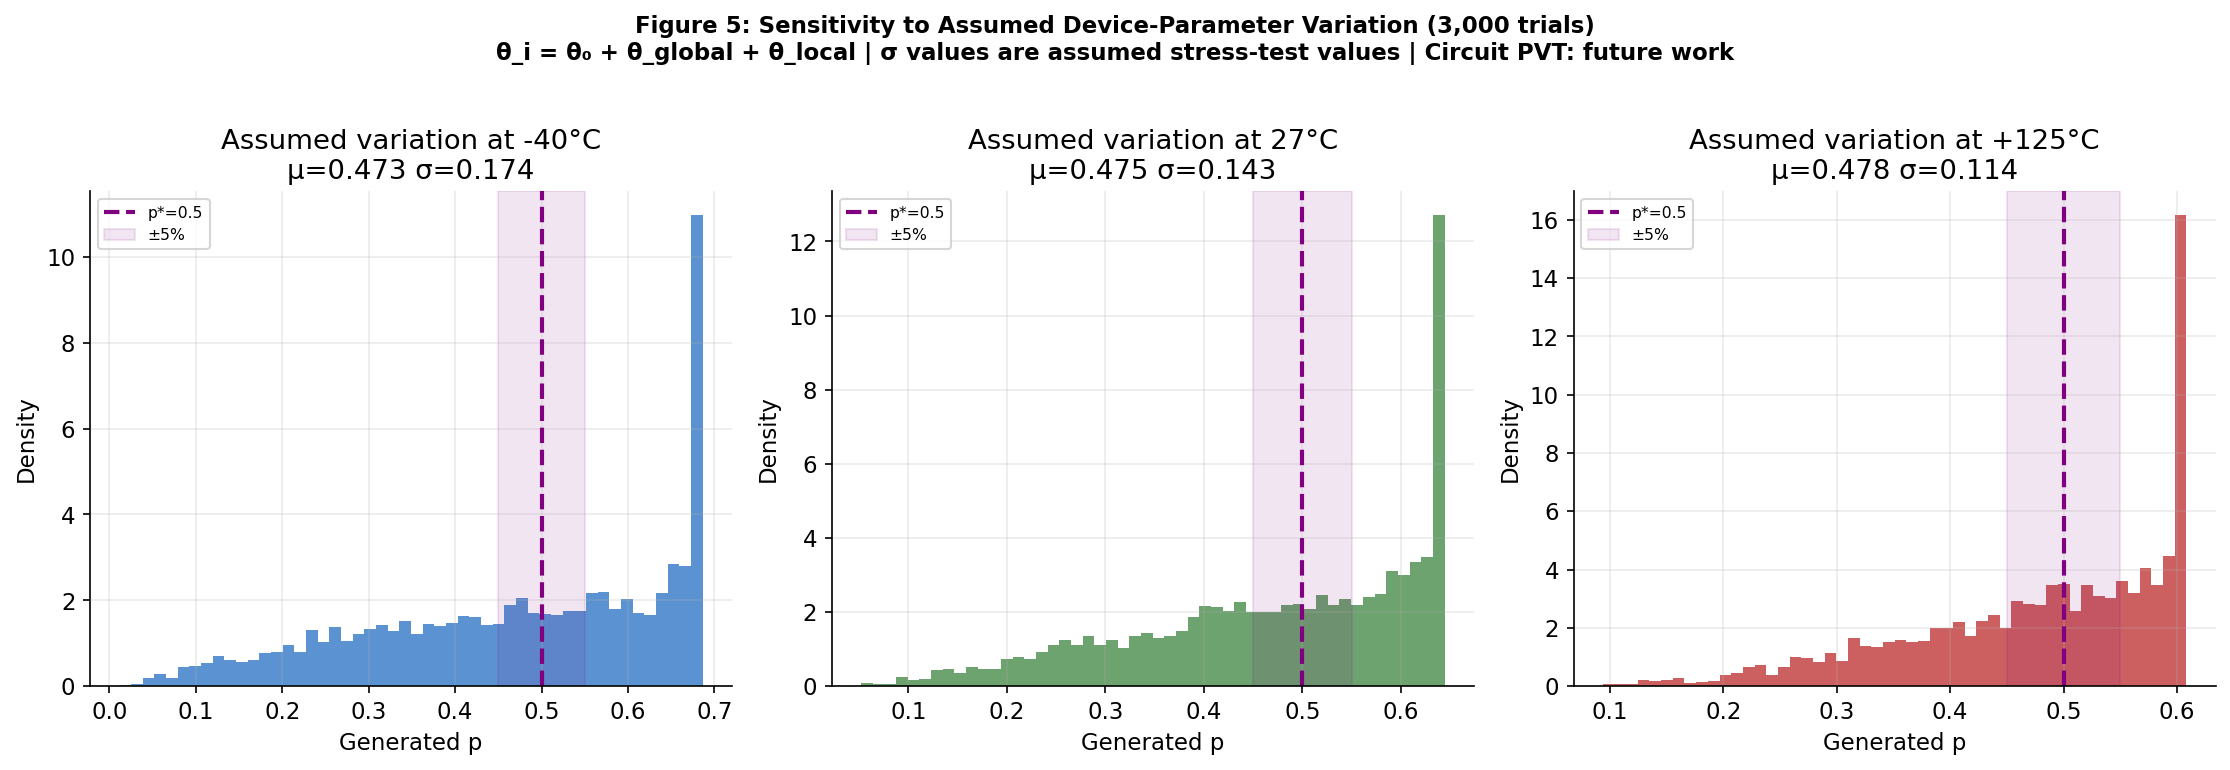

✓ Figure 5 saved


In [8]:
print("\n"+"═"*65)
print("SECTION 5 — Sensitivity to Assumed Device-Parameter Variation")
print("═"*65)
print("""
Variation magnitudes are ASSUMED stress-test values, not extracted
manufacturing statistics (see table above).
  This section varies: Δ, I_c0, T (device-level model parameters)
  Circuit-level PVT (VDD variation, SKY130 MOSFET corners) = future work

Variation model: θ_i = θ_0 + θ_global + θ_local,i
  θ_global: lot-to-lot / wafer variation (shared by all cells on die)
  θ_local,i: cell-to-cell mismatch (independent per cell)
""")

N_MC_PVT = 3000
TARGET = 0.50
rng_pv = np.random.default_rng(99)
mc_pvt = {}

print(f"Device-parameter MC (N={N_MC_PVT}, target p*={TARGET}):")
print(f"{'T':>8}|{'μ(cal)':>8}|{'σ(cal)':>8}|{'within±5%':>10}|{'within±10%':>11}")
print("-"*46)
for T_K, lbl in zip(AEC, AEC_L):
    dg  = rng_pv.normal(0, SG_D,  N_MC_PVT)
    dl  = rng_pv.normal(0, SL_D,  N_MC_PVT)
    ig  = rng_pv.normal(0, SG_IC, N_MC_PVT)
    il  = rng_pv.normal(0, SL_IC, N_MC_PVT)
    Tg  = rng_pv.normal(0, SG_T,  N_MC_PVT)
    Tl  = rng_pv.normal(0, SL_T,  N_MC_PVT)
    d_eff  = np.clip(DELTA0 + dg + dl, 5, 200)
    ic_eff = np.clip(IC0 + ig + il, IC0*0.3, IC0*2)
    T_eff  = T_K + Tg + Tl
    pw_c   = pw_star(TARGET, I_W, T_K)
    pc = np.array([P_SW_model(I_W, pw_c, T_eff[i], ic0=ic_eff[i], d0=d_eff[i])
                   for i in range(N_MC_PVT)])
    mc_pvt[lbl] = pc
    y5  = np.mean(np.abs(pc-TARGET) < 0.05) * 100
    y10 = np.mean(np.abs(pc-TARGET) < 0.10) * 100
    print(f"  {lbl:>6}|{pc.mean():>8.4f}|{pc.std():>8.4f}|{y5:>8.1f}%|{y10:>9.1f}%")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, (lbl, c) in enumerate(zip(AEC_L, TC)):
    ax = axes[idx]
    ax.hist(mc_pvt[lbl], bins=50, color=c, alpha=0.7, density=True, edgecolor='none')
    ax.axvline(TARGET, color='purple', ls='--', lw=2, label=f'p*={TARGET}')
    ax.axvspan(TARGET-0.05, TARGET+0.05, alpha=0.1, color='purple', label='±5%')
    ax.set(xlabel="Generated p", ylabel="Density",
           title=f"Assumed variation at {lbl}\nμ={mc_pvt[lbl].mean():.3f} σ={mc_pvt[lbl].std():.3f}")
    ax.legend(fontsize=7.5)
plt.suptitle(
    f"Figure 5: Sensitivity to Assumed Device-Parameter Variation ({N_MC_PVT:,} trials)\n"
    "θ_i = θ₀ + θ_global + θ_local | σ values are assumed stress-test values | Circuit PVT: future work",
    fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG}/fig5_device_mc.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 5 saved")

## Section 6 — STATISTICAL QUALITY + CROSS-CELL SAMPLE CORRELATION


═════════════════════════════════════════════════════════════════
SECTION 6 — Statistical Quality & Cross-Cell Sample Correlation
═════════════════════════════════════════════════════════════════
Statistical quality (p*=0.3, 100,000 bits):
       T|   p_obs|  |bias||     AC[1]|    H(p)
------------------------------------------------
   -40°C|  0.2991| 0.00093|  0.004065|  0.8802
    27°C|  0.3006| 0.00063|  0.003333|  0.8821
  +125°C|  0.2985| 0.00147| -0.006261|  0.8795

Cross-cell correlation (correlated device-parameter model, 16 cells):
  Mean |ρ_ij| = 0.00243
  Max  |ρ_ij| = 0.00839
  Conditional Bernoulli streams exhibit low sample correlation under the
  modeled parameter distribution. NOTE: each cell's bits are drawn
  independently given its p_c, so this does NOT validate physical
  independence (shared thermal/supply noise, read disturb). A hierarchical
  global/local time-varying experiment is future work.


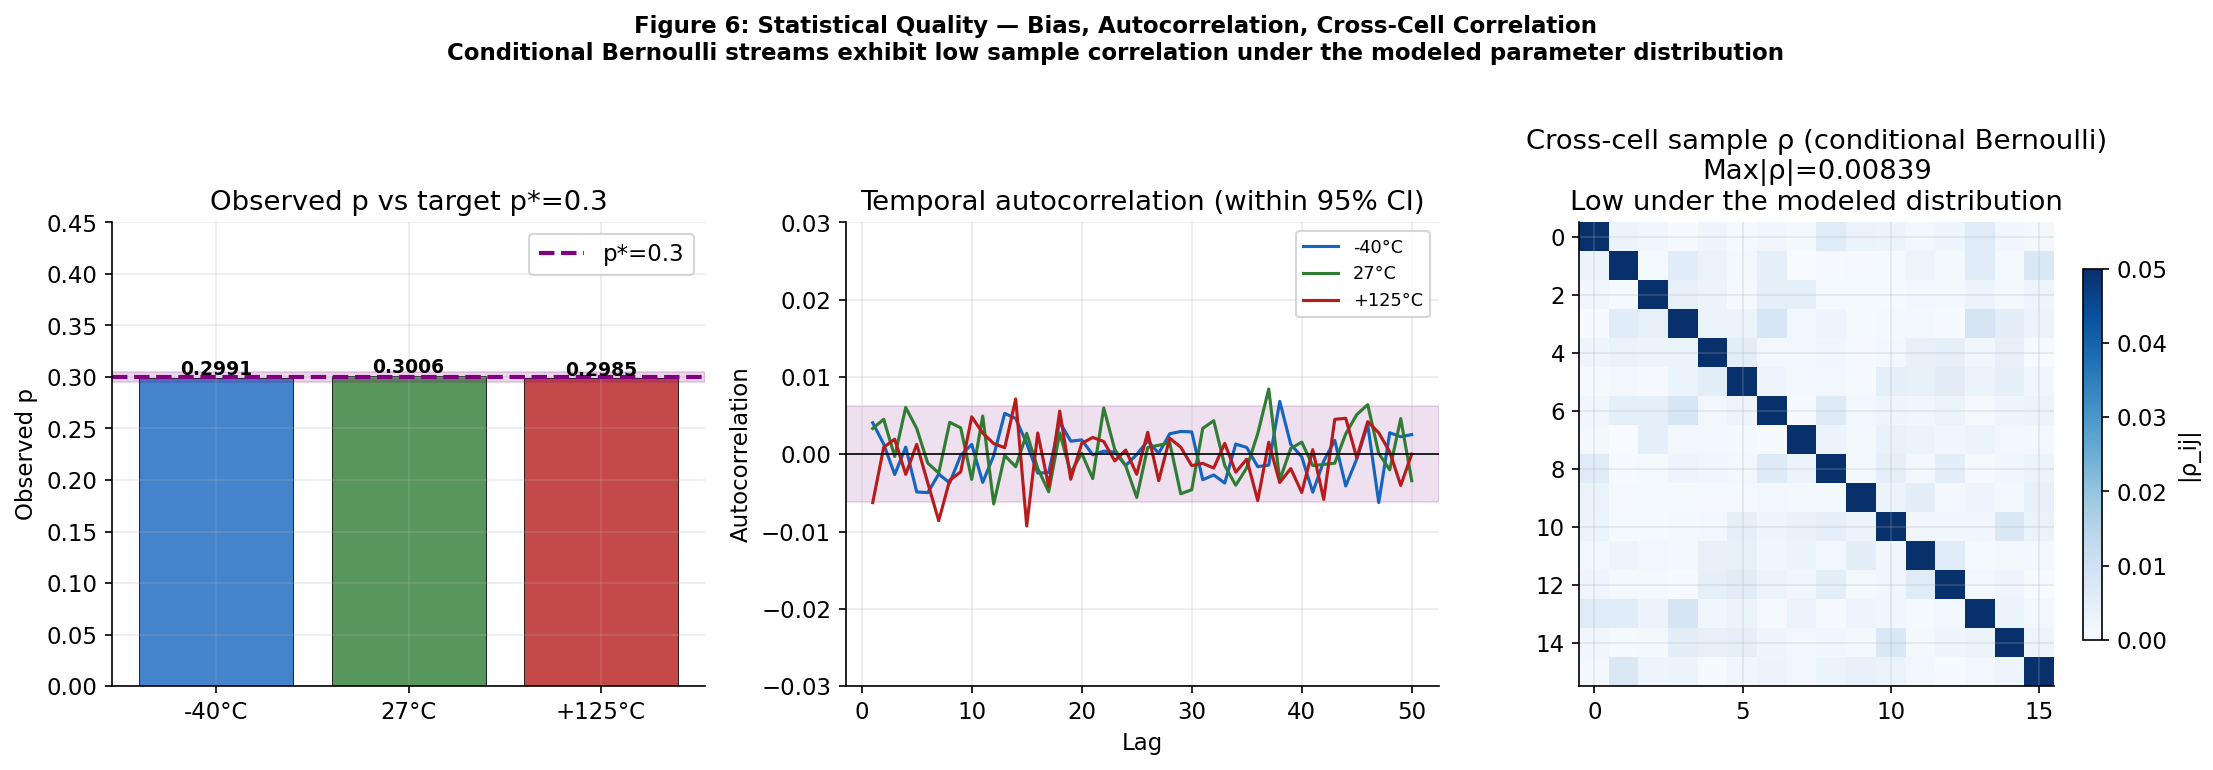


✓ Figure 6 saved


In [9]:
print("\n"+"═"*65)
print("SECTION 6 — Statistical Quality & Cross-Cell Sample Correlation")
print("═"*65)

N_BITS = 100_000
P_DROP = 0.30

def gen_stream(p_star, T_K, n=N_BITS, seed=42):
    rng = np.random.default_rng(seed)
    pw  = pw_star(p_star, I_W, T_K)
    p_eff = P_SW_model(I_W, pw, T_K)
    return (rng.random(n) < p_eff).astype(np.int8)

def autocorr(bits, max_lag=100):
    b = bits.astype(float) - bits.mean()
    v = np.var(b)
    return (np.array([np.mean(b[:-k]*b[k:])/v for k in range(1,max_lag+1)])
            if v > 1e-10 else np.zeros(max_lag))

streams = {}
print(f"Statistical quality (p*={P_DROP}, {N_BITS:,} bits):")
print(f"{'T':>8}|{'p_obs':>8}|{'|bias|':>8}|{'AC[1]':>10}|{'H(p)':>8}")
print("-"*48)
for T_K, lbl in zip(AEC, AEC_L):
    bits = gen_stream(P_DROP, T_K, seed=T_K)
    streams[lbl] = bits
    p_obs = bits.mean(); ac1 = autocorr(bits,2)[0]
    H = -p_obs*np.log2(p_obs+1e-10) - (1-p_obs)*np.log2(1-p_obs+1e-10)
    print(f"  {lbl:>6}|{p_obs:>8.4f}|{abs(p_obs-P_DROP):>8.5f}|{ac1:>10.6f}|{H:>8.4f}")

# Cross-cell correlation (correlated model, P2-10 wording fix)
rng_cc = np.random.default_rng(55)
dg_cc = rng_cc.normal(0, SG_D); ig_cc = rng_cc.normal(0, SG_IC)
Tg_cc = rng_cc.normal(0, SG_T)
cell_bits = []
for ci in range(16):
    dl_ = rng_cc.normal(0, SL_D); il_ = rng_cc.normal(0, SL_IC)
    d_  = np.clip(DELTA0+dg_cc+dl_, 5, 200)
    ic_ = np.clip(IC0+ig_cc+il_, IC0*0.3, IC0*2)
    T_  = T_NOM + Tg_cc + rng_cc.normal(0, SL_T)
    p_c = P_SW_model(I_W, pw_star(P_DROP,I_W,T_NOM), T_, ic0=ic_, d0=d_)
    cell_bits.append((np.random.default_rng(ci+100).random(N_BITS) < p_c).astype(np.int8))
corr_mat = np.corrcoef(np.array(cell_bits))
off_diag = corr_mat[np.triu_indices(16, k=1)]
print(f"\nCross-cell correlation (correlated device-parameter model, 16 cells):")
print(f"  Mean |ρ_ij| = {np.mean(np.abs(off_diag)):.5f}")
print(f"  Max  |ρ_ij| = {np.max(np.abs(off_diag)):.5f}")
# P2-10 wording fix
print(f"  Conditional Bernoulli streams exhibit low sample correlation under the")
print(f"  modeled parameter distribution. NOTE: each cell's bits are drawn")
print(f"  independently given its p_c, so this does NOT validate physical")
print(f"  independence (shared thermal/supply noise, read disturb). A hierarchical")
print(f"  global/local time-varying experiment is future work.")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
bars = axes[0].bar(AEC_L, [streams[l].mean() for l in AEC_L],
                   color=TC, alpha=0.8, edgecolor='black', lw=0.5)
axes[0].axhline(P_DROP, color='purple', ls='--', lw=2, label=f'p*={P_DROP}')
axes[0].axhspan(P_DROP-0.005, P_DROP+0.005, alpha=0.15, color='purple')
for bar, pv in zip(bars, [streams[l].mean() for l in AEC_L]):
    axes[0].text(bar.get_x()+bar.get_width()/2, pv+0.003,
                 f'{pv:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set(ylabel="Observed p", ylim=(0, 0.45), title=f"Observed p vs target p*={P_DROP}")
axes[0].legend()

lags = np.arange(1, 51); ci_val = 1.96/np.sqrt(N_BITS)
for lbl, c in zip(AEC_L, TC):
    axes[1].plot(lags, autocorr(streams[lbl], 50), color=c, lw=1.5, label=lbl)
axes[1].axhspan(-ci_val, ci_val, alpha=0.12, color='purple')
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set(xlabel="Lag", ylabel="Autocorrelation", ylim=(-0.03, 0.03),
            title="Temporal autocorrelation (within 95% CI)")
axes[1].legend(fontsize=8.5)

im = axes[2].imshow(np.abs(corr_mat), cmap='Blues', vmin=0, vmax=0.05, aspect='auto')
plt.colorbar(im, ax=axes[2], shrink=0.8, label='|ρ_ij|')
axes[2].set(title=f"Cross-cell sample ρ (conditional Bernoulli)\n"
                  f"Max|ρ|={np.max(np.abs(off_diag)):.5f}\n"
                  f"Low under the modeled distribution")

plt.suptitle(
    "Figure 6: Statistical Quality — Bias, Autocorrelation, Cross-Cell Correlation\n"
    "Conditional Bernoulli streams exhibit low sample correlation under the modeled parameter distribution",
    fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG}/fig6_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure 6 saved")

## Section 7 — SYSTEM-LEVEL ENERGY ESTIMATE: E_pulse (.tran) + PARAMETRIC SENSITIVITY


═════════════════════════════════════════════════════════════════
SECTION 7 — System-Level Energy Estimate (E_pulse + parametric overheads)
═════════════════════════════════════════════════════════════════

E_pulse comes from the Section 3 .tran on a FIXED behavioral MTJ resistor:
it is the electrical pulse/access energy of the modeled cell state, not a
physically modeled magnetization-switching energy.
Driver, sense and LFSR energies are parametric estimates (extraction = future work).
The 5 ns pulse is a reference electrical-state characterization, not the proposed
operating pulse for p=0.30; the calibrated operating point is evaluated separately
below as a design-space estimate.

E_pulse (5 ns reference pulse, from .tran):
  P  state = 931.6 fJ   AP state = 510.8 fJ   avg = 721.2 fJ
Parametric: E_read = 24.9 fJ  (V_read=0.18 V, 5 ns)

MTJ total @ C_drv=10fF, C_sns=5fF : 770.4 fJ
LFSR baseline @ C_FF=5fF          : 153.9 fJ

Gap (MTJ / LFSR):
  E_pulse alone        : 4.7×
  Referenc

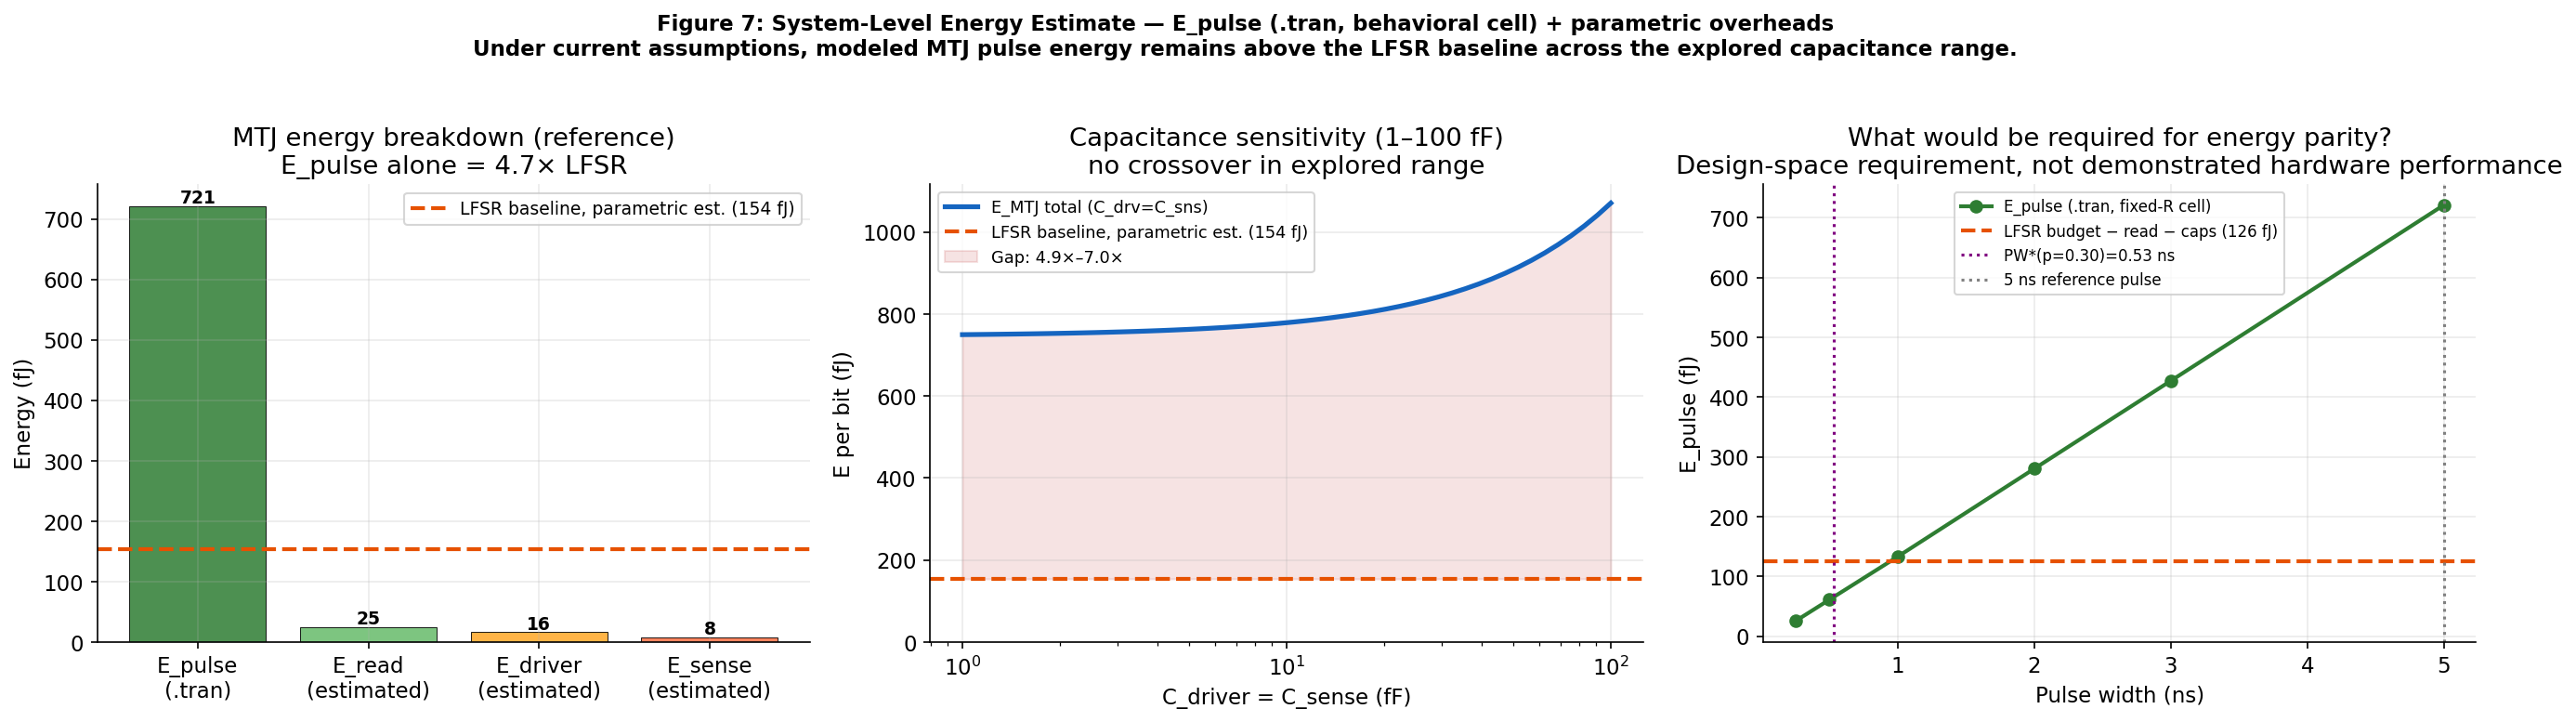


✓ Figure 7 saved (honest gap, no crossover region)


In [10]:
print("\n"+"═"*65)
print("SECTION 7 — System-Level Energy Estimate (E_pulse + parametric overheads)")
print("═"*65)
print("""
E_pulse comes from the Section 3 .tran on a FIXED behavioral MTJ resistor:
it is the electrical pulse/access energy of the modeled cell state, not a
physically modeled magnetization-switching energy.
Driver, sense and LFSR energies are parametric estimates (extraction = future work).
The 5 ns pulse is a reference electrical-state characterization, not the proposed
operating pulse for p=0.30; the calibrated operating point is evaluated separately
below as a design-space estimate.
""")

# ── E_pulse from Section 3 .tran (5 ns reference pulse) ──
E_pulse_avg = E_pulse_spice

# ── Read energy (v4 fix: previous version computed V/R·t = charge, not energy) ──
V_READ, T_READ, R_ON = 0.1*VDD, 5e-9, 500.0
E_read = V_READ**2 / (R_P + R_ON) * T_READ

C_range = np.logspace(np.log10(1e-15), np.log10(100e-15), 50)

def E_mtj_total(C_drv, C_sns, E_p=None):
    E_p = E_pulse_avg if E_p is None else E_p
    return E_p + E_read + 0.5*C_drv*VDD**2 + 0.5*C_sns*VDD**2

def E_lfsr_total(C_FF, C_cmp):
    return (16*C_FF + 8*1e-15)*VDD**2*0.5 + C_cmp*VDD**2*0.5 + 2e-15*VDD**2

E_MTJ_ref  = E_mtj_total(10e-15, 5e-15)
E_LFSR_ref = E_lfsr_total(5e-15, 3e-15)
E_mtj_sweep = np.array([E_mtj_total(C, C) for C in C_range])
ratio_pulse = E_pulse_avg / E_LFSR_ref
ratio_ref   = E_MTJ_ref / E_LFSR_ref
ratio_min   = E_mtj_sweep.min() / E_LFSR_ref

print(f"E_pulse (5 ns reference pulse, from .tran):")
print(f"  P  state = {E_pulse_P*1e15:.1f} fJ   AP state = {E_pulse_AP*1e15:.1f} fJ   avg = {E_pulse_avg*1e15:.1f} fJ")
print(f"Parametric: E_read = {E_read*1e15:.1f} fJ  (V_read={V_READ:.2f} V, {T_READ*1e9:.0f} ns)")
print(f"\nMTJ total @ C_drv=10fF, C_sns=5fF : {E_MTJ_ref*1e15:.1f} fJ")
print(f"LFSR baseline @ C_FF=5fF          : {E_LFSR_ref*1e15:.1f} fJ")
print(f"\nGap (MTJ / LFSR):")
print(f"  E_pulse alone        : {ratio_pulse:.1f}×")
print(f"  Reference total      : {ratio_ref:.1f}×")
print(f"  Best case over sweep : {ratio_min:.1f}×  (C=1 fF)")
print(f"\nUnder current assumptions, modeled MTJ pulse energy remains above the LFSR")
print(f"baseline across the explored 1–100 fF capacitance range (no crossover).")

# ── Why, and what a crossover would require ──
# E_pulse ∝ V_BL · I_BL · PW. Sweep PW on the same fixed-R cells.
PW_sweep = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0])
E_vs_PW = []
for pw in PW_sweep:
    _, _, _, eP = run_tran(R_P,  PW_ns=pw)
    _, _, _, eA = run_tran(R_AP, PW_ns=pw)
    E_vs_PW.append((eP+eA)/2)
E_vs_PW = np.array(E_vs_PW)
PW_STAR_30 = pw_star(0.30, I_W, T_NOM)
E_pulse_star = np.interp(PW_STAR_30*1e9, PW_sweep, E_vs_PW)
budget_pulse = E_LFSR_ref - E_read - 0.5*2e-15*VDD**2      # LFSR budget minus read & 1fF+1fF caps
E_reset_budget = (budget_pulse - E_pulse_star) / 0.30       # conditional restore after a switch (prob p)

print(f"\nWhy the gap: the 5 ns reference pulse drives ~{I_P_op*1e6:.0f}/{I_AP_op*1e6:.0f} µA at {VDD} V for its full")
print(f"duration; E_pulse scales ~linearly with PW (Fig. 7c).")
print(f"What would be required for energy parity (design-space requirement, p*=0.30):")
print(f"  • stochastic pulse at the calibrated PW*≈{PW_STAR_30*1e9:.2f} ns → E_pulse≈{E_pulse_star*1e15:.0f} fJ")
print(f"    (vs {E_pulse_avg*1e15:.0f} fJ at the 5 ns reference), AND")
print(f"  • a conditional restore (reset) pulse costing < {max(E_reset_budget,0)*1e15:.0f} fJ per event")
print(f"    (it fires with probability p); a 5 ns restore at this bias costs ≈{E_pulse_avg*1e15:.0f} fJ.")
print(f"  Design-space requirement, not demonstrated hardware performance.")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 7a: breakdown
components = ['E_pulse\n(.tran)', 'E_read\n(estimated)', 'E_driver\n(estimated)', 'E_sense\n(estimated)']
vals = [E_pulse_avg*1e15, E_read*1e15, 0.5*10e-15*VDD**2*1e15, 0.5*5e-15*VDD**2*1e15]
bars_e = axes[0].bar(components, vals, color=['#2E7D32','#66BB6A','#FFA726','#FF7043'],
                     alpha=0.85, edgecolor='black', lw=0.5)
axes[0].axhline(E_LFSR_ref*1e15, color='#E65100', ls='--', lw=2,
                label=f'LFSR baseline, parametric est. ({E_LFSR_ref*1e15:.0f} fJ)')
for bar, v in zip(bars_e, vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5, f'{v:.0f}', ha='center', fontsize=9, fontweight='bold')
axes[0].set(ylabel="Energy (fJ)",
            title=f"MTJ energy breakdown (reference)\nE_pulse alone = {ratio_pulse:.1f}× LFSR")
axes[0].legend(fontsize=9)

# 7b: sensitivity sweep — gap shown, no "wins" region
axes[1].semilogx(C_range*1e15, E_mtj_sweep*1e15, '#1565C0', lw=2.5, label='E_MTJ total (C_drv=C_sns)')
axes[1].axhline(E_LFSR_ref*1e15, color='#E65100', ls='--', lw=2, label=f'LFSR baseline, parametric est. ({E_LFSR_ref*1e15:.0f} fJ)')
axes[1].fill_between(C_range*1e15, E_LFSR_ref*1e15, E_mtj_sweep*1e15, color='#B71C1C', alpha=0.12,
                     label=f'Gap: {ratio_min:.1f}×–{E_mtj_sweep.max()/E_LFSR_ref:.1f}×')
axes[1].set(xlabel="C_driver = C_sense (fF)", ylabel="E per bit (fJ)", ylim=(0, None),
            title="Capacitance sensitivity (1–100 fF)\nno crossover in explored range")
axes[1].legend(fontsize=8.5)

# 7c: E_pulse vs PW — what a crossover would require
axes[2].plot(PW_sweep, E_vs_PW*1e15, 'o-', color='#2E7D32', lw=2, label='E_pulse (.tran, fixed-R cell)')
axes[2].axhline(budget_pulse*1e15, color='#E65100', ls='--', lw=2,
                label=f'LFSR budget − read − caps ({budget_pulse*1e15:.0f} fJ)')
axes[2].axvline(PW_STAR_30*1e9, color='purple', ls=':', lw=1.5, label=f'PW*(p=0.30)={PW_STAR_30*1e9:.2f} ns')
axes[2].axvline(5.0, color='gray', ls=':', lw=1.5, label='5 ns reference pulse')
axes[2].set(xlabel="Pulse width (ns)", ylabel="E_pulse (fJ)",
            title="What would be required for energy parity?\nDesign-space requirement, not demonstrated hardware performance")
axes[2].legend(fontsize=8)

plt.suptitle(
    "Figure 7: System-Level Energy Estimate — E_pulse (.tran, behavioral cell) + parametric overheads\n"
    "Under current assumptions, modeled MTJ pulse energy remains above the LFSR baseline across the explored capacitance range.",
    fontsize=11, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f"{FIG}/fig7_energy.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure 7 saved (honest gap, no crossover region)")


## Section 8 — SKY130 CMOS LAYOUT WITH ABSTRACT MTJ: CELL + 4×4 ARRAY (DRC, LVS)

**Cell topology** (matches the Section 3 netlist): BL (metal2, vertical) → NMOS drain; WL (metal1, horizontal) → gate; NMOS source → via1 → MTJ bottom electrode (metal2); MTJ top electrode (metal3) → SL (metal3, vertical); p-tap → VSUB rail (metal1).

**The MTJ** is an abstract cell (`mtj_abstract`) with a metal2 BE pad and a metal3 TE pad and **no via between them** — in an embedded-MRAM process the MTJ stack would sit there. For LVS it is treated as a **black box** in both netlists.

Transistors come from the Magic SKY130 device generator (`sky130_fd_pr__nfet_01v8`, W/L = 1/0.15 µm). DRC is run on **flattened** copies (Magic `drc(full)`); LVS uses Netgen with the SKY130 setup file.

If Magic/Netgen are not available in the runtime, this section loads the **embedded reference results** (Setup 3) instead and says so in its output.



═════════════════════════════════════════════════════════════════
SECTION 8 — SKY130 CMOS Layout with Abstract MTJ (DRC + LVS)
═════════════════════════════════════════════════════════════════
  Layout source: generated in this run (Magic 8.3.684 + Netgen)
  Access device: sky130_fd_pr__nfet_01v8 W/L=1/0.15 µm (Magic device generator)
  Layout        |      W×H (µm)| Area (µm²)| Flat DRC|  LVS
  --------------------------------------------------------------
  cell_1t1mtj   |  1.20 × 2.70 |       3.24|        0|  MATCH (Circuits match uniquely.)
  array_4x4     |  4.80 × 10.80|      51.84|        0|  MATCH (Circuits match uniquely.)

  A_cell = 3.24 µm²  (≈ 192 F², F = 130 nm) — unoptimized research cell
  A_4×4  = 51.84 µm²  →  A_bit = 3.24 µm² (cells abut; no peripheral circuits)
  MTJ = abstract black box (metal2 BE / metal3 TE); footprint is a placeholder.


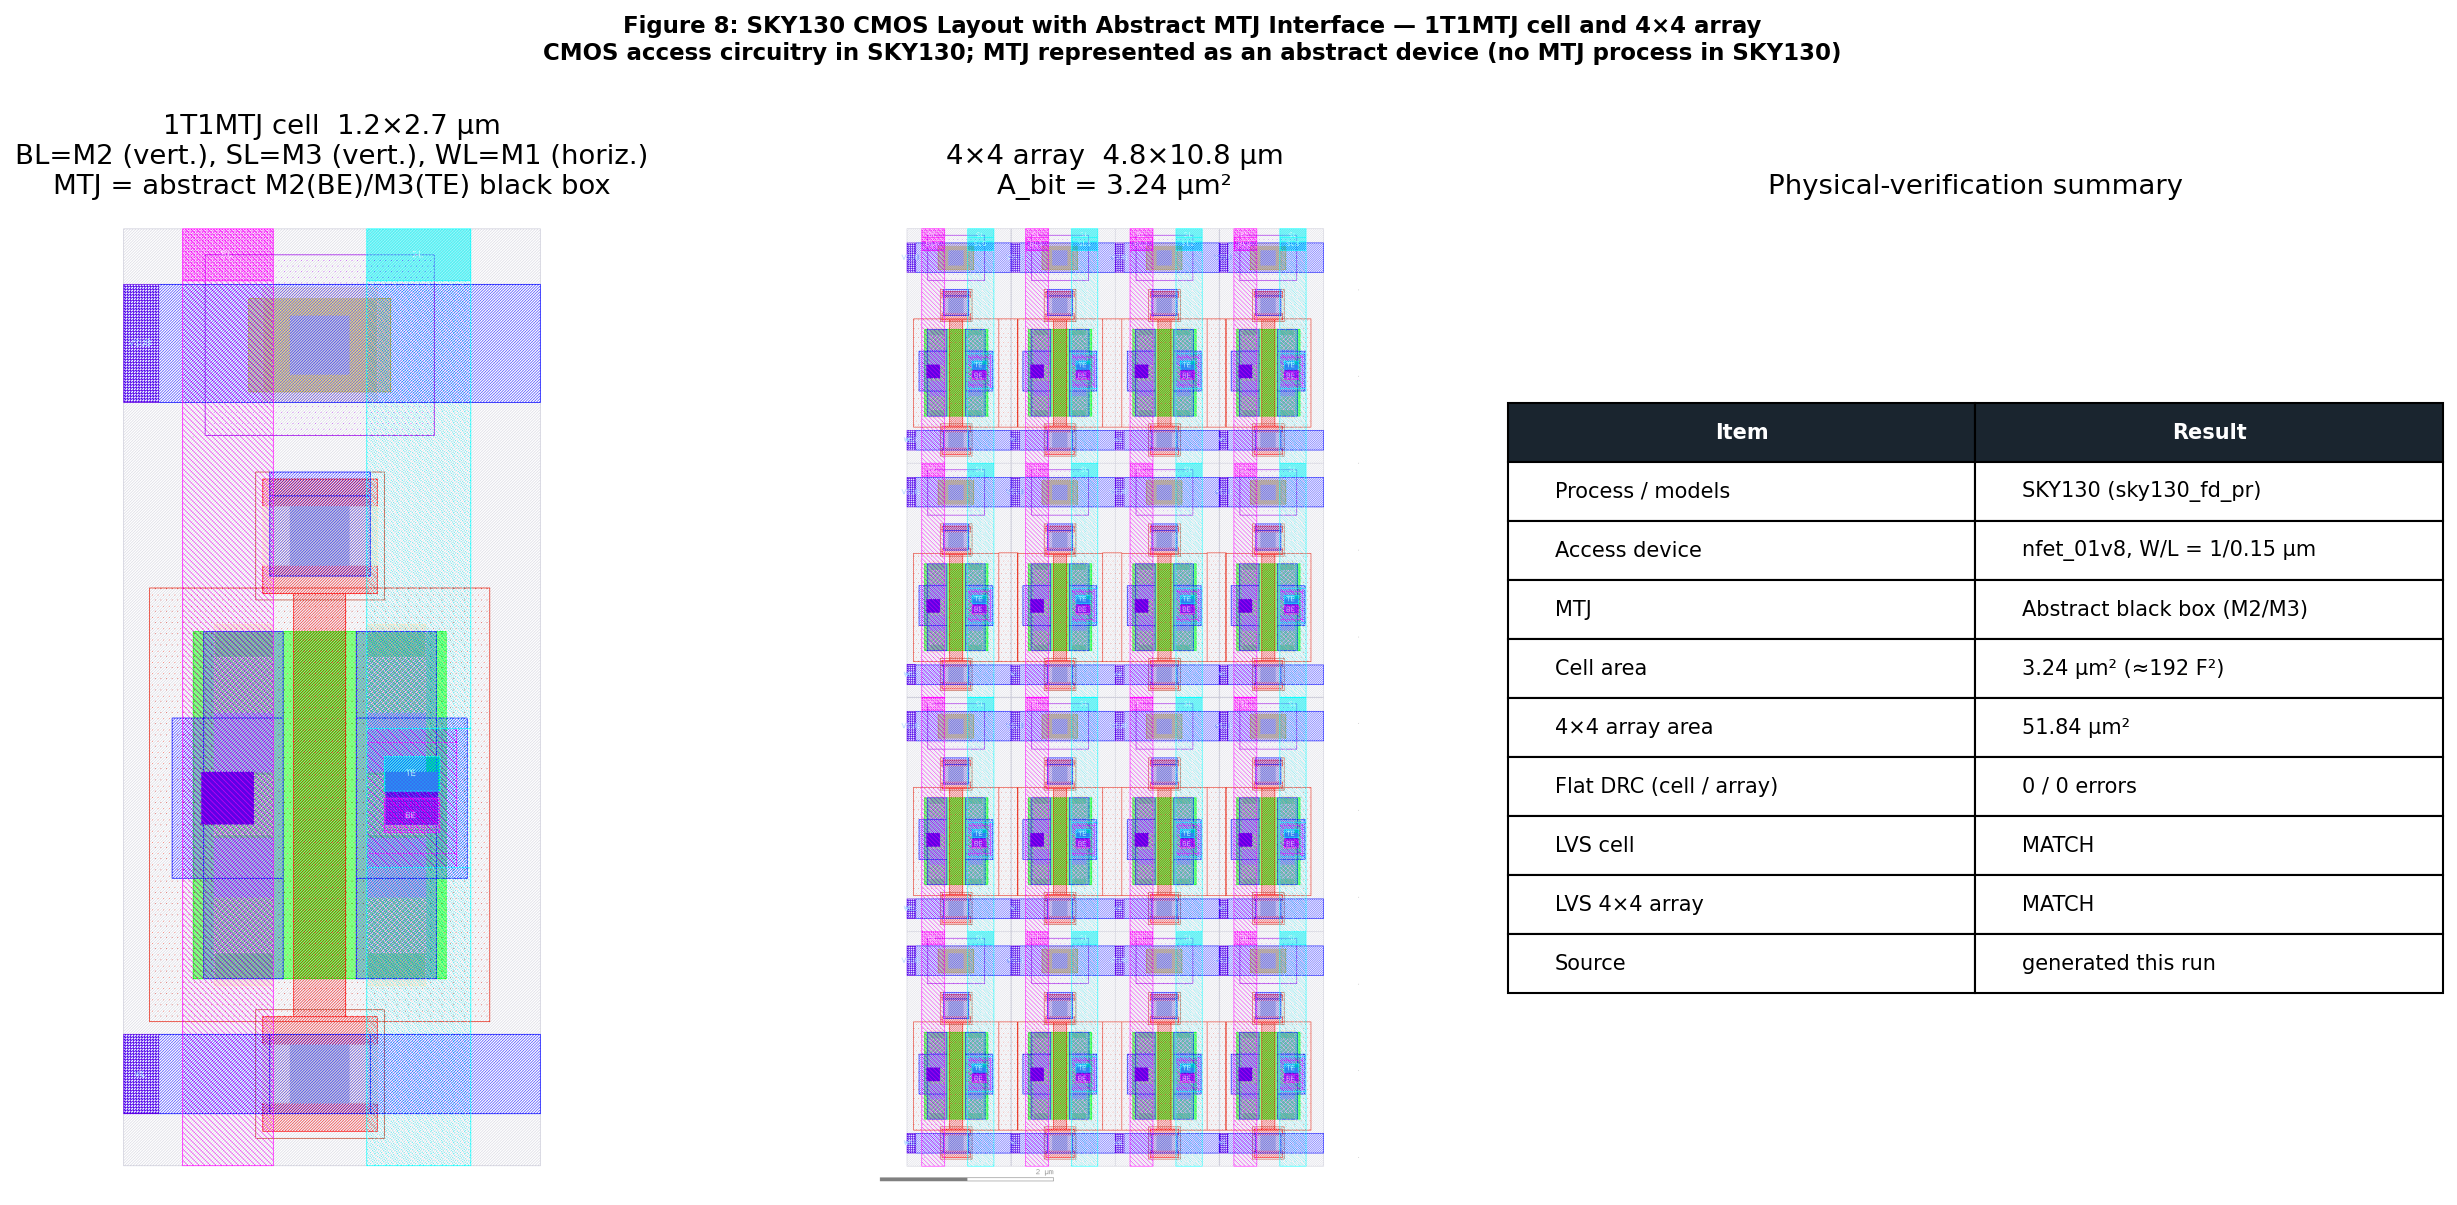

✓ Figure 8 saved (layout, DRC, LVS)


In [11]:
print("\n"+"═"*65)
print("SECTION 8 — SKY130 CMOS Layout with Abstract MTJ (DRC + LVS)")
print("═"*65)

TCL_CELL = r"""
snap internal
load mtj_abstract -silent
box 0um 0um 0.26um 0.40um ; paint metal2
box 0um 0um 0.30um 0.40um ; paint metal3
box 0.03um 0.03um 0.23um 0.37um ; paint comment
box 0.05um 0.10um 0.21um 0.20um ; label BE FreeSans 0.05um 0 0 0 c metal2
port make 1 ; port use signal ; port class inout
box 0.05um 0.22um 0.21um 0.32um ; label TE FreeSans 0.05um 0 0 0 c metal3
port make 2 ; port use signal ; port class inout
save mtj_abstract

load cell_1t1mtj -silent
box 0 0 0 0
magic::gencell sky130::sky130_fd_pr__nfet_01v8 XM1 w 1 l 0.15 nf 1 guard 0 gtc 1 gbc 1 viagate 100 full_metal 1
box -0.20um 0.05um 1.00um 0.28um ; paint metal1
box -0.06um 0.73um 0.26um 1.19um ; paint metal1
box -0.03um 0.80um 0.23um 1.12um ; paint m2contact
box -0.03um -0.10um 0.23um 2.60um ; paint metal2
box 0.47um 0.73um 0.79um 1.19um ; paint metal1
box 0.50um 0.80um 0.76um 1.12um ; paint m2contact
box 0.22um 1.60um 0.51um 1.90um ; paint metal1
getcell mtj_abstract
select cell mtj_abstract_0
move to 0.50um 0.76um
select clear
box 0.50um -0.10um 0.80um 2.60um ; paint metal3
box 0.16um 2.13um 0.57um 2.40um ; paint psubdiff
box 0.28um 2.18um 0.45um 2.35um ; paint psubdiffcont
box 0.20um 2.10um 0.53um 2.43um ; paint locali
box 0.28um 2.18um 0.45um 2.35um ; paint viali
box -0.20um 2.10um 1.00um 2.44um ; paint metal1
box -0.20um 0.05um -0.10um 0.28um ; label WL FreeSans 0.1um 0 0 0 c metal1
port make 1
box -0.03um 2.45um 0.23um 2.60um ; label BL FreeSans 0.1um 0 0 0 c metal2
port make 2
box 0.50um 2.45um 0.80um 2.60um ; label SL FreeSans 0.1um 0 0 0 c metal3
port make 3
box -0.20um 2.10um -0.10um 2.44um ; label VSUB FreeSans 0.1um 0 0 0 c metal1
port make 4
box -0.20um -0.10um 1.00um 2.60um
property FIXED_BBOX [box values]
writeall force
quit -noprompt
"""

TCL_ARRAY = r"""
load array_4x4 -silent
box 0 0 0 0
getcell cell_1t1mtj
select cell cell_1t1mtj_0
move to -0.2um -0.1um
array 0 3 0 3
select clear
for {set i 0} {$i < 4} {incr i} {
  set y [expr {$i*2.7}]
  box -0.20um [expr {$y+0.05}]um -0.10um [expr {$y+0.28}]um
  paint metal1 ; label WL$i FreeSans 0.1um 0 0 0 c metal1 ; port make
  box -0.20um [expr {$y+2.10}]um -0.10um [expr {$y+2.44}]um
  paint metal1 ; label VSUB FreeSans 0.1um 0 0 0 c metal1 ; port make
}
for {set j 0} {$j < 4} {incr j} {
  set x [expr {$j*1.2}]
  box [expr {$x-0.03}]um 10.45um [expr {$x+0.23}]um 10.60um
  paint metal2 ; label BL$j FreeSans 0.1um 0 0 0 c metal2 ; port make
  box [expr {$x+0.50}]um 10.45um [expr {$x+0.80}]um 10.60um
  paint metal3 ; label SL$j FreeSans 0.1um 0 0 0 c metal3 ; port make
}
save array_4x4
foreach c {cell_1t1mtj array_4x4} {
  load $c
  select top cell
  puts "SIZE $c [box size]"
  gds write $c.gds
  flatten ${c}_flat
  load ${c}_flat
  select top cell
  drc style drc(full)
  drc check
  drc catchup
  puts "DRC $c [drc listall count total]"
  puts "DRCWHY $c [drc listall why]"
}
quit -noprompt
"""

TCL_EXTRACT = r"""
load mtj_abstract
property LEFview true
foreach c {cell_1t1mtj array_4x4} {
  load $c
  select top cell
  extract path ext
  extract all
  ext2spice lvs
  ext2spice -p ext -o ${c}_lvs.spice
  ext2spice init
  ext2spice cthresh 0
  ext2spice hierarchy off
  ext2spice format ngspice
  ext2spice -p ext -o ${c}_pex.spice
}
quit -noprompt
"""

def run_magic(tcl, name):
    path = f"{LAY}/{name}.tcl"
    open(path, "w").write(tcl)
    env = dict(os.environ, PDK_ROOT=PDK_ROOT)
    r = subprocess.run(["magic", "-dnull", "-noconsole", "-rcfile", f"{LAY}/sky130A.magicrc", path],
                       cwd=LAY, env=env, capture_output=True, text=True, timeout=600)
    return r.stdout + r.stderr

def sch_netlists():
    cell = (".subckt mtj_abstract BE TE\n.ends\n"
            ".subckt cell_1t1mtj WL BL SL VSUB\n"
            "XM1 BL WL int VSUB sky130_fd_pr__nfet_01v8 W=1 L=0.15 nf=1\n"
            "XMTJ int SL mtj_abstract\n.ends\n")
    pins = " ".join([f"WL{i}" for i in range(4)] + ["VSUB"] +
                    [f"BL{j} SL{j}" for j in range(4)])
    arr = cell + f".subckt array_4x4 {pins}\n"
    for i in range(4):
        for j in range(4):
            arr += f"X{i}_{j} WL{i} BL{j} SL{j} VSUB cell_1t1mtj\n"
    arr += ".ends\n"
    open(f"{LAY}/cell_1t1mtj_sch.spice", "w").write(cell)
    open(f"{LAY}/array_4x4_sch.spice", "w").write(arr)

def run_lvs(c):
    out = f"{LAY}/lvs_{c}.out"
    subprocess.run([NETGEN, "-batch", "lvs", f"{LAY}/{c}_lvs.spice {c}", f"{LAY}/{c}_sch.spice {c}",
                    f"{PDK}/libs.tech/netgen/sky130A_setup.tcl", out, "-blackbox"],
                   cwd=LAY, capture_output=True, text=True, timeout=600)
    txt = open(out).read() if os.path.exists(out) else ""
    tail = txt.strip().splitlines()[-1] if txt.strip() else "no report"
    ok = ("Circuits match uniquely" in tail) and ("do not match" not in txt.split("Subcircuit summary")[-1])
    return ok, tail

layout_res = {}
LAYOUT_SRC = None
if LAYOUT_OK:
    shutil.copy(f"{PDK}/libs.tech/magic/sky130A.magicrc", f"{LAY}/sky130A.magicrc")
    for f in os.listdir(LAY):
        if f.endswith((".mag", ".ext", ".gds")): os.remove(f"{LAY}/{f}")
    log_c = run_magic(TCL_CELL, "build_cell")
    log_a = run_magic(TCL_ARRAY, "build_array_drc")
    for c in ["cell_1t1mtj", "array_4x4"]:
        sz  = re.search(rf"SIZE {c} (\d+) (\d+)", log_a)
        drc = re.search(rf"DRC {c} (\d+)", log_a)
        layout_res[c] = dict(w_um=int(sz.group(1))*0.005, h_um=int(sz.group(2))*0.005,
                             drc=int(drc.group(1)) if drc else -1)
    run_magic(TCL_EXTRACT, "extract")
    sch_netlists()
    for c in ["cell_1t1mtj", "array_4x4"]:
        layout_res[c]["lvs_ok"], layout_res[c]["lvs_msg"] = run_lvs(c)

    LAYOUT_SRC = f"generated in this run (Magic {'.'.join(map(str, MAGIC_V))} + Netgen)"
elif restore_embedded_layout():
    layout_res = {k: dict(v) for k, v in EMB_LAYOUT_RES.items()}
    LAYOUT_SRC = "EMBEDDED reference results (Magic 8.3.684 + Netgen, same flow) — layout tools unavailable in this runtime"
if LAYOUT_SRC:
    print(f"  Layout source: {LAYOUT_SRC}")
    A_cell = layout_res["cell_1t1mtj"]["w_um"] * layout_res["cell_1t1mtj"]["h_um"]
    A_arr  = layout_res["array_4x4"]["w_um"]  * layout_res["array_4x4"]["h_um"]
    F = 0.13
    print(f"  Access device: sky130_fd_pr__nfet_01v8 W/L=1/0.15 µm (Magic device generator)")
    print(f"  {'Layout':<14}|{'W×H (µm)':>14}|{'Area (µm²)':>11}|{'Flat DRC':>9}|  LVS")
    print("  "+"-"*62)
    for c, A in [("cell_1t1mtj", A_cell), ("array_4x4", A_arr)]:
        r = layout_res[c]
        print(f"  {c:<14}|{r['w_um']:>6.2f} × {r['h_um']:<5.2f}|{A:>11.2f}|{r['drc']:>9}|  "
              f"{'MATCH' if r['lvs_ok'] else 'FAIL'} ({r['lvs_msg']})")
    print(f"\n  A_cell = {A_cell:.2f} µm²  (≈ {A_cell/F**2:.0f} F², F = 130 nm) — unoptimized research cell")
    print(f"  A_4×4  = {A_arr:.2f} µm²  →  A_bit = {A_arr/16:.2f} µm² (cells abut; no peripheral circuits)")
    print("  MTJ = abstract black box (metal2 BE / metal3 TE); footprint is a placeholder.")

    # ── Render GDS with the SKY130 KLayout layer properties ──
    RENDER_OK = True
    try:
        import klayout.lay as klay
    except Exception:
        RENDER_OK = False
    def render(gds, png, w, h):
        v = klay.LayoutView()
        v.load_layout(gds, True)
        v.load_layer_props(f"{PDK}/libs.tech/klayout/tech/sky130A.lyp")
        v.set_config("background-color", "#ffffff")
        v.max_hier(); v.zoom_fit()
        v.save_image(png, w, h)
    try:
        if not RENDER_OK: raise RuntimeError("klayout not importable")
        render(f"{LAY}/cell_1t1mtj.gds", f"{LAY}/cell.png", 700, 1400)
        render(f"{LAY}/array_4x4.gds",  f"{LAY}/array.png", 900, 1800)
    except Exception as e:
        RENDER_OK = False; print(f"  GDS rendering unavailable ({e}); pip install klayout to view")

    fig, axes = plt.subplots(1, 3, figsize=(17, 8), gridspec_kw={'width_ratios':[1, 1.1, 1.2]})
    for ax, png in [(axes[0], "cell.png"), (axes[1], "array.png")]:
        if RENDER_OK: ax.imshow(plt.imread(f"{LAY}/{png}"))
        else: ax.text(0.5, 0.5, "GDS render unavailable\n(pip install klayout)", ha='center', va='center')
    axes[0].axis('off')
    axes[0].set_title(f"1T1MTJ cell  {layout_res['cell_1t1mtj']['w_um']:.1f}×{layout_res['cell_1t1mtj']['h_um']:.1f} µm\n"
                      "BL=M2 (vert.), SL=M3 (vert.), WL=M1 (horiz.)\nMTJ = abstract M2(BE)/M3(TE) black box")
    axes[1].axis('off')
    axes[1].set_title(f"4×4 array  {layout_res['array_4x4']['w_um']:.1f}×{layout_res['array_4x4']['h_um']:.1f} µm\n"
                      f"A_bit = {A_arr/16:.2f} µm²")
    axes[2].axis('off')
    rows = [["Process / models", "SKY130 (sky130_fd_pr)"],
            ["Access device", "nfet_01v8, W/L = 1/0.15 µm"],
            ["MTJ", "Abstract black box (M2/M3)"],
            ["Cell area", f"{A_cell:.2f} µm² (≈{A_cell/F**2:.0f} F²)"],
            ["4×4 array area", f"{A_arr:.2f} µm²"],
            ["Flat DRC (cell / array)", f"{layout_res['cell_1t1mtj']['drc']} / {layout_res['array_4x4']['drc']} errors"],
            ["LVS cell", "MATCH" if layout_res['cell_1t1mtj']['lvs_ok'] else "FAIL"],
            ["LVS 4×4 array", "MATCH" if layout_res['array_4x4']['lvs_ok'] else "FAIL"],
            ["Source", "generated this run" if LAYOUT_OK else "embedded reference"]]
    tb = axes[2].table(cellText=rows, colLabels=["Item", "Result"], cellLoc='left', loc='center', bbox=[0, 0.2, 1, 0.6])
    tb.auto_set_font_size(False); tb.set_fontsize(10)
    for j in range(2): tb[0, j].set_facecolor('#1a252f'); tb[0, j].set_text_props(color='white', fontweight='bold')
    axes[2].set_title("Physical-verification summary")
    plt.suptitle("Figure 8: SKY130 CMOS Layout with Abstract MTJ Interface — 1T1MTJ cell and 4×4 array\n"
                 "CMOS access circuitry in SKY130; MTJ represented as an abstract device (no MTJ process in SKY130)",
                 fontsize=11, fontweight='bold', y=1.0)
    plt.tight_layout()
    plt.savefig(f"{FIG}/fig8_layout.png", dpi=150, bbox_inches='tight')
    plt.show()
    pd.DataFrame([dict(layout=k, **v) for k, v in layout_res.items()]).to_csv(f"{RES}/layout_verification.csv", index=False)
    print("✓ Figure 8 saved (layout, DRC, LVS)")
else:
    print("  Layout flow skipped (needs official PDK + Magic ≥ 8.3.411 + Netgen).")


## Section 9 — PARASITIC EXTRACTION + POST-LAYOUT SIMULATION

Capacitance extraction (Magic, flat, `cthresh 0`; no wire-resistance extraction). For simulation the black-box MTJ is replaced by the same fixed behavioral resistor used in Section 3 (R_P or R_AP) between the extracted BE and SL nodes.

Two uses:
1. **Pre- vs post-layout** I_BL and E_pulse of the single cell (same official SKY130 model in both).
2. **Replace assumptions**: extracted C_WL / C_BL feed the Section 7 energy estimate in place of the assumed 10 fF / 5 fF driver and sense capacitances.



═════════════════════════════════════════════════════════════════
SECTION 9 — PEX + Post-Layout Simulation
═════════════════════════════════════════════════════════════════
Extracted total net capacitance (to substrate + coupling):
  cell  WL                     0.504 fF
  cell  BL                     0.620 fF
  cell  SL                     0.363 fF
  cell  mtj_abstract_0_BE      0.331 fF
  4×4   WL0                    1.872 fF
  4×4   BL0                    2.780 fF
  4×4   SL0                    2.322 fF
  per-cell increment: C_BL ≈ 0.695 fF/row, C_WL ≈ 0.468 fF/column

Pre- vs post-layout (single cell, 5 ns reference WL pulse, official sky130_fd_pr__nfet_01v8 (tt), W/L = 1/0.15 µm):
  state|  I_on pre| I_on post|     ΔI|  E_BL pre| E_BL post|     ΔE| E_WL post
  P    |  105.52µA|  105.52µA| -0.00%|   934.1fJ|   934.1fJ|  0.01%|    4.88fJ
  AP   |   57.85µA|   57.85µA| -0.00%|   511.7fJ|   511.9fJ|  0.03%|    4.71fJ

System-level estimate with EXTRACTED C (replaces assumed 10 fF / 5

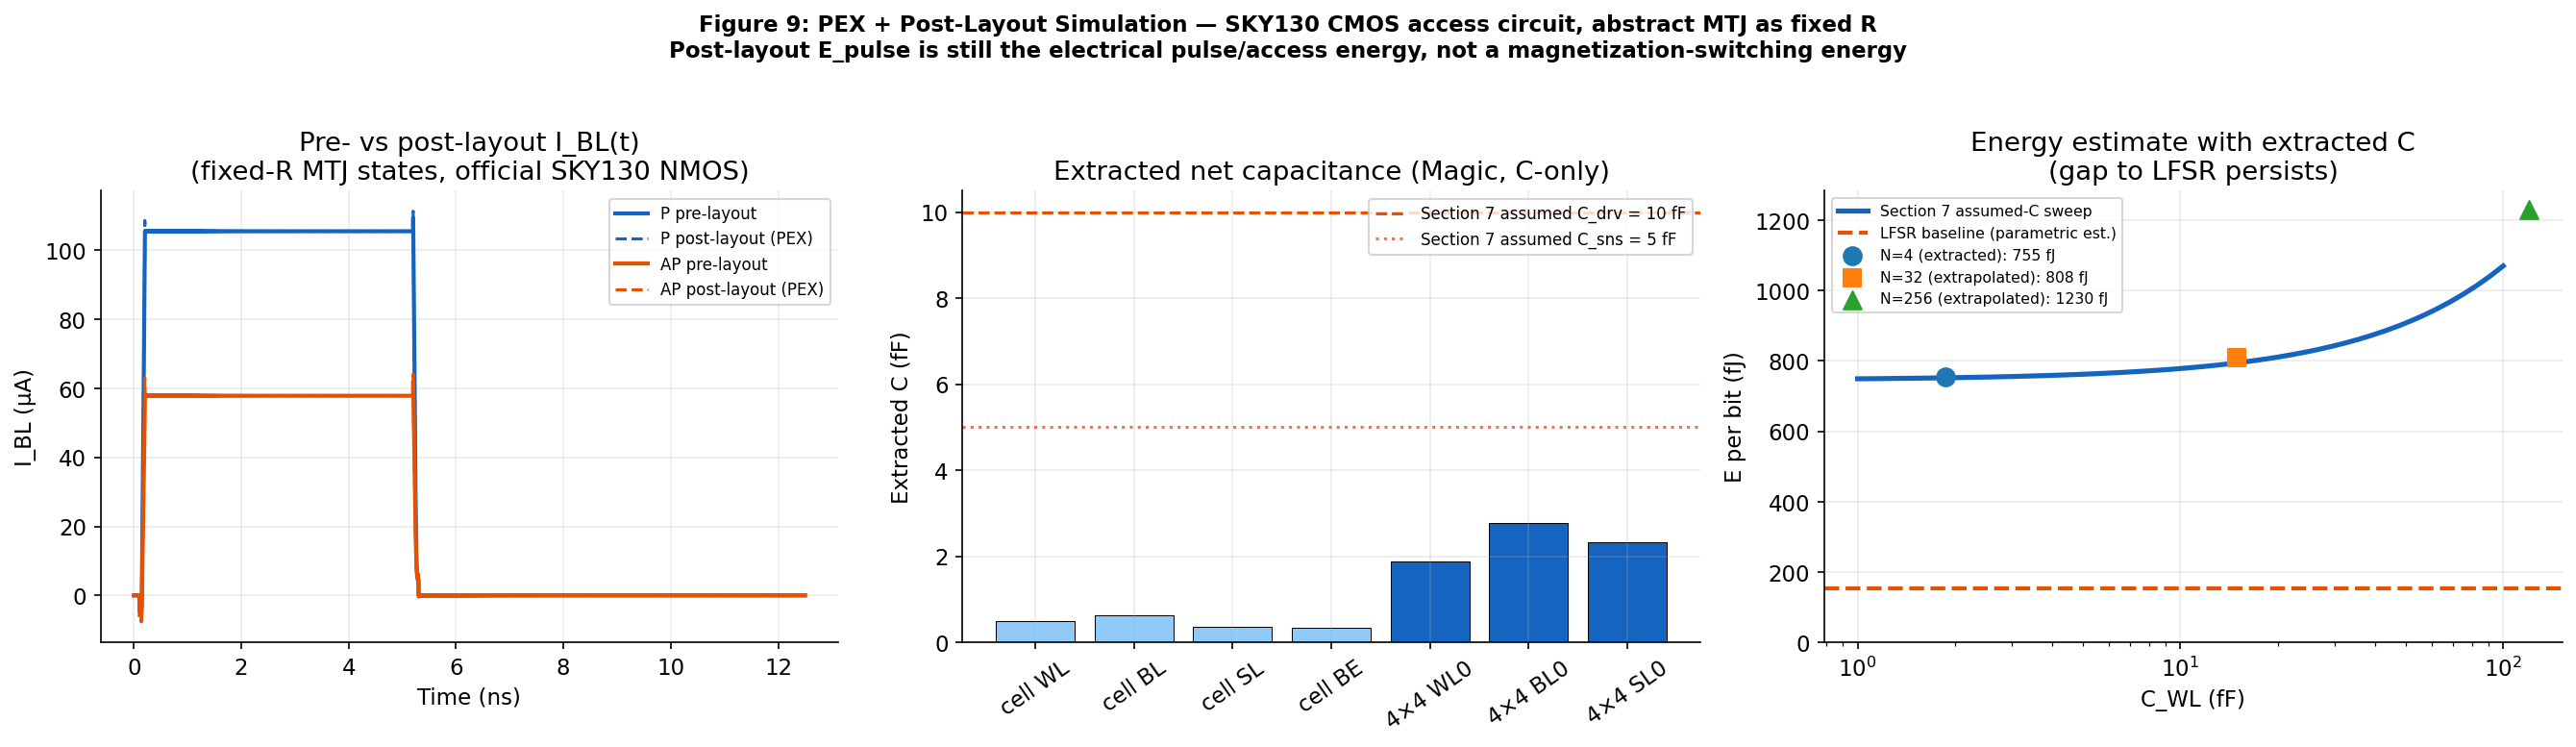

✓ Figure 9 saved (PEX, pre/post-layout)


In [12]:
print("\n"+"═"*65)
print("SECTION 9 — PEX + Post-Layout Simulation")
print("═"*65)

def clean_nodes(txt):
    """Make Magic hierarchical node names ngspice-safe: cell_1t1mtj_0[1|2]/x → cell_1t1mtj_0_1_2_x."""
    return re.sub(r"[\[\]|/]", "_", txt)

def load_pex(c):
    lines = open(f"{LAY}/{c}_pex.spice").read().splitlines()
    return [clean_nodes(l) for l in lines if l.strip() and not l.startswith("*") and l.strip().lower() != ".end"]

def net_caps(pex_lines):
    caps = {}
    for l in pex_lines:
        if l.startswith("C"):
            _, a, b, v = l.split()[:4]
            f = float(v.rstrip("fF")) * 1e-15
            for n in (a, b): caps[n] = caps.get(n, 0.0) + f
    return caps

def tran_deck(body, sources, stop_ns, name, probes):
    deck = (f"* {name}\n" + MODEL_HDR + "\n".join(body) + "\n" + sources +
            f".tran 0.01n {stop_ns}n\n.control\nrun\n"
            f"wrdata {SPC}/{name}.txt {' '.join(probes)}\nquit\n.endc\n.end\n")
    fn = f"{SPC}/{name}.spice"; open(fn, "w").write(deck)
    if os.path.exists(f"{SPC}/{name}.txt"): os.remove(f"{SPC}/{name}.txt")
    run_ngspice(fn, SPC, expect=f"{SPC}/{name}.txt")
    d = np.loadtxt(f"{SPC}/{name}.txt")
    return d[:, 0], [d[:, 2*k+1] for k in range(len(probes))]

def be_net(pex_lines):
    """MTJ bottom-electrode net = the NMOS diffusion terminal that is not BL (robust to Magic naming)."""
    for l in pex_lines:
        tok = l.split()
        if tok and tok[0].upper().startswith("X") and "nfet" in l:
            cand = [n for n in (tok[1], tok[3]) if n != "BL"]
            if cand: return cand[0]
    raise RuntimeError("Could not identify the MTJ bottom-electrode net in the PEX netlist")

PW_POST = 5.0
def cell_sim(R, post):
    if post:
        _pex = load_pex("cell_1t1mtj"); body = _pex + [f"Rmtj {be_net(_pex)} SL {R}"]
    else:
        body = [NMOS_FMT.format(d="BL", g="WL", s="be", b="VSUB").strip(), f"Rmtj be SL {R}"]
    src = (f"Vbl BL 0 DC {VDD}\nVsl SL 0 0\nVsub VSUB 0 0\n"
           f"Vwl WL 0 PULSE(0 {VDD} 0.1n 0.1n 0.1n {PW_POST}n 100n)\n")
    t, (IBL, IWL) = tran_deck(body, src, PW_POST*2.5, f"cell_{'post' if post else 'pre'}_{int(R)}", ["I(Vbl)", "I(Vwl)"])
    IBL, IWL = -IBL, -IWL
    win = (t >= 0.1e-9) & (t <= (PW_POST + 0.1)*1e-9)   # same window as Section 3
    return dict(t=t, IBL=IBL, E_BL=trapezoid(VDD*IBL[win], t[win]),
                E_WL=trapezoid(VDD*np.clip(IWL, 0, None), t),   # energy delivered by the WL driver
                I_on=np.median(IBL[(t > 1e-9) & (t < PW_POST*1e-9)]))

if LAYOUT_SRC and USE_SKY130:
    pex_cell = load_pex("cell_1t1mtj"); pex_arr = load_pex("array_4x4")
    capc, capa = net_caps(pex_cell), net_caps(pex_arr)
    C_cell = {k: capc.get(k, 0) for k in ["WL", "BL", "SL", be_net(pex_cell)]}
    C_arr  = {k: capa.get(k, 0) for k in ["WL0", "BL0", "SL0"]}
    print("Extracted total net capacitance (to substrate + coupling):")
    for k, v in C_cell.items(): print(f"  cell  {k:<20} {v*1e15:7.3f} fF")
    for k, v in C_arr.items():  print(f"  4×4   {k:<20} {v*1e15:7.3f} fF")
    Cbl_per_cell = C_arr["BL0"] / 4
    Cwl_per_cell = C_arr["WL0"] / 4
    print(f"  per-cell increment: C_BL ≈ {Cbl_per_cell*1e15:.3f} fF/row, C_WL ≈ {Cwl_per_cell*1e15:.3f} fF/column")

    post = {}
    for lbl, R in [("P", R_P), ("AP", R_AP)]:
        post[lbl] = (cell_sim(R, False), cell_sim(R, True))
    print(f"\nPre- vs post-layout (single cell, {PW_POST:.0f} ns reference WL pulse, {NMOS_SRC}):")
    print(f"  {'state':<5}|{'I_on pre':>10}|{'I_on post':>10}|{'ΔI':>7}|{'E_BL pre':>10}|{'E_BL post':>10}|{'ΔE':>7}|{'E_WL post':>10}")
    for lbl in ["P", "AP"]:
        a, b = post[lbl]
        print(f"  {lbl:<5}|{a['I_on']*1e6:>8.2f}µA|{b['I_on']*1e6:>8.2f}µA|{(b['I_on']/a['I_on']-1)*100:>6.2f}%|"
              f"{a['E_BL']*1e15:>8.1f}fJ|{b['E_BL']*1e15:>8.1f}fJ|{(b['E_BL']/a['E_BL']-1)*100:>6.2f}%|{b['E_WL']*1e15:>8.2f}fJ")
    E_pulse_post = (post["P"][1]["E_BL"] + post["AP"][1]["E_BL"]) / 2

    # Energy estimate with EXTRACTED capacitances (4×4 array: one WL row, one BL column)
    E_ext_4x4 = E_mtj_total(C_arr["WL0"], C_arr["BL0"], E_p=E_pulse_post)
    ext_rows = []
    for N in [4, 32, 256]:
        Cwl, Cbl = Cwl_per_cell*N, Cbl_per_cell*N          # linear extrapolation (labelled)
        ext_rows.append(dict(N=N, C_WL_fF=Cwl*1e15, C_BL_fF=Cbl*1e15,
                             E_total_fJ=E_mtj_total(Cwl, Cbl, E_p=E_pulse_post)*1e15))
    df_ext = pd.DataFrame(ext_rows); df_ext.to_csv(f"{RES}/energy_extracted_C.csv", index=False)
    print(f"\nSystem-level estimate with EXTRACTED C (replaces assumed 10 fF / 5 fF):")
    print(df_ext.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
    print(f"  N=4 is extracted; N=32/256 are linear extrapolations of the per-cell increment.")
    print(f"  4×4 extracted: E_MTJ = {E_ext_4x4*1e15:.1f} fJ vs LFSR baseline (parametric) {E_LFSR_ref*1e15:.1f} fJ "
          f"→ {E_ext_4x4/E_LFSR_ref:.1f}× — the gap remains; it is set by E_pulse, not by wiring C.")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for lbl, c in [("P", '#1565C0'), ("AP", '#E65100')]:
        a, b = post[lbl]
        axes[0].plot(a['t']*1e9, a['IBL']*1e6, color=c, lw=2, label=f'{lbl} pre-layout')
        axes[0].plot(b['t']*1e9, b['IBL']*1e6, color=c, lw=1.5, ls='--', label=f'{lbl} post-layout (PEX)')
    axes[0].set(xlabel="Time (ns)", ylabel="I_BL (µA)", title="Pre- vs post-layout I_BL(t)\n(fixed-R MTJ states, official SKY130 NMOS)")
    axes[0].legend(fontsize=8)

    names = ["cell WL", "cell BL", "cell SL", "cell BE", "4×4 WL0", "4×4 BL0", "4×4 SL0"]
    vals = [C_cell["WL"], C_cell["BL"], C_cell["SL"], C_cell["mtj_abstract_0_BE"], C_arr["WL0"], C_arr["BL0"], C_arr["SL0"]]
    axes[1].bar(names, np.array(vals)*1e15, color=['#90CAF9']*4 + ['#1565C0']*3, edgecolor='k', lw=0.5)
    axes[1].axhline(10, color='#E65100', ls='--', lw=1.5, label='Section 7 assumed C_drv = 10 fF')
    axes[1].axhline(5, color='#FF7043', ls=':', lw=1.5, label='Section 7 assumed C_sns = 5 fF')
    axes[1].set(ylabel="Extracted C (fF)", title="Extracted net capacitance (Magic, C-only)")
    axes[1].tick_params(axis='x', rotation=35); axes[1].legend(fontsize=8)

    axes[2].semilogx(C_range*1e15, E_mtj_sweep*1e15, '#1565C0', lw=2.5, label='Section 7 assumed-C sweep')
    axes[2].axhline(E_LFSR_ref*1e15, color='#E65100', ls='--', lw=2, label='LFSR baseline (parametric est.)')
    for r, mk in zip(ext_rows, ['o', 's', '^']):
        axes[2].scatter([max(r['C_WL_fF'], 1)], [r['E_total_fJ']], s=80, marker=mk, zorder=5,
                        label=f"N={r['N']} {'(extracted)' if r['N']==4 else '(extrapolated)'}: {r['E_total_fJ']:.0f} fJ")
    axes[2].set(xlabel="C_WL (fF)", ylabel="E per bit (fJ)", ylim=(0, None),
                title="Energy estimate with extracted C\n(gap to LFSR persists)")
    axes[2].legend(fontsize=7.5)
    plt.suptitle("Figure 9: PEX + Post-Layout Simulation — SKY130 CMOS access circuit, abstract MTJ as fixed R\n"
                 "Post-layout E_pulse is still the electrical pulse/access energy, not a magnetization-switching energy",
                 fontsize=11, fontweight='bold', y=1.03)
    plt.tight_layout()
    plt.savefig(f"{FIG}/fig9_postlayout.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Figure 9 saved (PEX, pre/post-layout)")
else:
    print("  Skipped (layout flow unavailable).")


## Section 10 — STATISTICAL ARRAY SCALING: 4×4 → 32×32 (statistical masks, not transistor-level)


═════════════════════════════════════════════════════════════════
SECTION 10 — Statistical Array Scaling: 4×4 → 32×32
═════════════════════════════════════════════════════════════════
4×4 statistical dropout mask (p*=0.3): density=0.188
  E[p̂]=0.30, σ_p̂=√(p(1−p)/16)=0.115 for a 16-cell mask —
  a single 4×4 density of 0.188 is 1.0σ from p* (expected).
[Statistical masks; the physical 4×4 layout + PEX is in Sections 8–9]


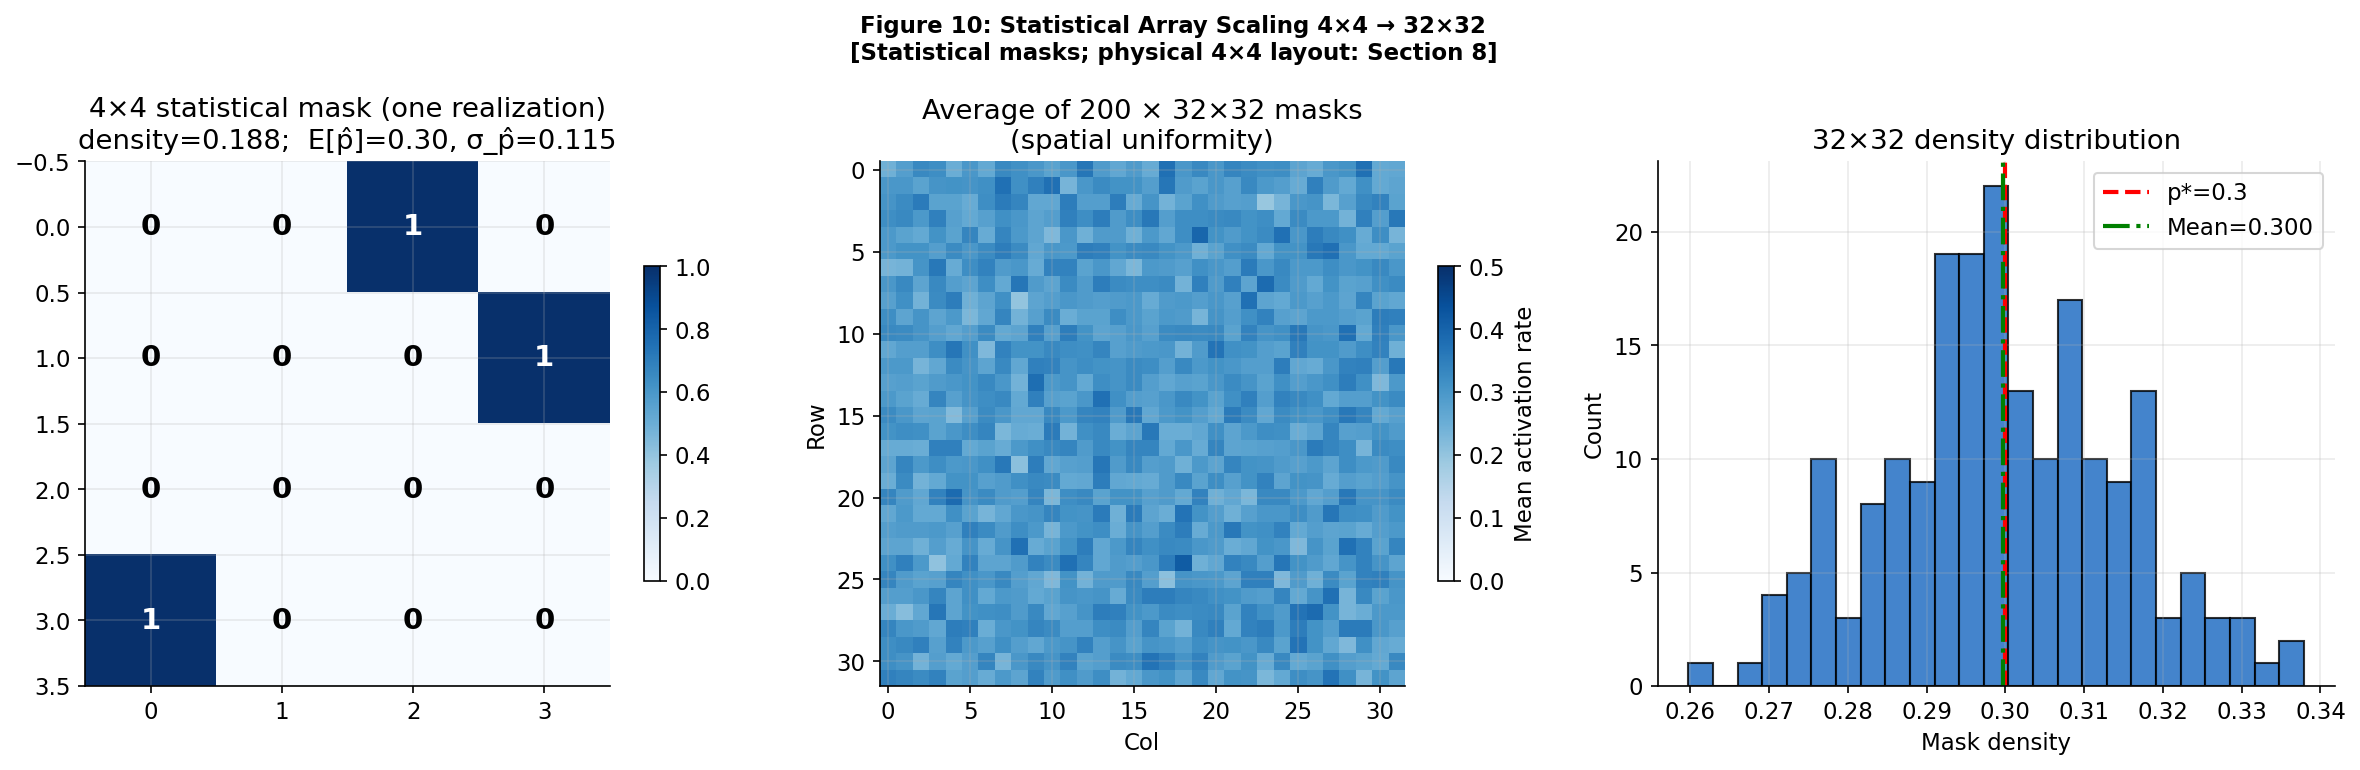

✓ Figure 8 saved


In [13]:
print("\n"+"═"*65)
print("SECTION 10 — Statistical Array Scaling: 4×4 → 32×32")
print("═"*65)

P_MASK = 0.30
rng_a  = np.random.default_rng(77)
p_eff_a = P_SW_model(I_W, pw_star(P_MASK, I_W, T_NOM), T_NOM)
mask_4x4 = (rng_a.random((4,4)) < p_eff_a).astype(int)
masks_32 = np.array([(np.random.default_rng(m).random((32,32)) < p_eff_a).astype(np.int8)
                     for m in range(200)])
print(f"4×4 statistical dropout mask (p*={P_MASK}): density={mask_4x4.mean():.3f}")
sig_16 = np.sqrt(P_MASK*(1-P_MASK)/16)
print(f"  E[p̂]={P_MASK:.2f}, σ_p̂=√(p(1−p)/16)={sig_16:.3f} for a 16-cell mask —")
print(f"  a single 4×4 density of {mask_4x4.mean():.3f} is {abs(mask_4x4.mean()-P_MASK)/sig_16:.1f}σ from p* (expected).")
print("[Statistical masks; the physical 4×4 layout + PEX is in Sections 8–9]")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
im = axes[0].imshow(mask_4x4, cmap='Blues', vmin=0, vmax=1)
for i in range(4):
    for j in range(4):
        axes[0].text(j, i, str(mask_4x4[i,j]), ha='center', va='center',
                     fontsize=14, fontweight='bold',
                     color='white' if mask_4x4[i,j] else 'black')
axes[0].set_title(f"4×4 statistical mask (one realization)\n"
                  f"density={mask_4x4.mean():.3f};  E[p̂]={P_MASK:.2f}, σ_p̂={sig_16:.3f}")
plt.colorbar(im, ax=axes[0], shrink=0.6)
im2 = axes[1].imshow(masks_32.mean(axis=0), cmap='Blues', vmin=0, vmax=0.5)
plt.colorbar(im2, ax=axes[1], shrink=0.6, label='Mean activation rate')
axes[1].set(title=f"Average of 200 × 32×32 masks\n(spatial uniformity)", xlabel="Col", ylabel="Row")
dens = masks_32.mean(axis=(1,2))
axes[2].hist(dens, bins=25, color='#1565C0', alpha=0.8, edgecolor='k', lw=0.5)
axes[2].axvline(P_MASK, color='red', ls='--', lw=2, label=f'p*={P_MASK}')
axes[2].axvline(dens.mean(), color='green', ls='-.', lw=2, label=f'Mean={dens.mean():.3f}')
axes[2].set(xlabel="Mask density", ylabel="Count", title="32×32 density distribution")
axes[2].legend()
plt.suptitle("Figure 10: Statistical Array Scaling 4×4 → 32×32\n"
             "[Statistical masks; physical 4×4 layout: Section 8]",
             fontsize=11, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{FIG}/fig10_array.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 8 saved")

## Section 11 — REAL MNIST MC DROPOUT: PER-PASS DEVICE-PARAMETER p_m + ECE + AUROC


═════════════════════════════════════════════════════════════════
SECTION 11 — Real MNIST + MC Dropout (per-pass device-parameter p_m)

Three stochastic sources:
  A: Ideal Bernoulli(0.30)                                    seed=1001
  B: Independent realization (same p=0.30, different seed)    seed=2001
  C: Device-parameter-perturbed Bernoulli (fast ensemble)     seed=3001
     Each MC pass m uses an independent realization of the global+local
     parameter model (Δ_m, I_c0,m, T_m) → p_m = P_SW(I_W, PW*_nom, …)
     → mask_m ~ Bernoulli(p_m). The PW register is fixed at the nominal
     calibration; the inverted-dropout scale stays at 1/(1−0.30) because the
     hardware does not know p_m.
     NOTE: this treats every pass as a new device/environment realization
     (ensemble sensitivity). A physical chip's Δ and I_c0 do not change between
     passes — that case is the STATIC-DEVICE experiment at the end of this section
     (20 virtual devices × 50 passes, Δ and I_c0 fixed per d

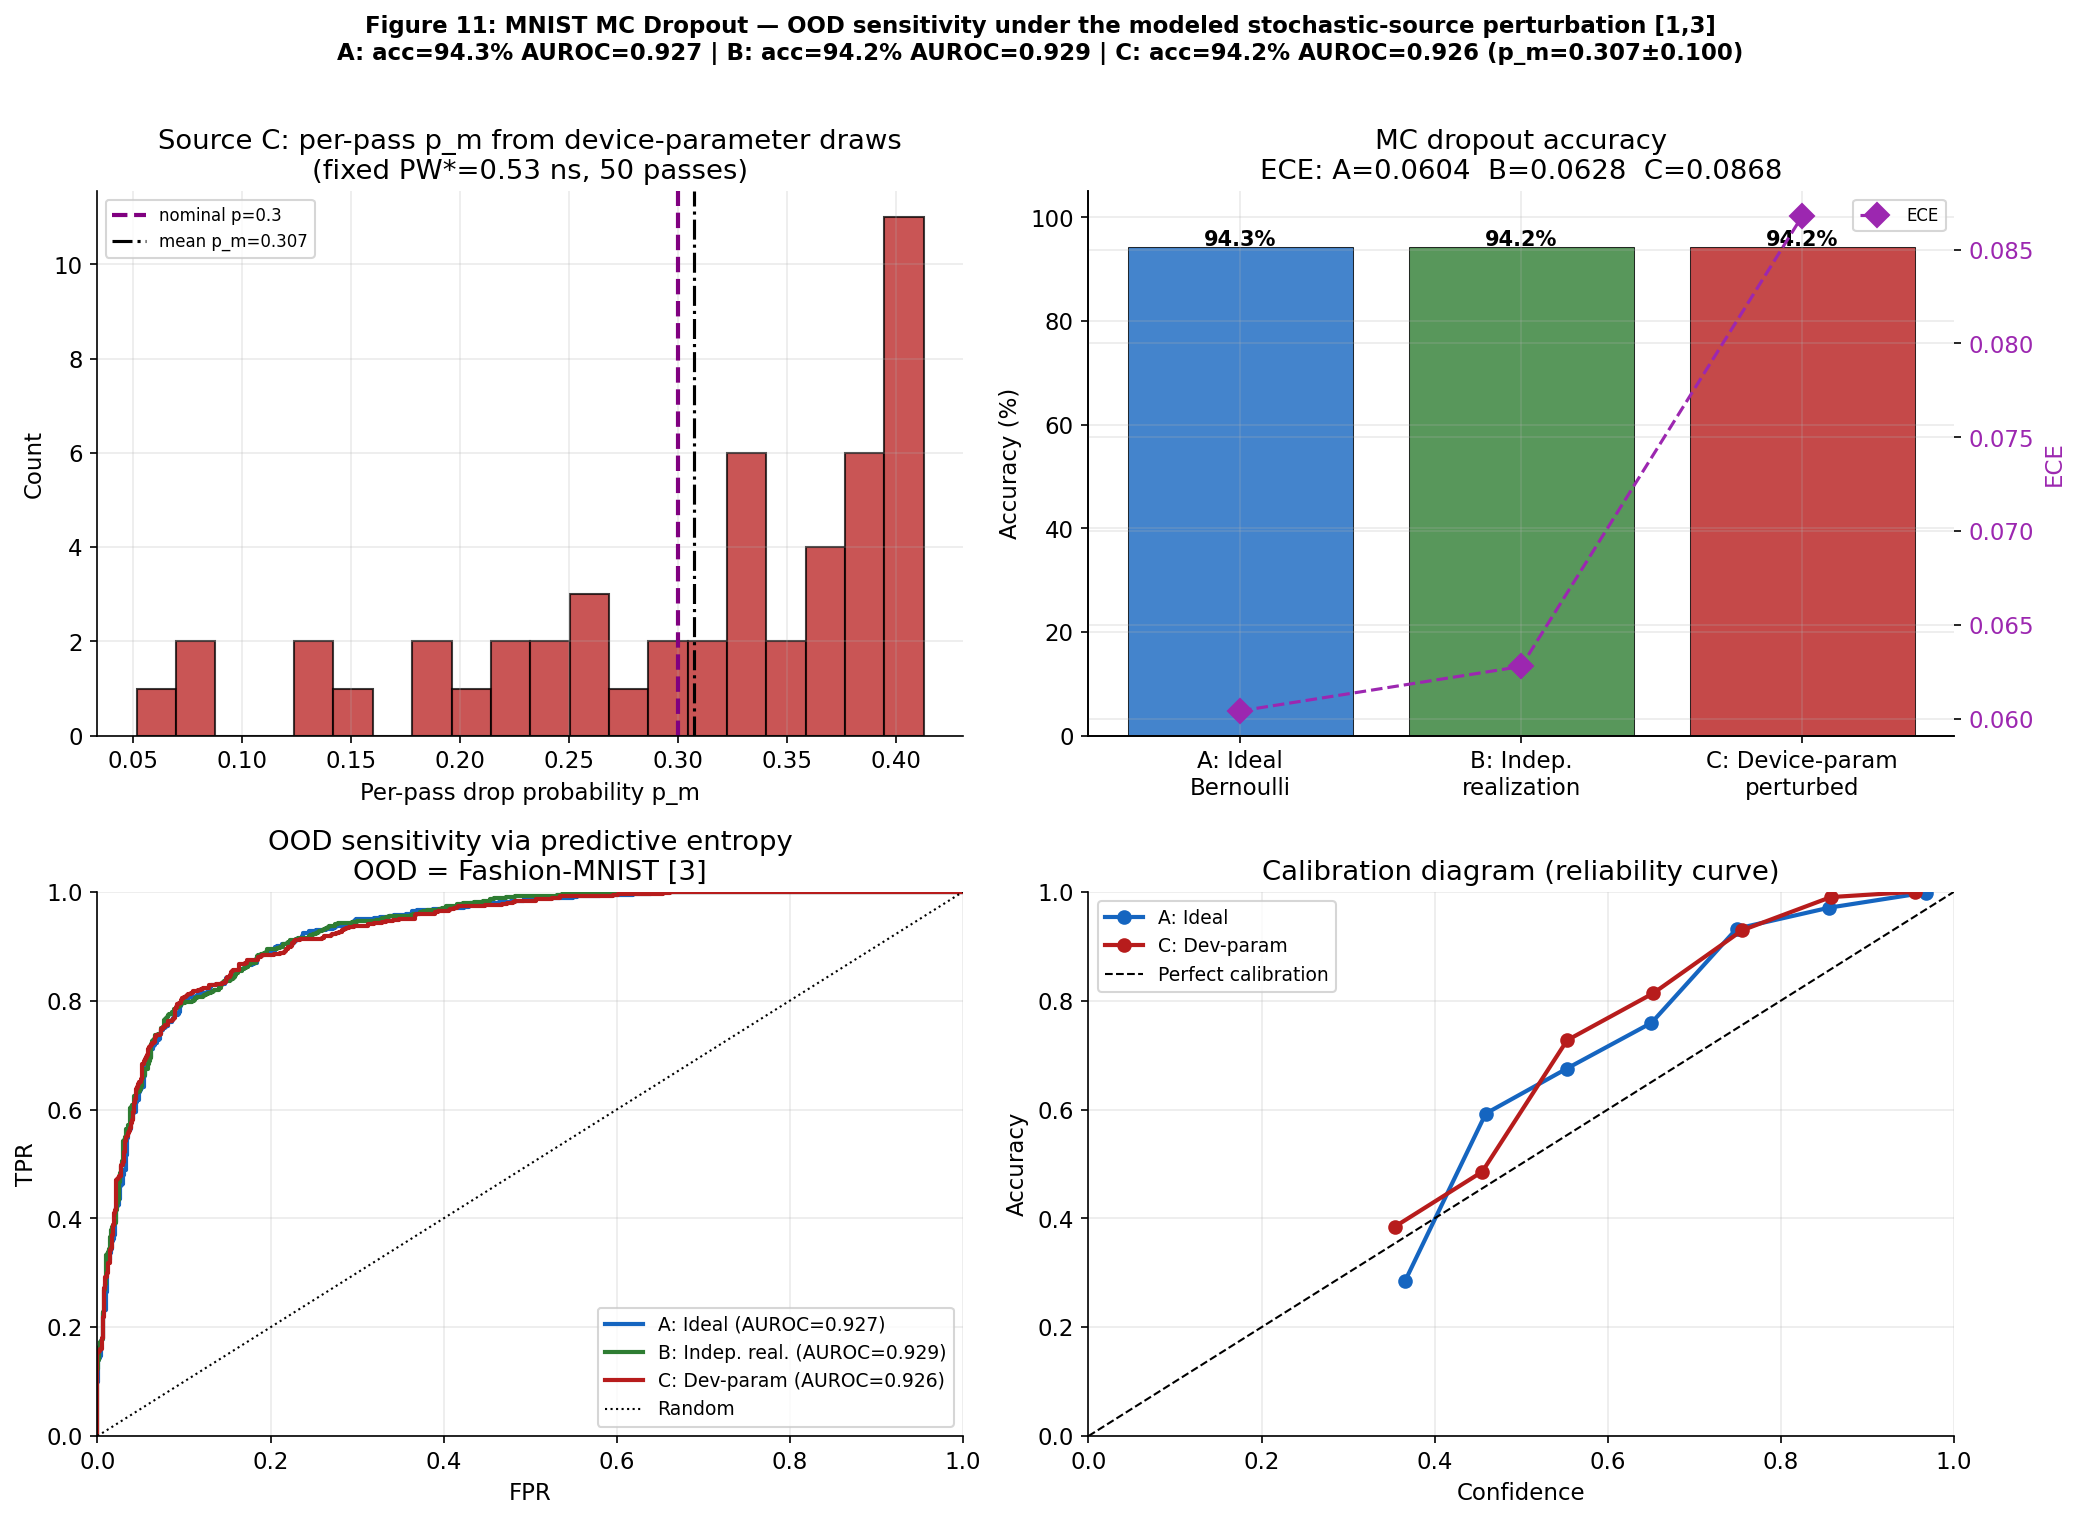


✓ Figure 11 saved (per-pass p_m, Fashion-MNIST OOD)

Static-device experiment (20 devices × 50 passes; Δ, I_c0 fixed per device):
  per-device mean p: 0.285 ± 0.117 (range 0.056–0.413); within-device σ_p ≈ 0.0004
                                   Acc (%)                 ECE               AUROC
  Ideal, 20 seeds            94.28 ± 0.20      0.0620 ± 0.0026      0.9272 ± 0.0041
  Static devices             94.27 ± 0.23      0.0812 ± 0.0554      0.9229 ± 0.0048
  ECE range across devices: 0.0117 – 0.1718


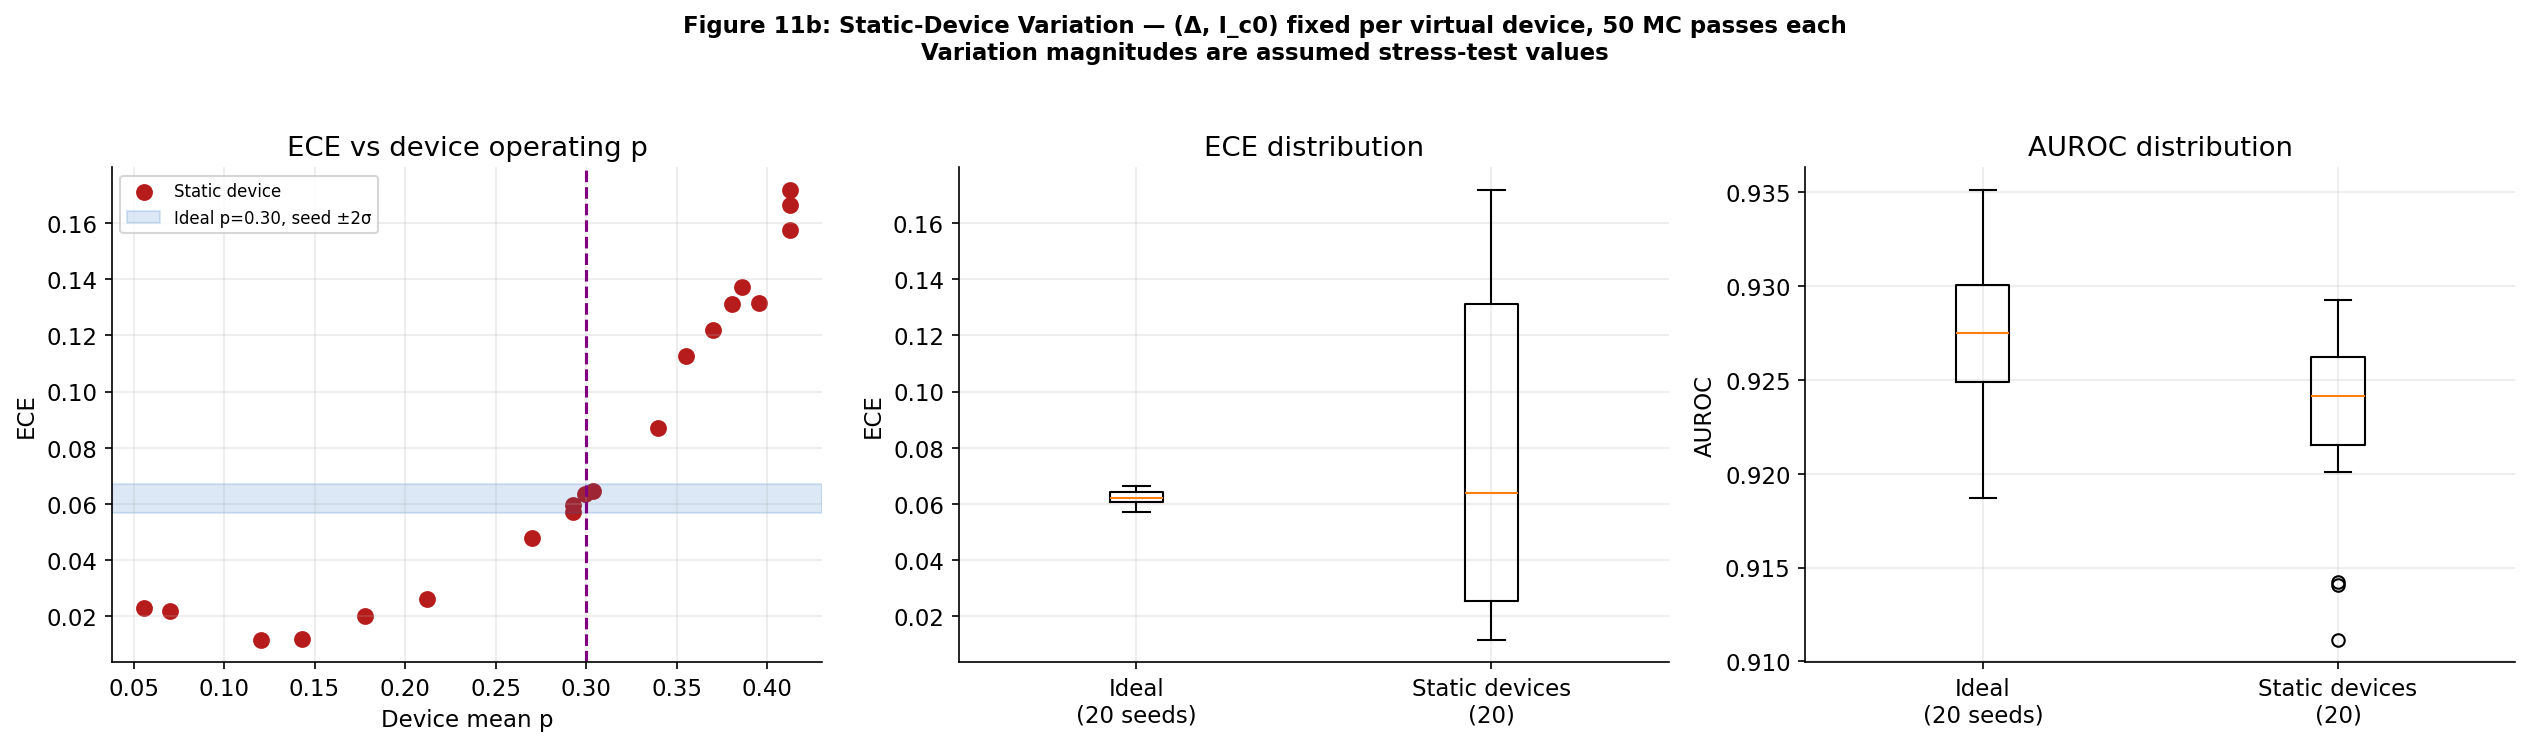

✓ Figure 11b saved (static-device experiment)


In [14]:
print("\n"+"═"*65)
print("SECTION 11 — Real MNIST + MC Dropout (per-pass device-parameter p_m)")
print("="*65)
print("""
Three stochastic sources:
  A: Ideal Bernoulli(0.30)                                    seed=1001
  B: Independent realization (same p=0.30, different seed)    seed=2001
  C: Device-parameter-perturbed Bernoulli (fast ensemble)     seed=3001
     Each MC pass m uses an independent realization of the global+local
     parameter model (Δ_m, I_c0,m, T_m) → p_m = P_SW(I_W, PW*_nom, …)
     → mask_m ~ Bernoulli(p_m). The PW register is fixed at the nominal
     calibration; the inverted-dropout scale stays at 1/(1−0.30) because the
     hardware does not know p_m.
     NOTE: this treats every pass as a new device/environment realization
     (ensemble sensitivity). A physical chip's Δ and I_c0 do not change between
     passes — that case is the STATIC-DEVICE experiment at the end of this section
     (20 virtual devices × 50 passes, Δ and I_c0 fixed per device).
""")

# ── Load MNIST: self-contained downloader ────────────────────────
def load_mnist(cache='/tmp/mnist_real_v3.npz'):
    """
    Self-contained MNIST loader. Works in Google Colab.
    Downloads from public GitHub mirror if cache not found.
    """
    if os.path.exists(cache):
        print("  (using cached MNIST)")
        d = np.load(cache)
        return d['x_train'], d['y_train'], d['x_test'], d['y_test']

    BASE = "https://github.com/golbin/TensorFlow-MNIST/raw/master/mnist/data/"
    FMNIST = "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/"
    print("  Downloading MNIST...")

    MIRRORS = [BASE, "https://storage.googleapis.com/cvdf-datasets/mnist/"]
    def fetch_idx(url, dest, n, dim):
        fname = url.rsplit("/", 1)[1]; err = None
        for base in MIRRORS:
            try:
                urllib.request.urlretrieve(base + fname, dest); err = None; break
            except Exception as e:
                err = e
        if err: raise RuntimeError(f"MNIST download failed from all mirrors: {err}")
        with gzip.open(dest, 'rb') as f:
            if dim:
                f.read(16)
                return np.frombuffer(f.read(), dtype=np.uint8).reshape(n, dim) / 255.0
            else:
                f.read(8)
                return np.frombuffer(f.read(), dtype=np.uint8)

    X_tr = fetch_idx(BASE+'train-images-idx3-ubyte.gz', '/tmp/mnist_ti.gz', 60000, 784)
    y_tr = fetch_idx(BASE+'train-labels-idx1-ubyte.gz', '/tmp/mnist_tl.gz', 60000, None)
    X_te = fetch_idx(BASE+'t10k-images-idx3-ubyte.gz',  '/tmp/mnist_ei.gz', 10000, 784)
    y_te = fetch_idx(BASE+'t10k-labels-idx1-ubyte.gz',  '/tmp/mnist_el.gz', 10000, None)
    np.savez(cache, x_train=X_tr, y_train=y_tr, x_test=X_te, y_test=y_te)
    return X_tr, y_tr, X_te, y_te

def load_fashion_mnist(cache='/tmp/fmnist_test.npz'):
    """Fashion-MNIST test set — harder OOD than uniform noise (P2-9)."""
    if os.path.exists(cache):
        d = np.load(cache); return d['X'], d['y']
    BASE = "https://github.com/zalandoresearch/fashion-mnist/raw/master/data/fashion/"
    print("  Downloading Fashion-MNIST (OOD)...")
    def fetch(url, dest, n, dim):
        urllib.request.urlretrieve(url, dest)
        with gzip.open(dest,'rb') as f:
            if dim: f.read(16); return np.frombuffer(f.read(),dtype=np.uint8).reshape(n,dim)/255.0
            else:   f.read(8);  return np.frombuffer(f.read(),dtype=np.uint8)
    X = fetch(BASE+'t10k-images-idx3-ubyte.gz','/tmp/fm_i.gz',10000,784)
    y = fetch(BASE+'t10k-labels-idx1-ubyte.gz','/tmp/fm_l.gz',10000,None)
    np.savez(cache, X=X, y=y)
    return X, y

print("Loading datasets...")
X_tr,y_tr,X_te,y_te = load_mnist()
print(f"  MNIST: train={X_tr.shape} test={X_te.shape}")

try:
    X_fmnist, y_fmnist = load_fashion_mnist()
    print(f"  Fashion-MNIST OOD: {X_fmnist.shape}")
    HAS_FMNIST = True
except Exception as e:
    print(f"  Fashion-MNIST unavailable ({e}) — using uniform noise OOD")
    X_fmnist = np.random.default_rng(77).random((2000, 784))
    HAS_FMNIST = False

# ── Train MLP (pure numpy) ────────────────────────────────────────
print("\nTraining 784→256→128→10 MLP (pure numpy, 8 epochs)...")
rng_nn = np.random.default_rng(0)
N_H1,N_H2,N_CLS = 256,128,10
def he(fi,fo): return rng_nn.normal(0, np.sqrt(2/fi), (fi,fo))
W1=he(784,N_H1);  b1=np.zeros(N_H1)
W2=he(N_H1,N_H2); b2=np.zeros(N_H2)
W3=he(N_H2,N_CLS);b3=np.zeros(N_CLS)
relu = lambda x: np.maximum(0, x)
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)
def fwd_eval(X):
    return softmax(relu(relu(X@W1+b1)@W2+b2)@W3+b3)

LR=0.05; BS=256; rng_tr=np.random.default_rng(1)
for ep in range(8):
    idx = rng_tr.permutation(len(X_tr))
    for i in range(0, len(X_tr)-BS, BS):
        xb=X_tr[idx[i:i+BS]]; yb=y_tr[idx[i:i+BS]]
        h1=relu(xb@W1+b1); m1=(rng_tr.random(h1.shape)>0.30)/(0.70); h1*=m1
        h2=relu(h1@W2+b2); m2=(rng_tr.random(h2.shape)>0.30)/(0.70); h2*=m2
        p = softmax(h2@W3+b3)
        dp=p.copy(); dp[range(BS),yb]-=1; dp/=BS
        dW3=h2.T@dp; db3=dp.sum(0)
        dh2=dp@W3.T*(h2>0);  dW2=h1.T@dh2; db2=dh2.sum(0)
        dh1=dh2@W2.T*(h1>0); dW1=xb.T@dh1; db1=dh1.sum(0)
        for W,dW,b,db in [(W1,dW1,b1,db1),(W2,dW2,b2,db2),(W3,dW3,b3,db3)]:
            W-=LR*dW; b-=LR*db
    acc_det = np.mean(fwd_eval(X_te).argmax(1)==y_te)*100
    print(f"  Ep {ep+1}/8  acc={acc_det:.1f}%")
print(f"Training complete. Deterministic test accuracy: {acc_det:.1f}%")

# ── Three stochastic sources (v4: per-pass p_m for Source C) ─────
N_TEST  = 1000
N_MC_I  = 50
P_D     = 0.30

idx_te = np.random.default_rng(5).permutation(len(X_te))[:N_TEST]
X_ev   = X_te[idx_te]; y_ev = y_te[idx_te]

pw_nom = pw_star(P_D, I_W, T_NOM)          # fixed hardware PW register

# Source C: per-pass device-parameter draws (same distribution as Section 5)
rng_dev = np.random.default_rng(3001)
dg = rng_dev.normal(0, SG_D,  N_MC_I); dl = rng_dev.normal(0, SL_D,  N_MC_I)
ig = rng_dev.normal(0, SG_IC, N_MC_I); il = rng_dev.normal(0, SL_IC, N_MC_I)
Tg = rng_dev.normal(0, SG_T,  N_MC_I); Tl = rng_dev.normal(0, SL_T,  N_MC_I)
D_m  = np.clip(DELTA0 + dg + dl, 5, 200)
IC_m = np.clip(IC0 + ig + il, IC0*0.3, IC0*2)
T_m  = T_NOM + Tg + Tl
p_m  = np.array([P_SW_model(I_W, pw_nom, T_m[m], ic0=IC_m[m], d0=D_m[m])
                 for m in range(N_MC_I)])

print(f"\nThree sources:")
print(f"  A — Ideal Bernoulli:                 p = {P_D:.4f}  seed=1001")
print(f"  B — Independent realization:         p = {P_D:.4f}  seed=2001  (same p, different seed)")
print(f"  C — Device-parameter-perturbed:      p_m per pass, seed=3001")
print(f"      p_m over {N_MC_I} passes: mean={p_m.mean():.4f}  std={p_m.std():.4f}  "
      f"min={p_m.min():.4f}  max={p_m.max():.4f}")

def mc_run(X, p_pass, seed, scale_p=P_D):
    """
    MC dropout. p_pass: length-N_MC_I array — drop probability of each pass.
    Inverted-dropout scale uses the NOMINAL p (hardware cannot observe p_m).
    """
    rng_i = np.random.default_rng(seed)
    p_pass = np.broadcast_to(np.asarray(p_pass, float), (N_MC_I,))
    preds = np.zeros((len(X), N_MC_I, N_CLS))
    scale = 1.0 / (1 - scale_p)
    for m in range(N_MC_I):
        h1 = relu(X@W1+b1) * (rng_i.random(N_H1) > p_pass[m]) * scale
        h2 = relu(h1@W2+b2) * (rng_i.random(N_H2) > p_pass[m]) * scale
        preds[:,m,:] = softmax(h2@W3+b3)
    mp = np.clip(preds.mean(1), 1e-10, 1)
    H  = -np.sum(mp*np.log(mp), axis=1)
    return mp.argmax(1), mp, H

lbl_A,probs_A,H_A = mc_run(X_ev, P_D, seed=1001)
lbl_B,probs_B,H_B = mc_run(X_ev, P_D, seed=2001)
lbl_C,probs_C,H_C = mc_run(X_ev, p_m, seed=3001)

N_OOD = min(500, len(X_fmnist))
X_ood = X_fmnist[:N_OOD]
_, _, H_ood_A = mc_run(X_ood, P_D, seed=1001)
_, _, H_ood_B = mc_run(X_ood, P_D, seed=2001)
_, _, H_ood_C = mc_run(X_ood, p_m, seed=3001)

acc_A, acc_B, acc_C = [np.mean(l==y_ev)*100 for l in (lbl_A, lbl_B, lbl_C)]

def calc_ece(probs, labels, n_bins=15):
    conf=probs.max(1); pred=probs.argmax(1); correct=(pred==labels).astype(float)
    bins=np.linspace(0,1,n_bins+1); e=0.0
    for i in range(n_bins):
        mask=(conf>=bins[i])&(conf<bins[i+1])
        if mask.sum()>5: e+=mask.sum()*abs(conf[mask].mean()-correct[mask].mean())
    return e/len(labels)

ece_A, ece_B, ece_C = [calc_ece(p, y_ev) for p in (probs_A, probs_B, probs_C)]

OOD_LBL = "Fashion-MNIST" if HAS_FMNIST else "Uniform noise OOD"
y_auc = np.concatenate([np.zeros(N_TEST), np.ones(N_OOD)])
auroc_A = roc_auc_score(y_auc, np.concatenate([H_A, H_ood_A]))
auroc_B = roc_auc_score(y_auc, np.concatenate([H_B, H_ood_B]))
auroc_C = roc_auc_score(y_auc, np.concatenate([H_C, H_ood_C]))

print(f"\nMC Dropout results ({N_MC_I} passes, N_test={N_TEST}, OOD={OOD_LBL}) [1,3]:")
print(f"  {'Source':<34}|{'Acc':>7}|{'ECE':>8}|{'AUROC':>8}|{'H_in':>8}")
print("  "+"-"*70)
for nm, a, e, au, H in [("A — Ideal Bernoulli", acc_A, ece_A, auroc_A, H_A),
                         ("B — Independent realization", acc_B, ece_B, auroc_B, H_B),
                         ("C — Device-param-perturbed", acc_C, ece_C, auroc_C, H_C)]:
    print(f"  {nm:<34}|{a:>6.1f}%|{e:>8.4f}|{au:>8.4f}|{H.mean():>8.4f}")
print(f"\n  Seed-only spread (A vs B): |ΔAcc|={abs(acc_A-acc_B):.2f}%  "
      f"|ΔECE|={abs(ece_A-ece_B):.4f}  |ΔAUROC|={abs(auroc_A-auroc_B):.4f}")
print(f"  Perturbation effect (A vs C): |ΔAcc|={abs(acc_A-acc_C):.2f}%  "
      f"|ΔECE|={abs(ece_A-ece_C):.4f}  |ΔAUROC|={abs(auroc_A-auroc_C):.4f}")
print("  Interpretation: A-vs-C differences are meaningful only where they exceed")
print("  the A-vs-B seed-only spread. This is OOD sensitivity under the modeled")
print("  stochastic-source perturbation — not a claim that STT-MRAM improves OOD detection.")

# ── Figure 9 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0,0]
ax.hist(p_m, bins=20, color='#B71C1C', alpha=0.75, edgecolor='k', lw=0.5)
ax.axvline(P_D, color='purple', ls='--', lw=2, label=f'nominal p={P_D}')
ax.axvline(p_m.mean(), color='k', ls='-.', lw=1.5, label=f'mean p_m={p_m.mean():.3f}')
ax.set(xlabel="Per-pass drop probability p_m", ylabel="Count",
       title=f"Source C: per-pass p_m from device-parameter draws\n(fixed PW*={pw_nom*1e9:.2f} ns, {N_MC_I} passes)")
ax.legend(fontsize=8)

ax = axes[0,1]
srcs = ['A: Ideal\nBernoulli', 'B: Indep.\nrealization', 'C: Device-param\nperturbed']
cols = ['#1565C0', '#2E7D32', '#B71C1C']
bars = ax.bar(srcs, [acc_A, acc_B, acc_C], color=cols, alpha=0.8, edgecolor='k', lw=0.5)
for bar, ac in zip(bars, [acc_A, acc_B, acc_C]):
    ax.text(bar.get_x()+bar.get_width()/2, ac+0.3, f'{ac:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax.set(ylabel="Accuracy (%)", ylim=(0,105),
       title=f"MC dropout accuracy\nECE: A={ece_A:.4f}  B={ece_B:.4f}  C={ece_C:.4f}")
ax2b = ax.twinx()
ax2b.plot(srcs, [ece_A, ece_B, ece_C], 'D--', color='#9C27B0', ms=8, lw=1.5, label='ECE')
ax2b.set_ylabel("ECE", color='#9C27B0'); ax2b.tick_params(axis='y', labelcolor='#9C27B0')
ax2b.legend(loc='upper right', fontsize=8)

ax = axes[1,0]
for H_in, H_o, c, nm, au in [(H_A, H_ood_A, cols[0], 'A: Ideal', auroc_A),
                             (H_B, H_ood_B, cols[1], 'B: Indep. real.', auroc_B),
                             (H_C, H_ood_C, cols[2], 'C: Dev-param', auroc_C)]:
    fpr, tpr, _ = roc_curve(y_auc, np.concatenate([H_in, H_o]))
    ax.plot(fpr, tpr, color=c, lw=2, label=f'{nm} (AUROC={au:.3f})')
ax.plot([0,1],[0,1], 'k:', lw=1, label='Random')
ax.set(xlabel="FPR", ylabel="TPR", xlim=(0,1), ylim=(0,1),
       title=f"OOD sensitivity via predictive entropy\nOOD = {OOD_LBL} [3]")
ax.legend(fontsize=9)

ax = axes[1,1]
bins_cal = np.linspace(0, 1, 11)
for probs_cal, col, nm in [(probs_A, cols[0], 'A: Ideal'), (probs_C, cols[2], 'C: Dev-param')]:
    conf=probs_cal.max(1); correct=(probs_cal.argmax(1)==y_ev).astype(float)
    bc, ba = [], []
    for i in range(10):
        mask=(conf>=bins_cal[i])&(conf<bins_cal[i+1])
        if mask.sum()>5: bc.append(conf[mask].mean()); ba.append(correct[mask].mean())
    ax.plot(bc, ba, 'o-', color=col, lw=2, ms=6, label=nm)
ax.plot([0,1],[0,1],'k--',lw=1,label='Perfect calibration')
ax.set(xlabel="Confidence", ylabel="Accuracy", xlim=(0,1), ylim=(0,1),
       title="Calibration diagram (reliability curve)")
ax.legend(fontsize=9)

plt.suptitle(
    "Figure 11: MNIST MC Dropout — OOD sensitivity under the modeled stochastic-source perturbation [1,3]\n"
    f"A: acc={acc_A:.1f}% AUROC={auroc_A:.3f} | B: acc={acc_B:.1f}% AUROC={auroc_B:.3f} | "
    f"C: acc={acc_C:.1f}% AUROC={auroc_C:.3f} (p_m={p_m.mean():.3f}±{p_m.std():.3f})",
    fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{FIG}/fig11_mnist.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ Figure 11 saved (per-pass p_m, Fashion-MNIST OOD)")

# ── Static-device experiment (Scenario A) ─────────────────────────
# One virtual device: (Δ, I_c0) drawn ONCE from global+local model, fixed for
# all 50 passes. Only temperature fluctuates per pass (local σ_T).
N_DEV = 20
rng_sd = np.random.default_rng(4001)
dev_rows = []
for k in range(N_DEV):
    D_k  = np.clip(DELTA0 + rng_sd.normal(0,SG_D) + rng_sd.normal(0,SL_D), 5, 200)
    IC_k = np.clip(IC0 + rng_sd.normal(0,SG_IC) + rng_sd.normal(0,SL_IC), IC0*0.3, IC0*2)
    T_k  = T_NOM + rng_sd.normal(0, SG_T)
    T_pass = T_k + rng_sd.normal(0, SL_T, N_MC_I)
    p_pass = np.array([P_SW_model(I_W, pw_nom, T_pass[m], ic0=IC_k, d0=D_k) for m in range(N_MC_I)])
    lbl_k, probs_k, H_k = mc_run(X_ev, p_pass, seed=5000+k)
    _, _, Ho_k = mc_run(X_ood, p_pass, seed=5000+k)
    dev_rows.append(dict(device=k, Delta=D_k, Ic0_uA=IC_k*1e6, T_K=T_k,
                         p_mean=p_pass.mean(), p_std=p_pass.std(),
                         acc=np.mean(lbl_k==y_ev)*100, ece=calc_ece(probs_k, y_ev),
                         auroc=roc_auc_score(y_auc, np.concatenate([H_k, Ho_k]))))
df_dev = pd.DataFrame(dev_rows)
df_dev.to_csv(f"{RES}/static_device_experiment.csv", index=False)

# Seed-only reference distribution: ideal p=0.30, 20 different seeds
seed_rows = []
for k in range(N_DEV):
    l_s, pr_s, H_s = mc_run(X_ev, P_D, seed=6000+k)
    _, _, Ho_s = mc_run(X_ood, P_D, seed=6000+k)
    seed_rows.append(dict(acc=np.mean(l_s==y_ev)*100, ece=calc_ece(pr_s, y_ev),
                          auroc=roc_auc_score(y_auc, np.concatenate([H_s, Ho_s]))))
df_seed = pd.DataFrame(seed_rows)

print(f"\nStatic-device experiment ({N_DEV} devices × {N_MC_I} passes; Δ, I_c0 fixed per device):")
print(f"  per-device mean p: {df_dev.p_mean.mean():.3f} ± {df_dev.p_mean.std():.3f} "
      f"(range {df_dev.p_mean.min():.3f}–{df_dev.p_mean.max():.3f}); within-device σ_p ≈ {df_dev.p_std.mean():.4f}")
print(f"  {'':<22}{'Acc (%)':>18}{'ECE':>20}{'AUROC':>20}")
for nm, d in [("Ideal, 20 seeds", df_seed), ("Static devices", df_dev)]:
    print(f"  {nm:<22}{d.acc.mean():>10.2f} ± {d.acc.std():.2f}"
          f"{d.ece.mean():>12.4f} ± {d.ece.std():.4f}{d.auroc.mean():>12.4f} ± {d.auroc.std():.4f}")
print(f"  ECE range across devices: {df_dev.ece.min():.4f} – {df_dev.ece.max():.4f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
axes[0].scatter(df_dev.p_mean, df_dev.ece, c='#B71C1C', s=50, label='Static device')
axes[0].axhspan(df_seed.ece.mean()-2*df_seed.ece.std(), df_seed.ece.mean()+2*df_seed.ece.std(),
                color='#1565C0', alpha=0.15, label='Ideal p=0.30, seed ±2σ')
axes[0].axvline(P_D, color='purple', ls='--', lw=1.5)
axes[0].set(xlabel="Device mean p", ylabel="ECE", title="ECE vs device operating p")
axes[0].legend(fontsize=8)
for ax, col, ttl in [(axes[1], 'ece', 'ECE'), (axes[2], 'auroc', 'AUROC')]:
    _lbl = ['Ideal\n(20 seeds)', 'Static devices\n(20)']
    try:    ax.boxplot([df_seed[col], df_dev[col]], tick_labels=_lbl)
    except TypeError: ax.boxplot([df_seed[col], df_dev[col]], labels=_lbl)
    ax.set(ylabel=ttl, title=f"{ttl} distribution")
plt.suptitle("Figure 11b: Static-Device Variation — (Δ, I_c0) fixed per virtual device, 50 MC passes each\n"
             "Variation magnitudes are assumed stress-test values", fontsize=11, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f"{FIG}/fig11b_static_device.png", dpi=150, bbox_inches='tight')
plt.show()
print("✓ Figure 11b saved (static-device experiment)")


## Section 12 — COMPARISON vs PRIOR WORK


═════════════════════════════════════════════════════════════════
SECTION 12 — Comparison vs Prior Work
═════════════════════════════════════════════════════════════════


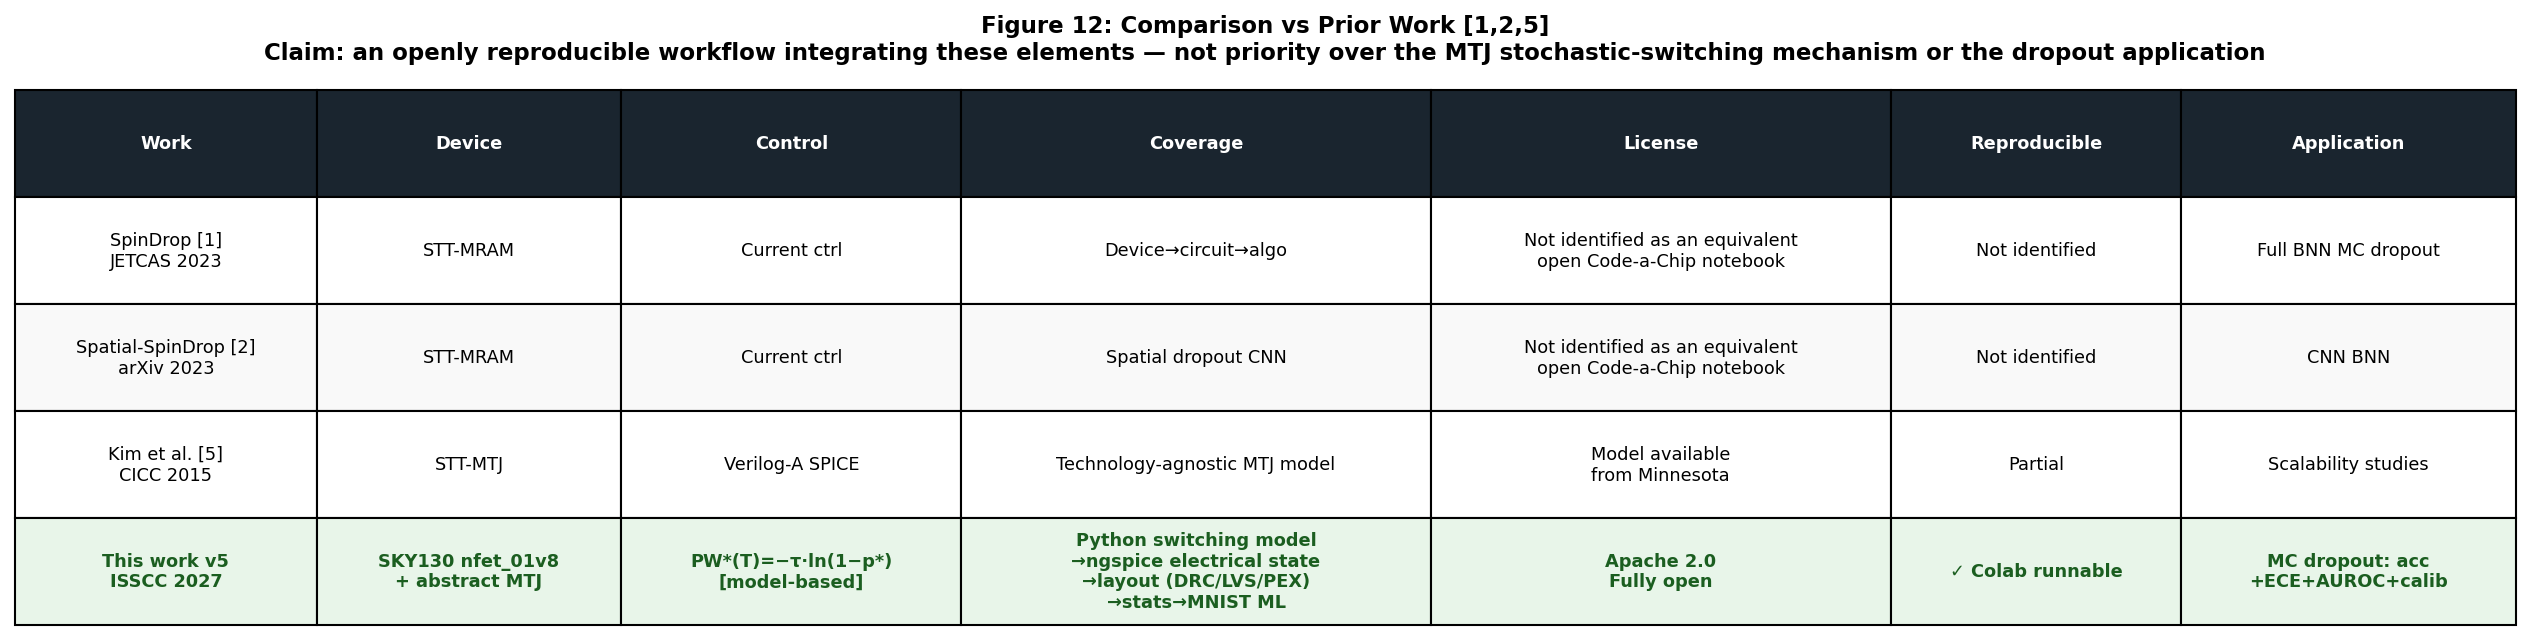

In [15]:
print("\n"+"═"*65)
print("SECTION 12 — Comparison vs Prior Work")
print("═"*65)

comp = [
    ["SpinDrop [1]\nJETCAS 2023",
     "STT-MRAM", "Current ctrl",
     "Device→circuit→algo","Not identified as an equivalent\nopen Code-a-Chip notebook","Not identified","Full BNN MC dropout"],
    ["Spatial-SpinDrop [2]\narXiv 2023",
     "STT-MRAM", "Current ctrl",
     "Spatial dropout CNN","Not identified as an equivalent\nopen Code-a-Chip notebook","Not identified","CNN BNN"],
    ["Kim et al. [5]\nCICC 2015",   # P0-4 fix: Kim not Jaiswal
     "STT-MTJ", "Verilog-A SPICE",
     "Technology-agnostic MTJ model","Model available\nfrom Minnesota","Partial","Scalability studies"],
    ["This work v5\nISSCC 2027",
     "SKY130 nfet_01v8\n+ abstract MTJ",
     "PW*(T)=−τ·ln(1−p*)\n[model-based]",
     "Python switching model\n→ngspice electrical state\n→layout (DRC/LVS/PEX)\n→stats→MNIST ML",
     "Apache 2.0\nFully open",
     "✓ Colab runnable",
     "MC dropout: acc\n+ECE+AUROC+calib"],
]
cols = ["Work","Device","Control","Coverage","License","Reproducible","Application"]
pd.DataFrame(comp, columns=cols).to_csv(f"{RES}/comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(17, 4.4)); ax.axis('off')
tbl = ax.table(cellText=comp, colLabels=cols,
               cellLoc='center', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
tbl.auto_set_column_width(list(range(len(cols))))
for j in range(len(cols)):
    tbl[0,j].set_facecolor('#1a252f')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for j in range(len(cols)):
    tbl[4,j].set_facecolor('#e8f5e9')
    tbl[4,j].set_text_props(fontweight='bold', color='#1b5e20')
for i in range(1,4):
    for j in range(len(cols)):
        tbl[i,j].set_facecolor('#f9f9f9' if i%2==0 else 'white')
plt.title(
    "Figure 12: Comparison vs Prior Work [1,2,5]\n"
    "Claim: an openly reproducible workflow integrating these elements — "
    "not priority over the MTJ stochastic-switching mechanism or the dropout application",
    fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f"{FIG}/fig12_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## Section 13 — FINAL SUMMARY


═════════════════════════════════════════════════════════════════
SECTION 13 — Final Results Summary (v5.1)
═════════════════════════════════════════════════════════════════

─────────────────────────────────────────────────────────────────
  Key finding                         Nominal calibration ≠ uniform calibration across devices: ECE 0.012–0.172 over 20 static devices (ideal 0.062±0.003) → per-device PW trimming = future work
  Framing                             Calibrated stochastic device model + open CMOS sensing circuit + statistical characterization framework
  Flow                                Python Néel-Brown → switching decision → ngspice evaluates electrical state (I_BL, E_pulse)
  Temperature model                   Constant-barrier approx.: Δ(T)=Δ₀·(T₀/T); I_c0 fixed zero-T threshold (no I_c(T))
  NMOS model                          official sky130_fd_pr__nfet_01v8 (tt), W/L = 1/0.15 µm
  Circuit (.op)                       I_BL(P)=105.52µA  I_BL(AP)=57.85µA  margi

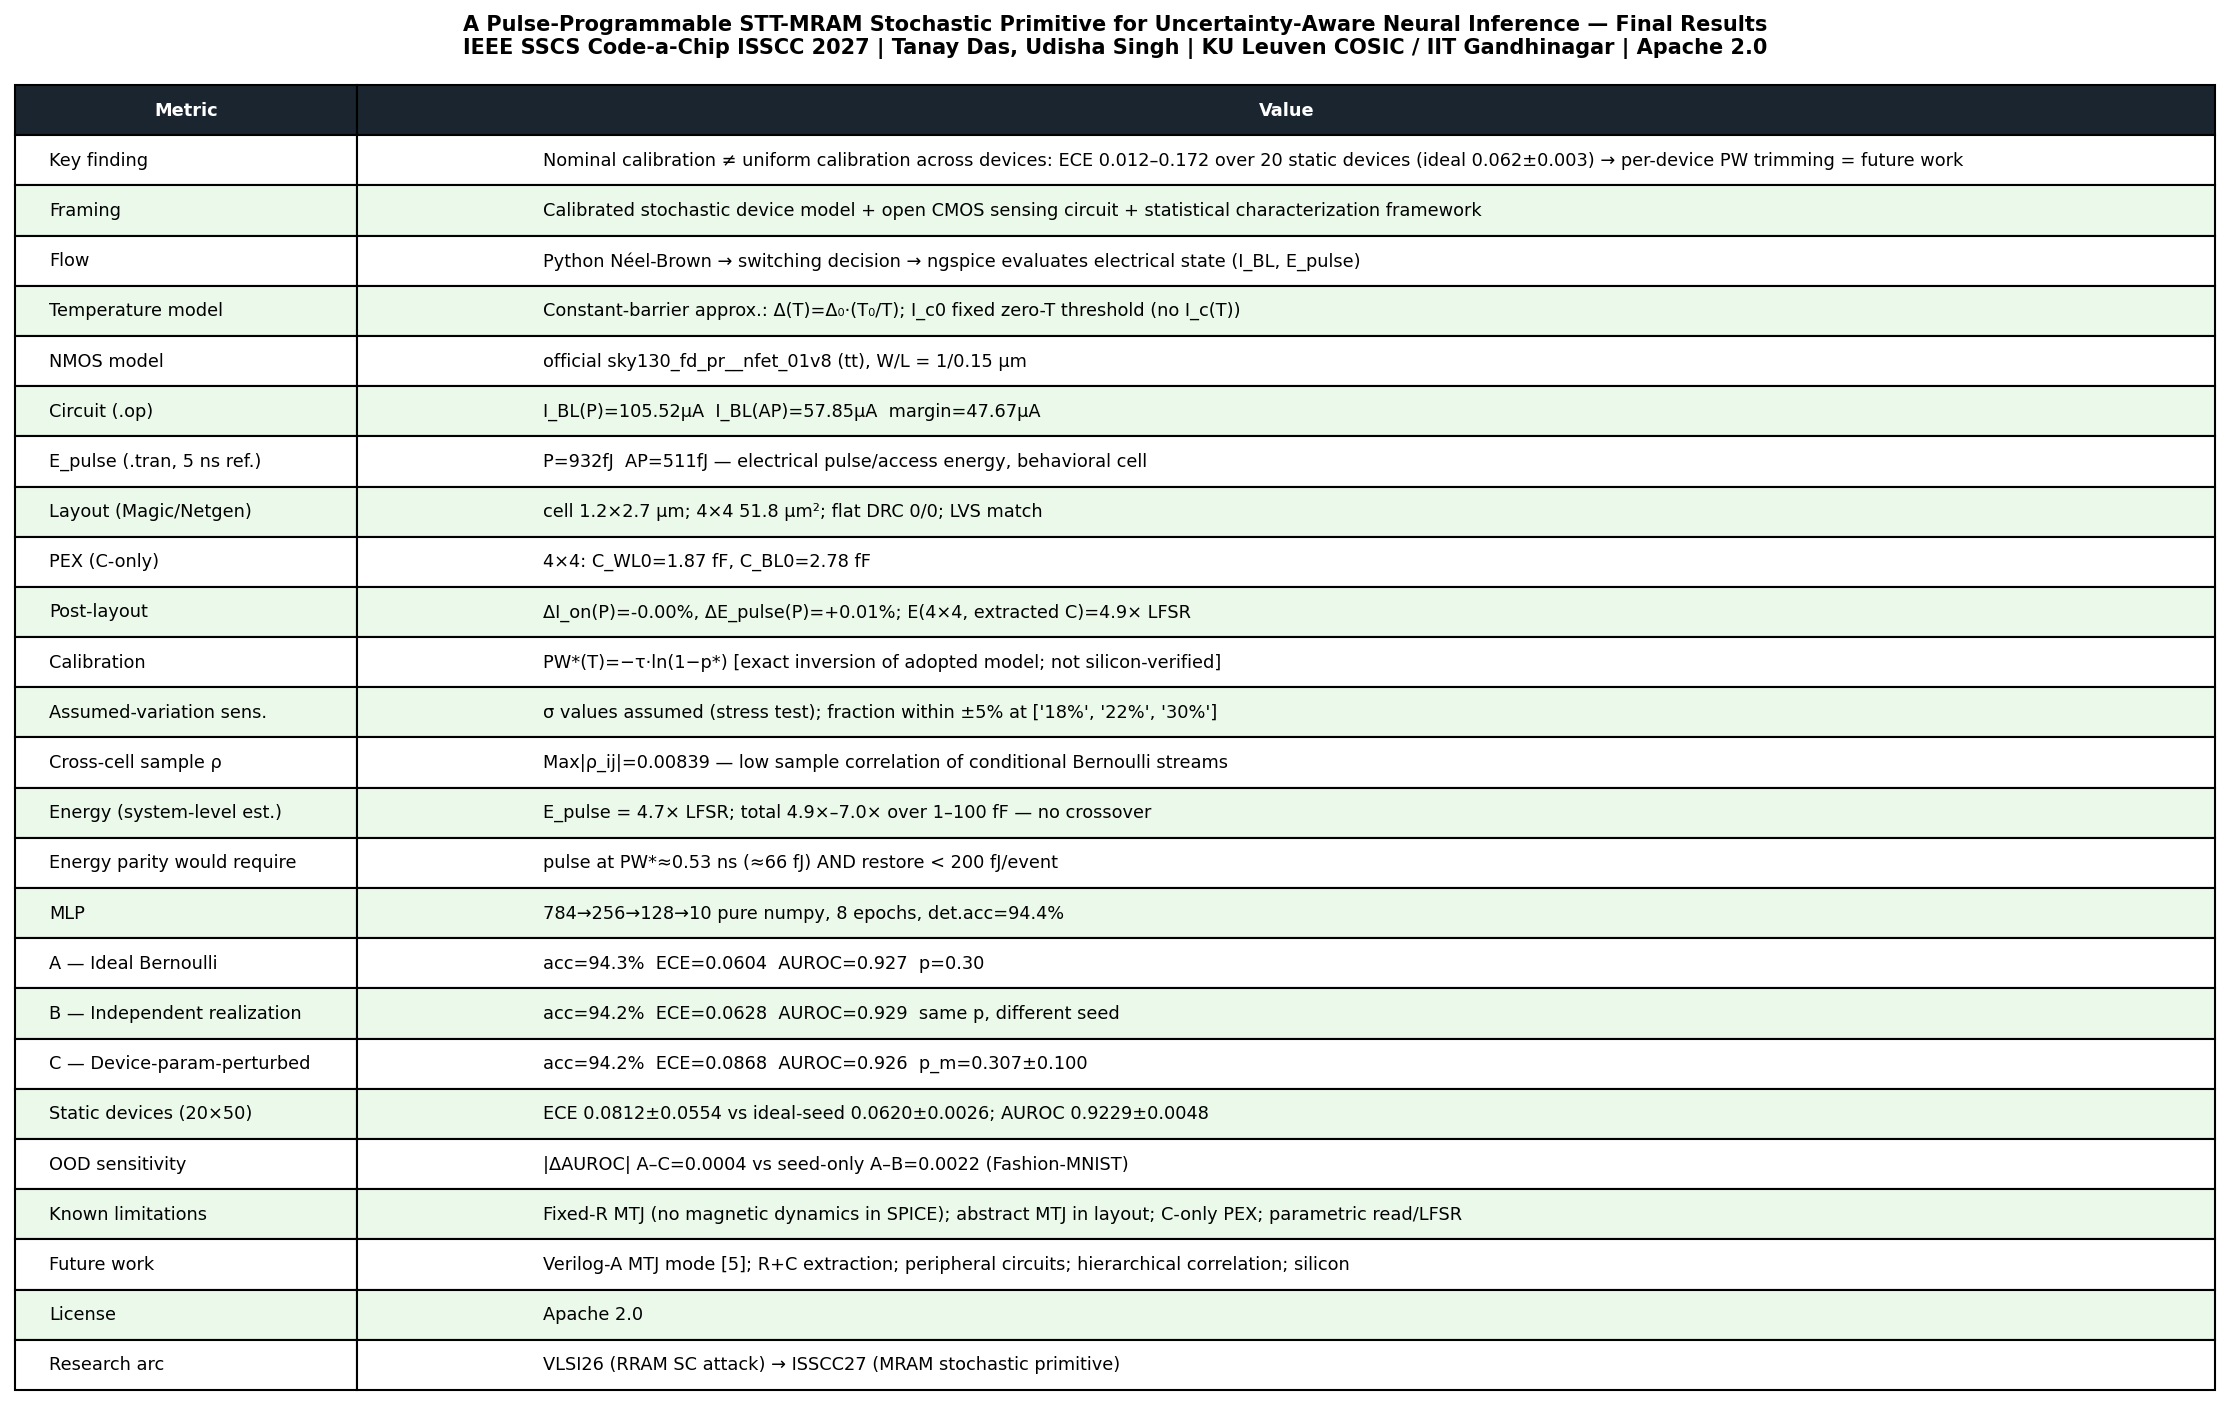


 NOTEBOOK COMPLETE — v5.1
  📊 fig10_array.png  (137KB)
  📊 fig11_mnist.png  (275KB)
  📊 fig11b_static_device.png  (109KB)
  📊 fig12_comparison.png  (151KB)
  📊 fig13_summary.png  (351KB)
  📊 fig2_surface.png  (253KB)
  📊 fig3_spice.png  (170KB)
  📊 fig4_calibration.png  (123KB)
  📊 fig5_device_mc.png  (88KB)
  📊 fig6_stats.png  (190KB)
  📊 fig7_energy.png  (208KB)
  📊 fig8_layout.png  (2175KB)
  📊 fig9_postlayout.png  (196KB)


In [16]:
print("\n"+"═"*65)
print("SECTION 13 — Final Results Summary (v5.1)")
print("═"*65)

NOVELTY = (
    "We provide an openly reproducible stochastic-computing workflow that couples "
    "a calibrated stochastic MTJ switching model (Néel-Brown [4], Python) with an open "
    "CMOS access circuit simulated in ngspice with official SKY130 models (.op + .tran on a "
    "fixed behavioral MTJ resistor), a DRC/LVS-verified SKY130 layout of the cell and a 4×4 array "
    "with an abstract MTJ interface and post-layout (PEX) simulation, a probability calibration engine, "
    "device-parameter Monte Carlo, statistical characterisation, a system-level energy "
    "estimate, and an MC-dropout sensitivity study on real MNIST with ECE and AUROC. "
    "Our literature review did not identify an existing openly reproducible "
    "implementation combining these elements in a single Code-a-Chip-style notebook. "
    "The claim is about the reproducible workflow and integration, not priority over the "
    "underlying MTJ stochastic-switching mechanism or dropout application."
)

summary = [
    ["Key finding",                f"Nominal calibration ≠ uniform calibration across devices: ECE {df_dev.ece.min():.3f}–{df_dev.ece.max():.3f} over 20 static devices (ideal {df_seed.ece.mean():.3f}±{df_seed.ece.std():.3f}) → per-device PW trimming = future work"],
    ["Framing",                    "Calibrated stochastic device model + open CMOS sensing circuit + statistical characterization framework"],
    ["Flow",                       "Python Néel-Brown → switching decision → ngspice evaluates electrical state (I_BL, E_pulse)"],
    ["Temperature model",          "Constant-barrier approx.: Δ(T)=Δ₀·(T₀/T); I_c0 fixed zero-T threshold (no I_c(T))"],
    ["NMOS model",                 NMOS_SRC],
    ["Circuit (.op)",              f"I_BL(P)={I_P_op*1e6:.2f}µA  I_BL(AP)={I_AP_op*1e6:.2f}µA  margin={(I_P_op-I_AP_op)*1e6:.2f}µA"],
    ["E_pulse (.tran, 5 ns ref.)", f"P={E_pulse_P*1e15:.0f}fJ  AP={E_pulse_AP*1e15:.0f}fJ — electrical pulse/access energy, behavioral cell"],
    *([["Layout (Magic/Netgen)",  f"cell {layout_res['cell_1t1mtj']['w_um']:.1f}×{layout_res['cell_1t1mtj']['h_um']:.1f} µm; 4×4 {A_arr:.1f} µm²; flat DRC {layout_res['cell_1t1mtj']['drc']}/{layout_res['array_4x4']['drc']}; LVS {'match' if layout_res['cell_1t1mtj']['lvs_ok'] and layout_res['array_4x4']['lvs_ok'] else 'FAIL'}"],
       ["PEX (C-only)",           f"4×4: C_WL0={C_arr['WL0']*1e15:.2f} fF, C_BL0={C_arr['BL0']*1e15:.2f} fF"],
       ["Post-layout",            f"ΔI_on(P)={(post['P'][1]['I_on']/post['P'][0]['I_on']-1)*100:+.2f}%, ΔE_pulse(P)={(post['P'][1]['E_BL']/post['P'][0]['E_BL']-1)*100:+.2f}%; E(4×4, extracted C)={E_ext_4x4/E_LFSR_ref:.1f}× LFSR"]]
      if (LAYOUT_SRC and USE_SKY130) else [["Layout", "skipped (PDK unavailable)"]]),
    ["Calibration",                "PW*(T)=−τ·ln(1−p*) [exact inversion of adopted model; not silicon-verified]"],
    ["Assumed-variation sens.",    f"σ values assumed (stress test); fraction within ±5% at {[f'{np.mean(np.abs(mc_pvt[l]-TARGET)<0.05)*100:.0f}%' for l in AEC_L]}"],
    ["Cross-cell sample ρ",        f"Max|ρ_ij|={np.max(np.abs(off_diag)):.5f} — low sample correlation of conditional Bernoulli streams"],
    ["Energy (system-level est.)", f"E_pulse = {ratio_pulse:.1f}× LFSR; total {ratio_min:.1f}×–{E_mtj_sweep.max()/E_LFSR_ref:.1f}× over 1–100 fF — no crossover"],
    ["Energy parity would require",    f"pulse at PW*≈{PW_STAR_30*1e9:.2f} ns (≈{E_pulse_star*1e15:.0f} fJ) AND restore < {max(E_reset_budget,0)*1e15:.0f} fJ/event"],
    ["MLP",                        f"784→256→128→10 pure numpy, 8 epochs, det.acc={acc_det:.1f}%"],
    ["A — Ideal Bernoulli",        f"acc={acc_A:.1f}%  ECE={ece_A:.4f}  AUROC={auroc_A:.3f}  p=0.30"],
    ["B — Independent realization",f"acc={acc_B:.1f}%  ECE={ece_B:.4f}  AUROC={auroc_B:.3f}  same p, different seed"],
    ["C — Device-param-perturbed", f"acc={acc_C:.1f}%  ECE={ece_C:.4f}  AUROC={auroc_C:.3f}  p_m={p_m.mean():.3f}±{p_m.std():.3f}"],
    ["Static devices (20×50)",     f"ECE {df_dev.ece.mean():.4f}±{df_dev.ece.std():.4f} vs ideal-seed {df_seed.ece.mean():.4f}±{df_seed.ece.std():.4f}; AUROC {df_dev.auroc.mean():.4f}±{df_dev.auroc.std():.4f}"],
    ["OOD sensitivity",            f"|ΔAUROC| A–C={abs(auroc_A-auroc_C):.4f} vs seed-only A–B={abs(auroc_A-auroc_B):.4f} ({OOD_LBL})"],
    ["Known limitations",          "Fixed-R MTJ (no magnetic dynamics in SPICE); abstract MTJ in layout; C-only PEX; parametric read/LFSR"],
    ["Future work",                "Verilog-A MTJ mode [5]; R+C extraction; peripheral circuits; hierarchical correlation; silicon"],
    ["License",                    "Apache 2.0"],
    ["Research arc",               "VLSI26 (RRAM SC attack) → ISSCC27 (MRAM stochastic primitive)"],
]
pd.DataFrame(summary, columns=["Metric","Value"]).to_csv(f"{RES}/summary_v5_1.csv", index=False)

print("\n"+"─"*65)
for m, v in summary: print(f"  {m:<35} {v}")
print("─"*65)
print(f"\nNovelty statement:\n  {NOVELTY}")

fig, ax = plt.subplots(figsize=(15, 9.5)); ax.axis('off')
tbl = ax.table(cellText=summary, colLabels=["Metric","Value"],
               cellLoc='left', loc='center', bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5)
tbl.auto_set_column_width([0,1])
for j in range(2):
    tbl[0,j].set_facecolor('#1a252f')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(summary)+1):
    for j in range(2):
        tbl[i,j].set_facecolor('#eaf9ea' if i%2==0 else 'white')
plt.title(
    "A Pulse-Programmable STT-MRAM Stochastic Primitive for Uncertainty-Aware Neural Inference — Final Results\n"
    "IEEE SSCS Code-a-Chip ISSCC 2027 | Tanay Das, Udisha Singh | "
    "KU Leuven COSIC / IIT Gandhinagar | Apache 2.0",
    fontsize=10, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(f"{FIG}/fig13_summary.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n"+"="*65)
print(" NOTEBOOK COMPLETE — v5.1")
print("="*65)
figs = sorted(os.listdir(FIG))
for f in figs:
    sz = os.path.getsize(f"{FIG}/{f}")//1024
    print(f"  📊 {f}  ({sz}KB)")